1. Importing Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import glob
import gc
import os
import duckdb
import geopandas as gpd
import joblib
from tqdm import tqdm
from matplotlib.patches import Patch
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from statsmodels.tsa.seasonal import seasonal_decompose

=========================================================================================================================================================

2. Going through the steps of ETL

In [4]:
# df = pd.read_csv("D:/UEA/Business Analytics/P1/Code_Dataset/Data_1/epd_snomed_202512.csv")


In [5]:
# df.head(5)

In [6]:
# df = df.rename(columns={
#     'REGIONAL_OFFICE_NAME': 'REGIONAL_OFFICE',
#     'BNF_CHAPTER_PLUS_CODE': 'BNF_CHAPTER_CODE',
#     'BNF_CHEMICAL_SUBSTANCE': 'DRUG_NAME',
#     'BNF_PRESENTATION_NAME': 'DRUG_DESCRIPTION',
#     'ADQUSAGE': 'ADQ_USAGE'
# })

# df.columns

In [7]:
# keep_columns = [
#     'YEAR_MONTH', 'REGIONAL_OFFICE', 'ICB_NAME', 'ICB_CODE',
#     'PRACTICE_NAME', 'PRACTICE_CODE', 'POSTCODE',
#     'BNF_CHAPTER_CODE', 'DRUG_NAME',
#     'DRUG_DESCRIPTION', 'ITEMS', 'TOTAL_QUANTITY',
#     'ADQ_USAGE', 'NIC', 'ACTUAL_COST', 'UNIDENTIFIED'
# ]

# df = df[keep_columns]

In [8]:
# df.columns

In [9]:
# df['YEAR_MONTH'] = df['YEAR_MONTH'].astype(str)
# df['YEAR_MONTH'] = df['YEAR_MONTH'].apply(
#     lambda x: x[:4] + '-' + x[4:] if '-' not in x else x
# )

In [10]:
# print(df[['YEAR_MONTH']].tail())

In [11]:
# df['ADQ_USAGE'] = df['ADQ_USAGE'].round(2)
# df['NIC'] = df['NIC'].round(2)
# df['ACTUAL_COST'] = df['ACTUAL_COST'].round(2)

In [12]:
# print(df[['ADQ_USAGE', 'NIC', 'ACTUAL_COST']].tail())

In [13]:
# df['TOTAL_QUANTITY'] = df['TOTAL_QUANTITY'].astype(int)
# print(df[['TOTAL_QUANTITY']].head())

In [14]:
# print(df.head());

In [15]:
# df['COST_PER_ITEM'] = (df['ACTUAL_COST'] / df['ITEMS']).round(2)
# df['NIC_RATIO'] = (df['ACTUAL_COST'] / df['NIC']).round(2)
# df['MONTH'] = df['YEAR_MONTH'].str[5:].astype(int)
# df['QUARTER'] = df['MONTH'].apply(lambda x: (x - 1) // 3 + 1)

In [16]:
# print(df.head());

In [17]:
# print(df[df['UNIDENTIFIED'] == 'Y'].shape[0])

In [18]:
# df[df['UNIDENTIFIED'] == 'Y']

In [19]:
# df = df[df['UNIDENTIFIED'] != 'Y']

In [20]:
# print(df['UNIDENTIFIED'].value_counts())

In [21]:
# print(df.isnull().sum())

In [22]:
# print(df[df['NIC'] == 0].shape[0])

In [23]:
# before = len(df)
# print(f"Rows before dropping: {before}")


In [24]:
# df = df[df['NIC'] != 0]


In [25]:
# after = len(df)
# print(f"Rows after dropping: {after}")
# print(f"Rows dropped: {before - after}")

In [26]:
# print(f"NIC = 0: {(df['NIC'] == 0).sum()}")
# print(f"NIC missing: {df['NIC'].isnull().sum()}")

In [27]:
# df = df.drop(columns=['POSTCODE'])

In [28]:
# print(df.head());

In [29]:
# df.to_csv("D:/UEA/Business Analytics/P1/Code_Dataset/Data_Main/epd_snomed_202512_clean.csv", index=False)

In [30]:
# df = pd.read_csv("D:/UEA/Business Analytics/P1/Code_Dataset/Data_Main/epd_snomed_202512_clean.csv")

In [31]:
# df.head(5)a

In [32]:
# df.columns

Now working on the Cleaned CSV files

3. Converting .csv files into parquet

In [33]:
# BASE_PATH = "D:/UEA/Business Analytics/P1/Code_Dataset/Data_Main"
# PARQUET_PATH = "D:/UEA/Business Analytics/P1/Code_Dataset/Parquet_Files"

# files = [
#     "epd_snomed_202501_clean.csv",
#     "epd_snomed_202502_clean.csv",
#     "epd_snomed_202503_clean.csv",
#     "epd_snomed_202504_clean.csv",
#     "epd_snomed_202505_clean.csv",
#     "epd_snomed_202506_clean.csv",
#     "epd_snomed_202507_clean.csv",
#     "epd_snomed_202508_clean.csv",
#     "epd_snomed_202509_clean.csv",
#     "epd_snomed_202510_clean.csv",
#     "epd_snomed_202511_clean.csv",
#     "epd_snomed_202512_clean.csv"
# ]

# print("Folder exists:", os.path.exists(BASE_PATH))

# print("\nFiles found in folder:")
# for f in os.listdir(BASE_PATH):
#     print(f"  →", f)


In [34]:
# for file in tqdm(files):
#     csv_path = os.path.join(BASE_PATH, file)
#     parquet_name = file.replace(".csv", ".parquet")
#     parquet_path = os.path.join(PARQUET_PATH, parquet_name)

#     # Skip if already converted
#     if os.path.exists(parquet_path):
#         print(f"⏭ Already exists — skipping {parquet_name}")
#         continue

#     df_temp = pd.read_csv(
#         csv_path,
#         low_memory=False
#     )
#     df_temp["SOURCE_FILE"] = file
#     df_temp.to_parquet(parquet_path, index=False)

#     print(f"✅ {file} → {parquet_name} — {len(df_temp):,} rows")

#     del df_temp
#     import gc
#     gc.collect()

# print("\n✅ All CSV files converted to parquet")

In [35]:
# Parquet_Files = sorted(glob.glob(os.path.join(PARQUET_PATH, "*.parquet")))

# print(f"Found {len(Parquet_Files)} parquet files:")
# for f in Parquet_Files:
#     print(f"  → {os.path.basename(f)}")



=========================================================================================================================================================

4. Connecting to DuckDB

In [36]:
con = duckdb.connect()

=========================================================================================================================================================

5. Merging all the Parquet files

In [37]:
# con.execute("""
#     COPY (SELECT * FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Parquet_Files/*.parquet'))
#     TO 'D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset.parquet'
#     (FORMAT PARQUET)
# """)


# print("Merged file saved successfully")

=========================================================================================================================================================

6. Reading the new dataset

In [38]:
# df = con.execute("""
#     SELECT * FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset.parquet')
#     LIMIT 5
# """).df()
# # LIMIT 5 loads just 5 rows to confirm the file loads correctly

# print(df)

In [39]:
# result = con.execute("""
#     SELECT COUNT(*) as total_rows
#     FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset.parquet')
# """).df()

# print(result)

In [40]:
# result = con.execute("""
#     SELECT * FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset.parquet')
#     LIMIT 1
# """).df()

# print(result.columns.tolist())

7. Removing SOURCE_FILE and UNIDENTIFIED columns for further cleaning

In [41]:
# con.execute("""
#     COPY (
#         SELECT * EXCLUDE (SOURCE_FILE, UNIDENTIFIED)
#         FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset.parquet')
#     )
#     TO 'D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet'
#     (FORMAT PARQUET)
# """)

# print("Done")

In [42]:
# result = con.execute("""
#     SELECT * FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
#     LIMIT 1
# """).df()

# print(result.columns.tolist())
# print(f"Total columns: {len(result.columns)}")

=========================================================================================================================================================

8. Chapter 1

In [43]:
# Check all unique drug categories in the dataset
categories = con.execute("""
    SELECT 
        BNF_CHAPTER_CODE,
        COUNT(*) as total_rows
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    GROUP BY BNF_CHAPTER_CODE
    ORDER BY BNF_CHAPTER_CODE
""").df()

print(f"Total categories: {len(categories)}")
print(categories)

Total categories: 21
                                     BNF_CHAPTER_CODE  total_rows
0                        01: Gastro-Intestinal System    15802866
1                           02: Cardiovascular System    32657190
2                              03: Respiratory System    11804185
3                          04: Central Nervous System    53833015
4                                      05: Infections     8686909
5                                06: Endocrine System    22550627
6   07: Obstetrics, Gynaecology and Urinary-Tract ...     7144163
7         08: Malignant Disease and Immunosuppression     1610203
8                             09: Nutrition and Blood    15924056
9              10: Musculoskeletal and Joint Diseases     6519002
10                                            11: Eye     5662482
11                       12: Ear, Nose and Oropharynx     2327887
12                                           13: Skin    10068235
13            14: Immunological Products and Vaccines  

In [44]:
top10_cost = con.execute("""
    SELECT 
        BNF_CHAPTER_CODE,
        ROUND(SUM(ACTUAL_COST), 2) AS total_cost
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    GROUP BY BNF_CHAPTER_CODE
    ORDER BY total_cost DESC
    LIMIT 10
""").df()
# Groups data by drug category and sums up the total cost
# Orders from highest to lowest and takes top 10

print(top10_cost)

                                    BNF_CHAPTER_CODE    total_cost
0                               06: Endocrine System  2.225781e+09
1                         04: Central Nervous System  1.510052e+09
2                             03: Respiratory System  1.180691e+09
3                          02: Cardiovascular System  1.087523e+09
4                                     21: Appliances  8.558814e+08
5                            09: Nutrition and Blood  8.517649e+08
6                       01: Gastro-Intestinal System  6.882141e+08
7                               23: Stoma Appliances  4.179112e+08
8                                           13: Skin  3.023284e+08
9  07: Obstetrics, Gynaecology and Urinary-Tract ...  2.670483e+08


In [45]:
# Make costs readable by converting to millions
top10_cost['total_cost_millions'] = (top10_cost['total_cost'] / 1_000_000).round(2)
print(top10_cost[['BNF_CHAPTER_CODE', 'total_cost_millions']])
# Shows cost in millions instead of scientific notation

                                    BNF_CHAPTER_CODE  total_cost_millions
0                               06: Endocrine System              2225.78
1                         04: Central Nervous System              1510.05
2                             03: Respiratory System              1180.69
3                          02: Cardiovascular System              1087.52
4                                     21: Appliances               855.88
5                            09: Nutrition and Blood               851.76
6                       01: Gastro-Intestinal System               688.21
7                               23: Stoma Appliances               417.91
8                                           13: Skin               302.33
9  07: Obstetrics, Gynaecology and Urinary-Tract ...               267.05


In [46]:
# Step 2: Top 10 drug categories by total ITEMS
top10_items = con.execute("""
    SELECT 
        BNF_CHAPTER_CODE,
        SUM(ITEMS) AS total_items
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    GROUP BY BNF_CHAPTER_CODE
    ORDER BY total_items DESC
    LIMIT 10
""").df()
# Groups data by drug category and sums up total prescriptions
# Orders from highest to lowest and takes top 10

print(top10_items)

                                    BNF_CHAPTER_CODE  total_items
0                          02: Cardiovascular System  387947626.0
1                         04: Central Nervous System  238552845.0
2                               06: Endocrine System  145759892.0
3                       01: Gastro-Intestinal System  119677707.0
4                             03: Respiratory System   75472562.0
5                            09: Nutrition and Blood   71575127.0
6                                     21: Appliances   40146180.0
7                                     05: Infections   35767015.0
8  07: Obstetrics, Gynaecology and Urinary-Tract ...   35609722.0
9             10: Musculoskeletal and Joint Diseases   32249238.0


In [47]:
# Step 3: Merge both rankings to compare side by side
top10_cost['cost_rank'] = range(1, 11)
# Adds cost ranking column

top10_items['items_rank'] = range(1, 11)
# Adds items ranking column

comparison = top10_cost[['BNF_CHAPTER_CODE', 'cost_rank']].merge(
    top10_items[['BNF_CHAPTER_CODE', 'items_rank']],
    on='BNF_CHAPTER_CODE',
    how='outer'
)
# Joins both tables together to compare rankings side by side

print(comparison.sort_values('cost_rank'))

                                     BNF_CHAPTER_CODE  cost_rank  items_rank
5                                06: Endocrine System        1.0         3.0
3                          04: Central Nervous System        2.0         2.0
2                              03: Respiratory System        3.0         5.0
1                           02: Cardiovascular System        4.0         1.0
10                                     21: Appliances        5.0         7.0
7                             09: Nutrition and Blood        6.0         6.0
0                        01: Gastro-Intestinal System        7.0         4.0
11                               23: Stoma Appliances        8.0         NaN
9                                            13: Skin        9.0         NaN
6   07: Obstetrics, Gynaecology and Urinary-Tract ...       10.0         9.0
4                                      05: Infections        NaN         8.0
8              10: Musculoskeletal and Joint Diseases        NaN        10.0

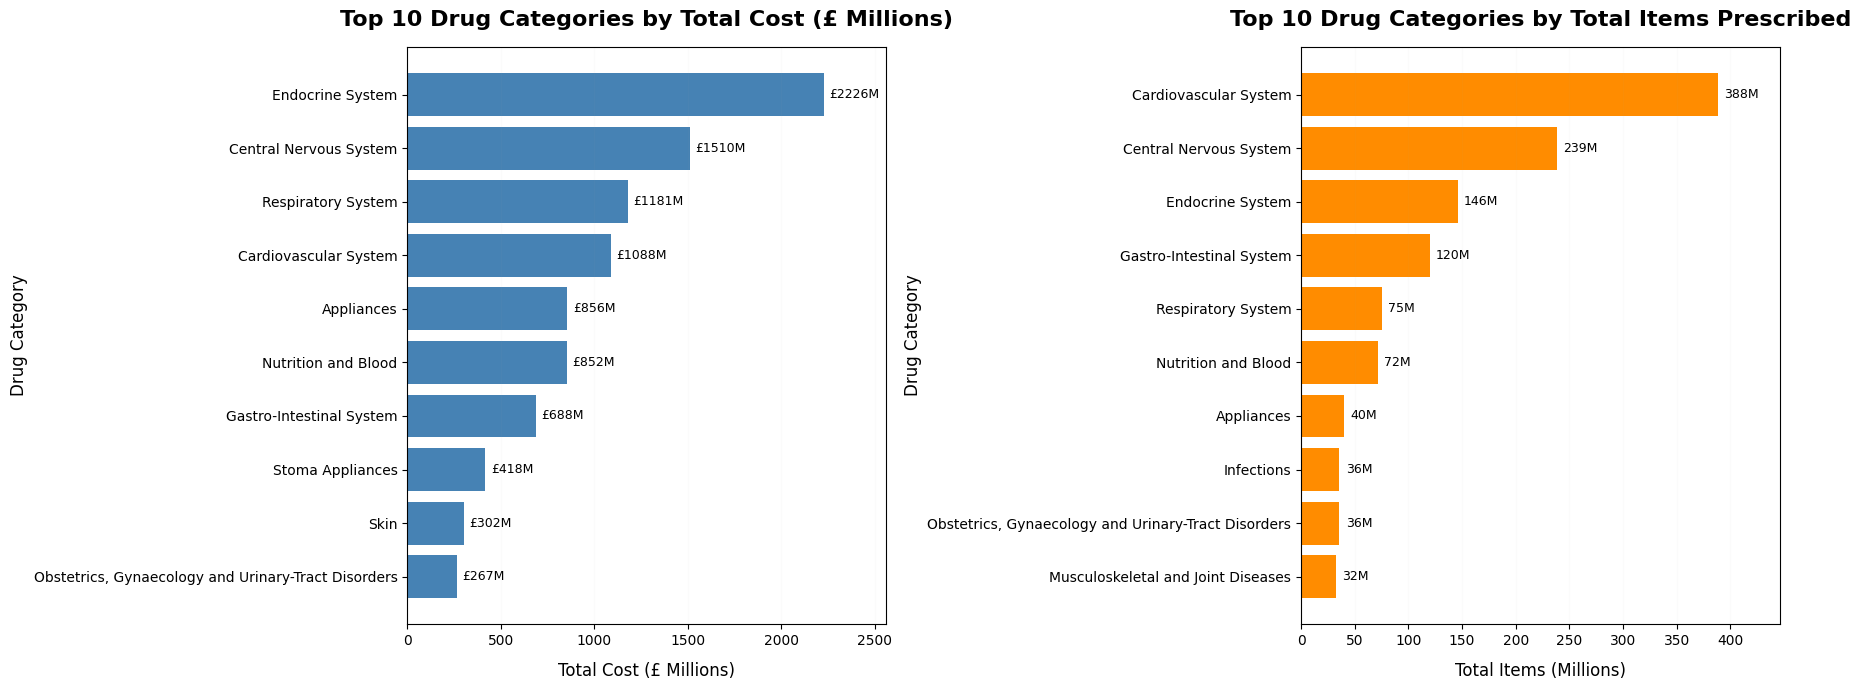

Chart saved


In [48]:
# Shorten long category names for better display
top10_cost['short_name'] = top10_cost['BNF_CHAPTER_CODE'].str.split(':').str[1].str.strip()
top10_items['short_name'] = top10_items['BNF_CHAPTER_CODE'].str.split(':').str[1].str.strip()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
# Increased figure width to fit titles and labels properly

# --- Chart 1: Top 10 by Cost ---
bars1 = ax1.barh(top10_cost['short_name'][::-1], top10_cost['total_cost_millions'][::-1], color='steelblue')

for bar in bars1:
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'£{bar.get_width():.0f}M', va='center', fontsize=9)
    # Adds value at end of each bar

ax1.set_title('Top 10 Drug Categories by Total Cost (£ Millions)', fontweight='bold', fontsize=16, pad=15)
# pad=15 adds space between title and chart
ax1.set_xlabel('Total Cost (£ Millions)', fontsize=12, labelpad=10)
ax1.set_ylabel('Drug Category', fontsize=12)
# Added y-axis label
ax1.set_xlim(0, max(top10_cost['total_cost_millions']) * 1.15)
# Extends x-axis by 15% to fit value labels inside chart
ax1.grid(True, axis='x', alpha=0.04)
# Adds light grid lines for easier reading

# --- Chart 2: Top 10 by Volume ---
top10_items['total_items_millions'] = (top10_items['total_items'] / 1_000_000).round(2)
bars2 = ax2.barh(top10_items['short_name'][::-1], top10_items['total_items_millions'][::-1], color='darkorange')

for bar in bars2:
    ax2.text(bar.get_width() + 6, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.0f}M', va='center', fontsize=9)

ax2.set_title('Top 10 Drug Categories by Total Items Prescribed', fontweight='bold', fontsize=16, pad=15)
ax2.set_xlabel('Total Items (Millions)', fontsize=12, labelpad=10)
ax2.set_ylabel('Drug Category', fontsize=12)
ax2.set_xlim(0, max(top10_items['total_items_millions']) * 1.15)
ax2.grid(True, axis='x', alpha=0.04)

plt.tight_layout()
plt.savefig('chapter1_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [49]:
# Step 5: Find drugs with high COST_PER_ITEM but low ITEMS
cost_per_item = con.execute("""
    SELECT 
        BNF_CHAPTER_CODE,
        DRUG_NAME,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_item,
        SUM(ITEMS) AS total_items
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    GROUP BY BNF_CHAPTER_CODE, DRUG_NAME
    HAVING SUM(ITEMS) < 1000000
    AND AVG(COST_PER_ITEM) > 100
    ORDER BY avg_cost_per_item DESC
    LIMIT 10
""").df()
# Finds drugs that are expensive per item but prescribed less frequently
# HAVING filters for low volume but high cost drugs

print(cost_per_item)

                              BNF_CHAPTER_CODE                  DRUG_NAME  \
0                               05: Infections               Nitazoxanide   
1                               05: Infections                 Letermovir   
2  08: Malignant Disease and Immunosuppression                Belumosudil   
3                      09: Nutrition and Blood                  Miglustat   
4  08: Malignant Disease and Immunosuppression               Cabozantinib   
5  08: Malignant Disease and Immunosuppression               Zanubrutinib   
6                    02: Cardiovascular System          Quinidine sulfate   
7                      09: Nutrition and Blood  Trientine dihydrochloride   
8                      09: Nutrition and Blood                    Sucrase   
9                               05: Infections   Glecaprevir/pibrentasvir   

   avg_cost_per_item  total_items  
0           11056.10          3.0  
1            6619.08          1.0  
2            6372.49          1.0  
3       

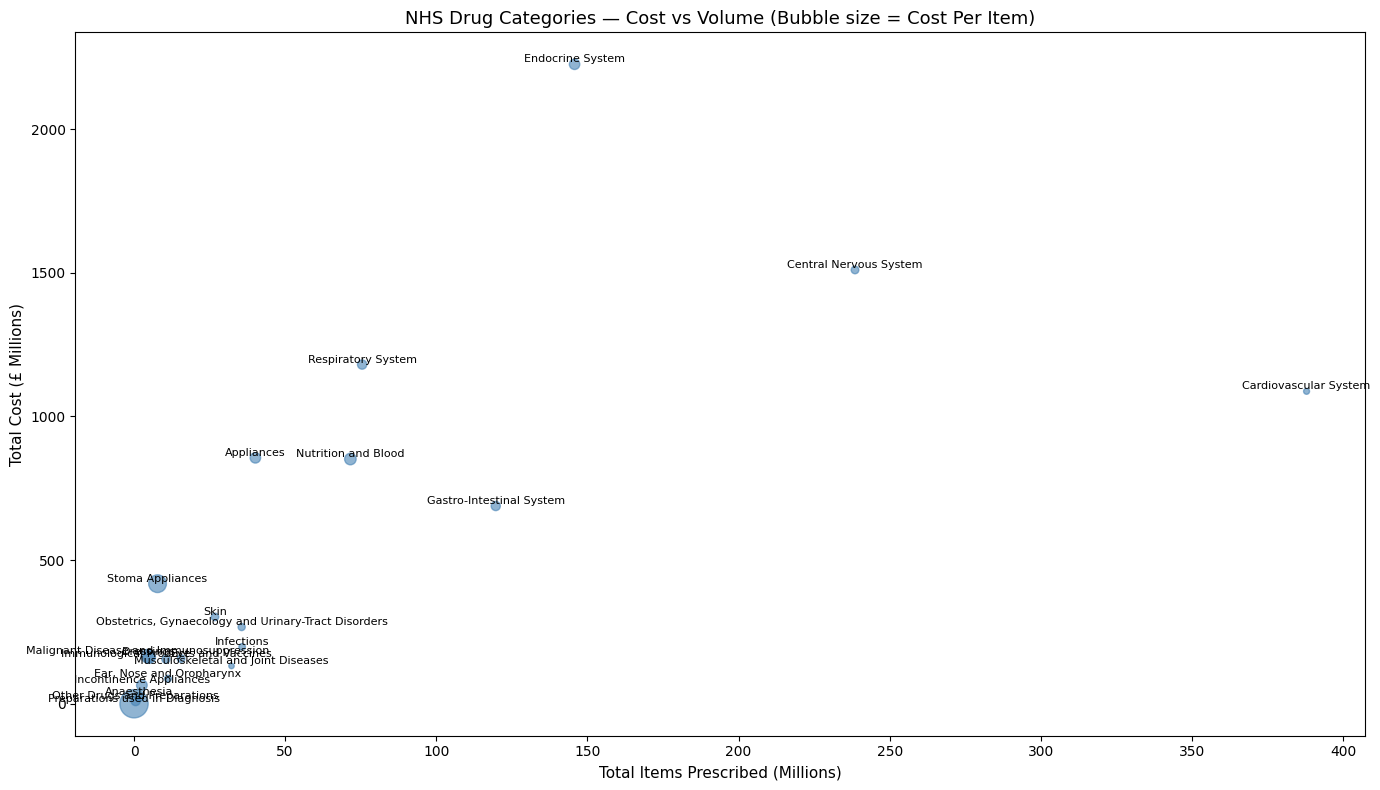

Chart saved


In [50]:
#Scatter plot - ITEMS vs ACTUAL_COST per category
scatter_data = con.execute("""
    SELECT 
        BNF_CHAPTER_CODE,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_item
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    GROUP BY BNF_CHAPTER_CODE
    ORDER BY total_cost_millions DESC
""").df()
#Gets cost, volume and cost per item for every drug category

scatter_data['short_name'] = scatter_data['BNF_CHAPTER_CODE'].str.split(':').str[1].str.strip()
#Shortens the category names

fig, ax = plt.subplots(figsize=(14, 8))

scatter = ax.scatter(
    scatter_data['total_items_millions'],
    scatter_data['total_cost_millions'],
    s=scatter_data['avg_cost_per_item'] * 2, #Bubble size shows cost per item — bigger bubble means more expensive per prescription
    alpha=0.6,
    color='steelblue'
)

#Add category name labels to each bubble
for _, row in scatter_data.iterrows():
    ax.annotate(row['short_name'],
                (row['total_items_millions'], row['total_cost_millions']),
                fontsize=8, ha='center', va='bottom')

ax.set_xlabel('Total Items Prescribed (Millions)', fontsize=11)
ax.set_ylabel('Total Cost (£ Millions)', fontsize=11)
ax.set_title('NHS Drug Categories — Cost vs Volume (Bubble size = Cost Per Item)', fontsize=13)

plt.tight_layout()
plt.savefig('chapter1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [51]:
# # Scatter plot - ITEMS vs ACTUAL_COST per category
# scatter_data = con.execute("""
#     SELECT 
#         BNF_CHAPTER_CODE,
#         ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
#         ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions,
#         ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_item
#     FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
#     GROUP BY BNF_CHAPTER_CODE
#     ORDER BY total_cost_millions DESC
# """).df()
# # Gets cost, volume and cost per item for every drug category
# # Create short codes for each category
# scatter_data['code'] = scatter_data['BNF_CHAPTER_CODE'].str.split(':').str[0].str.strip()
# # Takes only the number part e.g. "02" from "02: Cardiovascular System"

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [2, 1]})
# # Creates chart on left and legend on right

# # Scatter plot
# scatter = ax1.scatter(
#     scatter_data['total_items_millions'],
#     scatter_data['total_cost_millions'],
#     s=scatter_data['avg_cost_per_item'] * 5,
#     alpha=0.7,
#     color='steelblue',
#     edgecolors='white',
#     linewidth=0.5
# )

# # Label each bubble with just the number code
# for _, row in scatter_data.iterrows():
#     ax1.annotate(row['code'],
#                 (row['total_items_millions'], row['total_cost_millions']),
#                 fontsize=9, ha='center', va='center',
#                 fontweight='bold', color='white')

# ax1.set_xlabel('Total Items Prescribed (Millions)', fontsize=12)
# ax1.set_ylabel('Total Cost (£ Millions)', fontsize=12)
# ax1.set_title('NHS Drug Categories — Cost vs Volume\n(Bubble size = Average Cost Per Item)', fontsize=13)

# # Legend on right side
# ax2.axis('off')
# # Turns off the chart axes for the legend panel

# scatter_data['short_name'] = scatter_data['BNF_CHAPTER_CODE'].str.split(':').str[1].str.strip()
# scatter_data['code'] = scatter_data['BNF_CHAPTER_CODE'].str.split(':').str[0].str.strip()

# legend_text = "\n".join([f"{row['code']}: {row['short_name']}" for _, row in scatter_data.iterrows()])
# ax2.text(0, 0.95, "Category Legend", fontsize=11, fontweight='bold', va='top')
# ax2.text(0, 0.88, legend_text, fontsize=9, va='top', family='monospace')
# # Displays the full names as a legend

# plt.tight_layout()
# plt.savefig('chapter1_scatter.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Chart saved")

In [52]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [2, 1]})

# # Scatter plot with log scale
# scatter = ax1.scatter(
#     scatter_data['total_items_millions'],
#     scatter_data['total_cost_millions'],
#     s=scatter_data['avg_cost_per_item'] * 5,
#     alpha=0.7,
#     color='steelblue',
#     edgecolors='white',
#     linewidth=0.5
# )

# # Label each bubble with just the number code
# for _, row in scatter_data.iterrows():
#     ax1.annotate(row['code'],
#                 (row['total_items_millions'], row['total_cost_millions']),
#                 fontsize=9, ha='center', va='center',
#                 fontweight='bold', color='white')

# ax1.set_xscale('log')
# ax1.set_yscale('log')
# # Log scale spreads out the clustered categories so everything is readable

# ax1.set_xlabel('Total Items Prescribed (Millions) — Log Scale', fontsize=12)
# ax1.set_ylabel('Total Cost (£ Millions) — Log Scale', fontsize=12)
# ax1.set_title('NHS Drug Categories — Cost vs Volume\n(Bubble size = Average Cost Per Item)', fontsize=13)
# ax1.grid(True, alpha=0.3)

# # Legend on right side
# ax2.axis('off')
# legend_text = "\n".join([f"{row['code']}: {row['short_name']}" 
#                           for _, row in scatter_data.iterrows()])
# ax2.text(0, 0.95, "Category Legend", fontsize=11, fontweight='bold', va='top')
# ax2.text(0, 0.88, legend_text, fontsize=9, va='top', family='monospace')

# plt.tight_layout()
# plt.savefig('chapter1_scatter.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Chart saved")

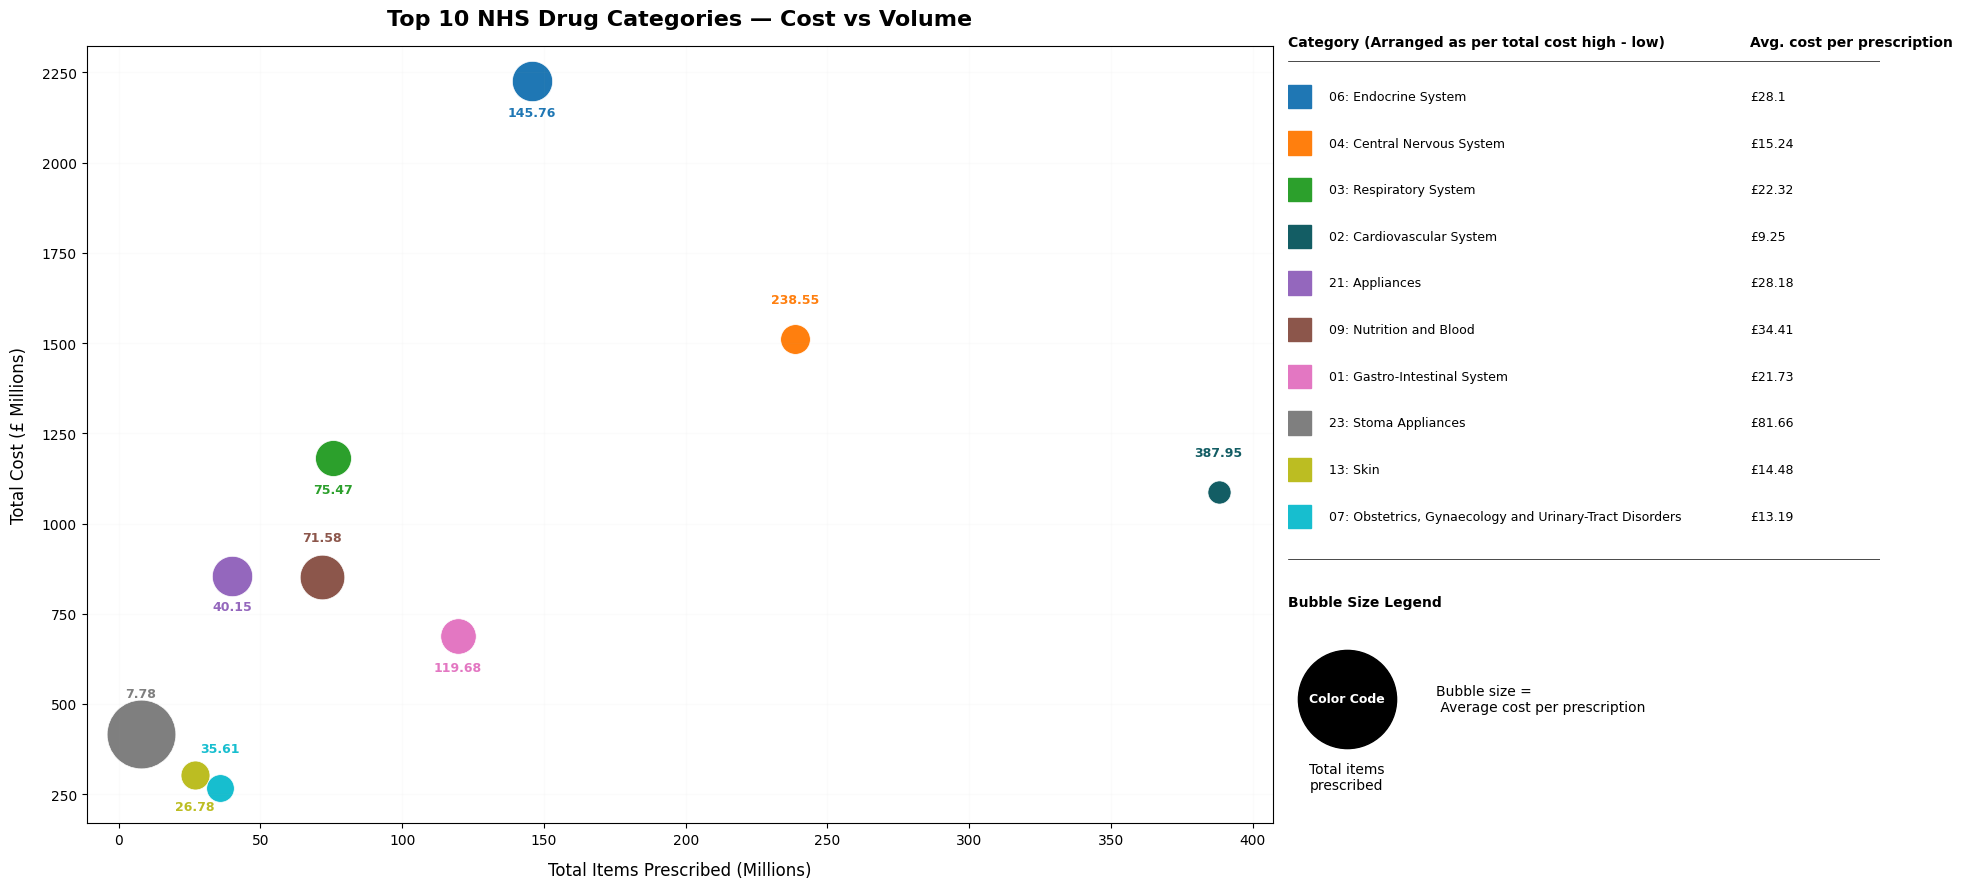

Chart saved


In [53]:
# Get top 10 categories by cost
top10_scatter = con.execute("""
    SELECT 
        BNF_CHAPTER_CODE,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_item
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    GROUP BY BNF_CHAPTER_CODE
    ORDER BY total_cost_millions DESC
    LIMIT 10
""").df()

top10_scatter['short_name'] = top10_scatter['BNF_CHAPTER_CODE'].str.split(':').str[1].str.strip()
top10_scatter['code'] = top10_scatter['BNF_CHAPTER_CODE'].str.split(':').str[0].str.strip()

colors = ['#1f77b4','#ff7f0e','#2ca02c',"#135D64",'#9467bd',
          '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9), gridspec_kw={'width_ratios': [2, 1]})

# --- Main Scatter Plot ---
for idx, (_, row) in enumerate(top10_scatter.iterrows()):
    color = colors[idx]
    
    bubble_size = row['avg_cost_per_item'] * 30
    # Direct linear scaling so size is proportional to actual cost per item
    
    ax1.scatter(
        row['total_items_millions'],
        row['total_cost_millions'],
        s=bubble_size,
        color=color,
        alpha=1,
        edgecolors='white',
        linewidth=0.5
    )
    
    y_offset = -25 if idx % 2 == 0 else 26
    
    ax1.annotate(
        f"{row['total_items_millions']}",
        (row['total_items_millions'], row['total_cost_millions']),
        textcoords="offset points",
        xytext=(0, y_offset),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color=color
    )

ax1.set_xlabel('Total Items Prescribed (Millions)', fontsize=12, labelpad=10)
ax1.set_ylabel('Total Cost (£ Millions)', fontsize=12, labelpad=10)
ax1.set_title('Top 10 NHS Drug Categories — Cost vs Volume', fontweight='bold', fontsize=16, pad=15)
ax1.grid(True, alpha=0.04)

# --- Right Panel ---
ax2.axis('off')

# Category legend heading
ax2.text(0.0, 1.0, 'Category (Arranged as per total cost high - low)', fontsize=10, fontweight='bold', transform=ax2.transAxes)
ax2.text(0.78, 1.0, 'Avg. cost per prescription', fontsize=10, fontweight='bold', transform=ax2.transAxes)
ax2.plot([0, 1], [0.98, 0.98], color='black', linewidth=0.5, transform=ax2.transAxes)

# Category rows
for idx, (_, row) in enumerate(top10_scatter.iterrows()):
    color = colors[idx]
    y_pos = 0.92 - idx * 0.06
    # Reduced row spacing to make room for bubble legend below

    ax2.add_patch(mpatches.Rectangle(
        (0.0, y_pos), 0.04, 0.03,
        color=color,
        transform=ax2.transAxes
    ))

    ax2.text(0.07, y_pos + 0.015,
             f"{row['code']}: {row['short_name']}",
             fontsize=9, transform=ax2.transAxes, va='center')

    ax2.text(0.78, y_pos + 0.015,
             f"£{row['avg_cost_per_item']}",
             fontsize=9, transform=ax2.transAxes, va='center')

# --- Bubble Size Legend (placed closer to category legend) ---
ax2.plot([0, 1], [0.34, 0.34], color='black', linewidth=0.5, transform=ax2.transAxes)
ax2.text(0.0, 0.28, 'Bubble Size Legend', fontsize=10, fontweight='bold', transform=ax2.transAxes)

# Example bubble
ax2.scatter(0.10, 0.16,
            s=5000,
            color='black',
            alpha=1,
            transform=ax2.transAxes)

ax2.text(0.10, 0.16,
         'Color Code',
         fontsize=9, ha='center', va='center',
         transform=ax2.transAxes, fontweight='bold', color='white')

ax2.text(0.10, 0.06,
         'Total items\nprescribed',
         fontsize=10, ha='center', va='center',
         transform=ax2.transAxes)

ax2.text(0.25, 0.16,
         'Bubble size =\n Average cost per prescription',
         fontsize=10, va='center',
         transform=ax2.transAxes)

plt.tight_layout()
plt.savefig('chapter1_scatter_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

=========================================================================================================================================================

9. Chapter 2

In [54]:
totals = con.execute("""
    SELECT 
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
""").df()

print(totals)

   total_cost_millions  total_items_millions
0             10540.42               1269.22


In [55]:
# Step 1: Average COST_PER_ITEM per REGIONAL_OFFICE per month
regional_monthly = con.execute("""
    SELECT 
        REGIONAL_OFFICE,
        MONTH,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_item
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    GROUP BY REGIONAL_OFFICE, MONTH
    ORDER BY REGIONAL_OFFICE, MONTH
""").df()
# Groups by region and month to see how spending changes across the year

print(regional_monthly)

    REGIONAL_OFFICE  MONTH  avg_cost_per_item
0   EAST OF ENGLAND      1              19.88
1   EAST OF ENGLAND      2              19.51
2   EAST OF ENGLAND      3              19.82
3   EAST OF ENGLAND      4              19.64
4   EAST OF ENGLAND      5              20.09
..              ...    ...                ...
79       SOUTH WEST      8              19.68
80       SOUTH WEST      9              20.20
81       SOUTH WEST     10              20.22
82       SOUTH WEST     11              20.11
83       SOUTH WEST     12              20.57

[84 rows x 3 columns]


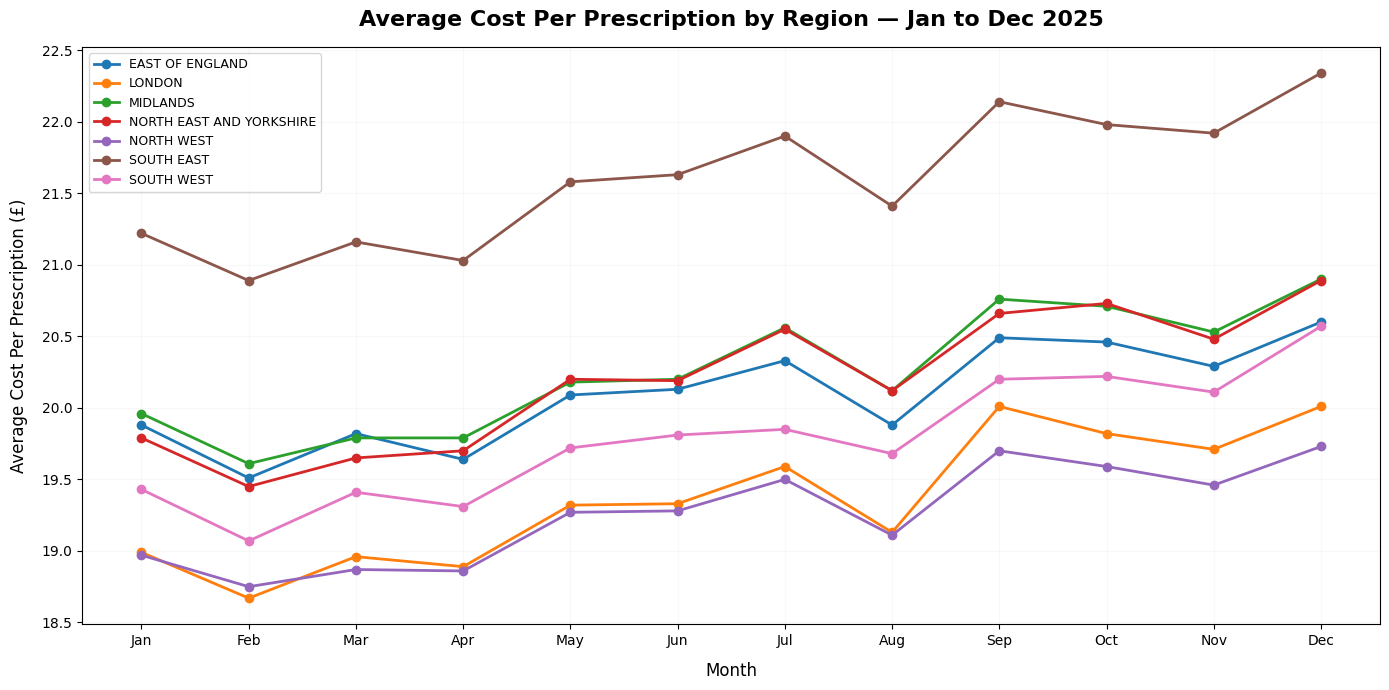

Chart saved


In [56]:
# Pivot data so each region becomes a line
regional_pivot = regional_monthly.pivot(index='MONTH', columns='REGIONAL_OFFICE', values='avg_cost_per_item')
# Reshapes data so months are on x-axis and each region is a separate line

fig, ax = plt.subplots(figsize=(14, 7))

# Plot each region as a separate line
for region in regional_pivot.columns:
    ax.plot(regional_pivot.index, regional_pivot[region], marker='o', linewidth=2, label=region)
    # marker='o' adds a dot at each month point

ax.set_xlabel('Month', fontsize=12, labelpad=10)
ax.set_ylabel('Average Cost Per Prescription (£)', fontsize=12, labelpad=10)
ax.set_title('Average Cost Per Prescription by Region — Jan to Dec 2025', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
# Replaces month numbers with month names
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.08)

plt.tight_layout()
plt.savefig('chapter2_regional_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [57]:
# Check what changes in February vs January across all regions
feb_investigation = con.execute("""
    SELECT 
        MONTH,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions,
        ROUND(AVG(NIC_RATIO), 4) AS avg_nic_ratio
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    GROUP BY MONTH
    ORDER BY MONTH
""").df()

print(feb_investigation)

    MONTH  avg_cost_per_prescription  total_cost_millions  \
0       1                      19.76               877.23   
1       2                      19.43               782.73   
2       3                      19.67               835.90   
3       4                      19.61               833.39   
4       5                      20.06               879.41   
5       6                      20.09               861.77   
6       7                      20.35               915.59   
7       8                      19.93               832.98   
8       9                      20.58               915.37   
9      10                      20.52               993.14   
10     11                      20.37               872.11   
11     12                      20.73               940.79   

    total_items_millions  avg_nic_ratio  
0                 108.54         0.9324  
1                  96.81         0.9313  
2                 102.85         0.9319  
3                 103.10         0.933

In [58]:
# Investigate September to December rise
sep_dec_investigation = con.execute("""
    SELECT 
        MONTH,
        BNF_CHAPTER_CODE,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    WHERE MONTH IN (8, 9, 10, 11, 12)
    GROUP BY MONTH, BNF_CHAPTER_CODE
    ORDER BY MONTH, total_cost_millions DESC
""").df()
# Focuses on August to December to see what changes from Aug onwards
# Groups by drug category to see which categories drive the rise

print(sep_dec_investigation)

     MONTH                    BNF_CHAPTER_CODE  avg_cost_per_prescription  \
0        8                06: Endocrine System                      26.87   
1        8          04: Central Nervous System                      14.92   
2        8              03: Respiratory System                      22.79   
3        8           02: Cardiovascular System                       9.21   
4        8                      21: Appliances                      28.68   
..     ...                                 ...                        ...   
100     12        12: Ear, Nose and Oropharynx                      12.38   
101     12         22: Incontinence Appliances                      29.85   
102     12                     15: Anaesthesia                      19.69   
103     12    19: Other Drugs and Preparations                      26.64   
104     12  18: Preparations used in Diagnosis                     248.53   

     total_cost_millions  total_items_millions  
0                 175.34  

In [59]:
# Investigate South East gap — what drug categories are driving higher costs
south_east_gap = con.execute("""
    SELECT 
        REGIONAL_OFFICE,
        BNF_CHAPTER_CODE,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    WHERE REGIONAL_OFFICE IN ('SOUTH EAST', 'NORTH WEST')
    GROUP BY REGIONAL_OFFICE, BNF_CHAPTER_CODE
    ORDER BY REGIONAL_OFFICE, avg_cost_per_prescription DESC
""").df()
# Comparing South East (most expensive) vs North West (cheapest)
# to find which drug categories are driving the gap

print(south_east_gap)

   REGIONAL_OFFICE                                   BNF_CHAPTER_CODE  \
0       NORTH WEST                 18: Preparations used in Diagnosis   
1       NORTH WEST                               23: Stoma Appliances   
2       NORTH WEST        08: Malignant Disease and Immunosuppression   
3       NORTH WEST                                      20: Dressings   
4       NORTH WEST                            09: Nutrition and Blood   
5       NORTH WEST                        22: Incontinence Appliances   
6       NORTH WEST                               06: Endocrine System   
7       NORTH WEST                                     21: Appliances   
8       NORTH WEST                                    15: Anaesthesia   
9       NORTH WEST                             03: Respiratory System   
10      NORTH WEST                       01: Gastro-Intestinal System   
11      NORTH WEST                   19: Other Drugs and Preparations   
12      NORTH WEST            14: Immunological Pro

In [60]:
# Investigate whether all regions move in the same direction each month
correlation_data = con.execute("""
    SELECT 
        MONTH,
        REGIONAL_OFFICE,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    GROUP BY MONTH, REGIONAL_OFFICE
    ORDER BY MONTH, REGIONAL_OFFICE
""").df()
# Gets monthly average cost per prescription for each region

# Pivot to get regions as columns
correlation_pivot = correlation_data.pivot(index='MONTH', columns='REGIONAL_OFFICE', values='avg_cost_per_prescription')

# Calculate correlation between all regions
correlation_matrix = correlation_pivot.corr()
# Correlation of 1.0 means two regions move perfectly together
# Correlation of 0.0 means they move independently

print(correlation_matrix.round(4))

REGIONAL_OFFICE           EAST OF ENGLAND  LONDON  MIDLANDS  \
REGIONAL_OFFICE                                               
EAST OF ENGLAND                    1.0000  0.9844    0.9841   
LONDON                             0.9844  1.0000    0.9892   
MIDLANDS                           0.9841  0.9892    1.0000   
NORTH EAST AND YORKSHIRE           0.9764  0.9766    0.9928   
NORTH WEST                         0.9864  0.9905    0.9925   
SOUTH EAST                         0.9896  0.9897    0.9912   
SOUTH WEST                         0.9675  0.9732    0.9732   

REGIONAL_OFFICE           NORTH EAST AND YORKSHIRE  NORTH WEST  SOUTH EAST  \
REGIONAL_OFFICE                                                              
EAST OF ENGLAND                             0.9764      0.9864      0.9896   
LONDON                                      0.9766      0.9905      0.9897   
MIDLANDS                                    0.9928      0.9925      0.9912   
NORTH EAST AND YORKSHIRE                  

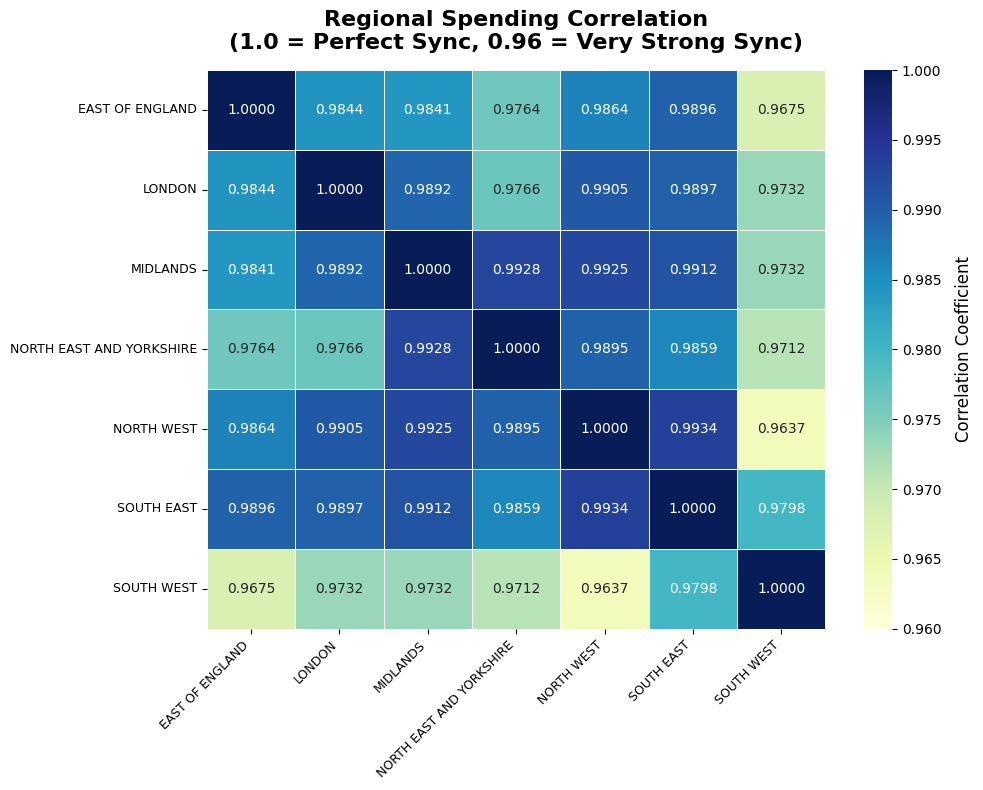

Chart saved


In [61]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    # Shows the correlation number inside each cell
    fmt='.4f',
    # Shows 4 decimal places
    cmap='YlGnBu',
    center=0.98,
    # Yellow to red color scale — darker red means higher correlation
    vmin=0.96,
    vmax=1.0,
    # Sets the color scale range to highlight differences between high correlations
    linewidths=0.5,
    ax=ax
    
)

cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel('Correlation Coefficient', labelpad=10, fontsize=12)

ax.set_title('Regional Spending Correlation\n(1.0 = Perfect Sync, 0.96 = Very Strong Sync)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('chapter2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [62]:
# Step 2: Average COST_PER_ITEM per ICB across all 12 months
icb_avg = con.execute("""
    SELECT 
        ICB_NAME,
        REGIONAL_OFFICE,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    GROUP BY ICB_NAME, REGIONAL_OFFICE
    ORDER BY avg_cost_per_prescription DESC
""").df()
# Groups by ICB and calculates average cost per prescription across all 12 months
# Also includes which region each ICB belongs to

print(f"Total ICBs: {len(icb_avg)}")
print(icb_avg.head(10))

Total ICBs: 76
                                            ICB_NAME  \
0  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
1                   NHS SUSSEX INTEGRATED CARE BOARD   
2  NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...   
3  NHS SHROPSHIRE, TELFORD AND WREKIN INTEGRATED ...   
4           NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRAT   
5  NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE...   
6        NHS SURREY HEARTLANDS INTEGRATED CARE BOARD   
7  NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE...   
8          NHS KENT AND MEDWAY INTEGRATED CARE BOARD   
9           NHS WEST YORKSHIRE INTEGRATED CARE BOARD   

            REGIONAL_OFFICE  avg_cost_per_prescription  total_cost_millions  \
0                SOUTH EAST                      22.24               292.68   
1                SOUTH EAST                      21.92               346.75   
2                  MIDLANDS                      21.89               134.73   
3                  MIDLANDS                      21.

In [63]:
# Bottom 10 ICBs by avg cost per prescription
print(icb_avg.tail(10))

                                             ICB_NAME  \
66           NHS GREATER MANCHESTER INTEGRATED CARE B   
67           NHS SOUTH WEST LONDON INTEGRATED CARE BO   
68           NHS GLOUCESTERSHIRE INTEGRATED CARE BOAR   
69           NHS BATH AND NORTH EAST SOMERSET, SWINDO   
70  NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEGRATED ...   
71          NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD   
72        NHS NORTH WEST LONDON INTEGRATED CARE BOARD   
73           NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEG   
74           NHS SOUTH YORKSHIRE INTEGRATED CARE BOAR   
75           NHS NORTH WEST LONDON INTEGRATED CARE BO   

             REGIONAL_OFFICE  avg_cost_per_prescription  total_cost_millions  \
66                NORTH WEST                      18.80                93.44   
67                    LONDON                      18.78                32.85   
68                SOUTH WEST                      18.75                17.81   
69                SOUTH WEST                      18

In [64]:
# Check duplicate ICBs
print(icb_avg[icb_avg['ICB_NAME'].str.contains('NOTTINGHAM|SOUTH YORKSHIRE|NORTH WEST LONDON')])
# Shows all rows containing these ICB names to see the exact differences

                                             ICB_NAME  \
70  NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEGRATED ...   
71          NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD   
72        NHS NORTH WEST LONDON INTEGRATED CARE BOARD   
73           NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEG   
74           NHS SOUTH YORKSHIRE INTEGRATED CARE BOAR   
75           NHS NORTH WEST LONDON INTEGRATED CARE BO   

             REGIONAL_OFFICE  avg_cost_per_prescription  total_cost_millions  \
70                  MIDLANDS                      18.44               172.14   
71  NORTH EAST AND YORKSHIRE                      18.26               234.56   
72                    LONDON                      18.13               262.37   
73                  MIDLANDS                      18.03                32.46   
74  NORTH EAST AND YORKSHIRE                      17.77                43.73   
75                    LONDON                      17.58                48.85   

    total_items_millions  
70          

In [65]:
# Get all ICB names to check in data wrangler
icb_names_check = con.execute("""
    SELECT DISTINCT ICB_NAME
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
    ORDER BY ICB_NAME
""").df()

icb_names_check

,ICB_NAME
0,"NHS BATH AND NORTH EAST SOMERSET, SWINDO"
1,"NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ..."
2,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNE"
3,"NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE..."
4,NHS BIRMINGHAM AND SOLIHULL INTEGRATED C
...,...
71,NHS SUFFOLK AND NORTH EAST ESSEX INTEGRATED CA...
72,NHS SURREY HEARTLANDS INTEGRATED CARE BO
73,NHS SURREY HEARTLANDS INTEGRATED CARE BOARD
74,NHS SUSSEX INTEGRATED CARE BOARD


In [66]:
# con.execute("""
#     COPY (
#         SELECT 
#             YEAR_MONTH, REGIONAL_OFFICE,
#             CASE 
#                 WHEN ICB_NAME LIKE 'NHS BATH AND NORTH EAST SOMERSET, SWINDO%' THEN 'NHS BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS BEDFORDSHIRE, LUTON AND MILTON KEYNE%' THEN 'NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS BIRMINGHAM AND SOLIHULL INTEGRATED C%' THEN 'NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS BRISTOL, NORTH SOMERSET AND SOUTH GL%' THEN 'NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCESTERSHIRE INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BER%' THEN 'NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE WEST INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS CAMBRIDGESHIRE AND PETERBOROUGH INTE%' THEN 'NHS CAMBRIDGESHIRE AND PETERBOROUGH INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS CHESHIRE AND MERSEYSIDE INTEGRATED C%' THEN 'NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS CORNWALL AND THE ISLES OF SCILLY INT%' THEN 'NHS CORNWALL AND THE ISLES OF SCILLY INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS COVENTRY AND WARWICKSHIRE INTEGRATED%' THEN 'NHS COVENTRY AND WARWICKSHIRE INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS DERBY AND DERBYSHIRE INTEGRATED CARE%' THEN 'NHS DERBY AND DERBYSHIRE INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS GLOUCESTERSHIRE INTEGRATED CARE BOAR%' THEN 'NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS GREATER MANCHESTER INTEGRATED CARE B%' THEN 'NHS GREATER MANCHESTER INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRAT%' THEN 'NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS HEREFORDSHIRE AND WORCESTERSHIRE INT%' THEN 'NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS HERTFORDSHIRE AND WEST ESSEX INTEGRA%' THEN 'NHS HERTFORDSHIRE AND WEST ESSEX INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS HUMBER AND NORTH YORKSHIRE INTEGRATE%' THEN 'NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS KENT AND MEDWAY INTEGRATED CARE BOAR%' THEN 'NHS KENT AND MEDWAY INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRA%' THEN 'NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS LEICESTER, LEICESTERSHIRE AND RUTLAN%' THEN 'NHS LEICESTER, LEICESTERSHIRE AND RUTLAND INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS MID AND SOUTH ESSEX INTEGRATED CARE%' THEN 'NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS NORFOLK AND WAVENEY INTEGRATED CARE%' THEN 'NHS NORFOLK AND WAVENEY INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS NORTH CENTRAL LONDON INTEGRATED CARE%' THEN 'NHS NORTH CENTRAL LONDON INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS NORTH EAST AND NORTH CUMBRIA INTEGRA%' THEN 'NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS NORTH EAST LONDON INTEGRATED CARE BO%' THEN 'NHS NORTH EAST LONDON INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS NORTH WEST LONDON INTEGRATED CARE BO%' THEN 'NHS NORTH WEST LONDON INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS NORTHAMPTONSHIRE INTEGRATED CARE BOA%' THEN 'NHS NORTHAMPTONSHIRE INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEG%' THEN 'NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS SHROPSHIRE, TELFORD AND WREKIN INTEG%' THEN 'NHS SHROPSHIRE, TELFORD AND WREKIN INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS SOUTH EAST LONDON INTEGRATED CARE BO%' THEN 'NHS SOUTH EAST LONDON INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS SOUTH WEST LONDON INTEGRATED CARE BO%' THEN 'NHS SOUTH WEST LONDON INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS SOUTH YORKSHIRE INTEGRATED CARE BOAR%' THEN 'NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS STAFFORDSHIRE AND STOKE-ON-TRENT INT%' THEN 'NHS STAFFORDSHIRE AND STOKE-ON-TRENT INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS SUFFOLK AND NORTH EAST ESSEX INTEGRA%' THEN 'NHS SUFFOLK AND NORTH EAST ESSEX INTEGRATED CARE BOARD'
#                 WHEN ICB_NAME LIKE 'NHS SURREY HEARTLANDS INTEGRATED CARE BO%' THEN 'NHS SURREY HEARTLANDS INTEGRATED CARE BOARD'
#                 ELSE ICB_NAME
#             END AS ICB_NAME,
#             ICB_CODE, PRACTICE_NAME, PRACTICE_CODE, BNF_CHAPTER_CODE,
#             DRUG_NAME, DRUG_DESCRIPTION, ITEMS, TOTAL_QUANTITY, ADQ_USAGE,
#             NIC, ACTUAL_COST, COST_PER_ITEM, NIC_RATIO, MONTH, QUARTER
#         FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_clean.parquet')
#     )
#     TO 'D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet'
#     (FORMAT PARQUET)
# """)

# print("Done — merged_dataset_final.parquet saved")

In [67]:
# Check how many unique ICBs we have now
icb_check = con.execute("""
    SELECT COUNT(DISTINCT ICB_NAME) AS total_icbs
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
""").df()

print(icb_check)

   total_icbs
0          42


In [68]:
# Check all unique ICB names in the fixed dataset
icb_names_final = con.execute("""
    SELECT DISTINCT ICB_NAME
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    ORDER BY ICB_NAME
""").df()

print(icb_names_final)

                                             ICB_NAME
0   NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...
1   NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...
2   NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD
3             NHS BLACK COUNTRY INTEGRATED CARE BOARD
4   NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST...
5   NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE...
6   NHS CAMBRIDGESHIRE AND PETERBOROUGH INTEGRATED...
7   NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD
8   NHS CORNWALL AND THE ISLES OF SCILLY INTEGRATE...
9   NHS COVENTRY AND WARWICKSHIRE INTEGRATED CARE ...
10     NHS DERBY AND DERBYSHIRE INTEGRATED CARE BOARD
11                    NHS DEVON INTEGRATED CARE BOARD
12                   NHS DORSET INTEGRATED CARE BOARD
13                  NHS FRIMLEY INTEGRATED CARE BOARD
14          NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD
15       NHS GREATER MANCHESTER INTEGRATED CARE BOARD
16  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...
17  NHS HEREFORDSHIRE AND WO

In [69]:
# Check the official NHS ICB list against our dataset
# England has exactly 42 ICBs as of 2025
# Let's print all 42 and manually verify

icb_names_final = con.execute("""
    SELECT DISTINCT ICB_NAME
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    ORDER BY ICB_NAME
""").df()

for i, name in enumerate(icb_names_final['ICB_NAME'], 1):
    print(f"{i}. {name}")

1. NHS BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE BOARD
2. NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTEGRATED CARE BOARD
3. NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD
4. NHS BLACK COUNTRY INTEGRATED CARE BOARD
5. NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCESTERSHIRE INTEGRATED CARE BOARD
6. NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE WEST INTEGRATED CARE BOARD
7. NHS CAMBRIDGESHIRE AND PETERBOROUGH INTEGRATED CARE BOARD
8. NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD
9. NHS CORNWALL AND THE ISLES OF SCILLY INTEGRATED CARE BOARD
10. NHS COVENTRY AND WARWICKSHIRE INTEGRATED CARE BOARD
11. NHS DERBY AND DERBYSHIRE INTEGRATED CARE BOARD
12. NHS DEVON INTEGRATED CARE BOARD
13. NHS DORSET INTEGRATED CARE BOARD
14. NHS FRIMLEY INTEGRATED CARE BOARD
15. NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD
16. NHS GREATER MANCHESTER INTEGRATED CARE BOARD
17. NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CARE BOARD
18. NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATED C

In [70]:
# From now on use the final clean dataset
DATASET = 'D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet'

In [71]:
# Step 2: ICB level analysis with fixed names
icb_avg = con.execute(f"""
    SELECT 
        ICB_NAME,
        REGIONAL_OFFICE,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions
    FROM read_parquet('{DATASET}')
    GROUP BY ICB_NAME, REGIONAL_OFFICE
    ORDER BY avg_cost_per_prescription DESC
""").df()

print(f"Total ICBs: {len(icb_avg)}")
print(icb_avg.head(10))

Total ICBs: 42
                                            ICB_NAME  \
0  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
1                   NHS SUSSEX INTEGRATED CARE BOARD   
2  NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...   
3  NHS SHROPSHIRE, TELFORD AND WREKIN INTEGRATED ...   
4        NHS SURREY HEARTLANDS INTEGRATED CARE BOARD   
5  NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE...   
6  NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE...   
7          NHS KENT AND MEDWAY INTEGRATED CARE BOARD   
8           NHS WEST YORKSHIRE INTEGRATED CARE BOARD   
9                  NHS FRIMLEY INTEGRATED CARE BOARD   

            REGIONAL_OFFICE  avg_cost_per_prescription  total_cost_millions  \
0                SOUTH EAST                      22.14               347.80   
1                SOUTH EAST                      21.92               346.75   
2                  MIDLANDS                      21.77               159.52   
3                  MIDLANDS                      21.

In [72]:
# Step 3: Top 10 and bottom 10 ICBs
print("--- TOP 10 ICBs by avg cost per prescription ---")
print(icb_avg.head(10)[['ICB_NAME', 'REGIONAL_OFFICE', 'avg_cost_per_prescription']])

print("\n--- BOTTOM 10 ICBs by avg cost per prescription ---")
print(icb_avg.tail(10)[['ICB_NAME', 'REGIONAL_OFFICE', 'avg_cost_per_prescription']])

--- TOP 10 ICBs by avg cost per prescription ---
                                            ICB_NAME  \
0  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
1                   NHS SUSSEX INTEGRATED CARE BOARD   
2  NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...   
3  NHS SHROPSHIRE, TELFORD AND WREKIN INTEGRATED ...   
4        NHS SURREY HEARTLANDS INTEGRATED CARE BOARD   
5  NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE...   
6  NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE...   
7          NHS KENT AND MEDWAY INTEGRATED CARE BOARD   
8           NHS WEST YORKSHIRE INTEGRATED CARE BOARD   
9                  NHS FRIMLEY INTEGRATED CARE BOARD   

            REGIONAL_OFFICE  avg_cost_per_prescription  
0                SOUTH EAST                      22.14  
1                SOUTH EAST                      21.92  
2                  MIDLANDS                      21.77  
3                  MIDLANDS                      21.56  
4                SOUTH EAST                      

In [73]:
# Step 4: Consistency check — are the same ICBs always at the top month after month?
icb_monthly = con.execute("""
    SELECT 
        ICB_NAME,
        MONTH,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    GROUP BY ICB_NAME, MONTH
    ORDER BY MONTH, avg_cost_per_prescription DESC
""").df()
# Gets average cost per prescription for each ICB for each month

# Check ranking of top 5 ICBs across all 12 months
top5_icbs = icb_avg.head(5)['ICB_NAME'].tolist()
# Gets the names of top 5 ICBs

top5_monthly = icb_monthly[icb_monthly['ICB_NAME'].isin(top5_icbs)]
# Filters monthly data for only the top 5 ICBs

print(top5_monthly.pivot(index='MONTH', columns='ICB_NAME', values='avg_cost_per_prescription'))
# Shows each top 5 ICB cost per month in a table

ICB_NAME  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CARE BOARD  \
MONTH                                                             
1                                                     21.76       
2                                                     21.49       
3                                                     21.81       
4                                                     21.52       
5                                                     21.98       
6                                                     22.01       
7                                                     22.32       
8                                                     21.74       
9                                                     22.59       
10                                                    22.48       
11                                                    22.80       
12                                                    23.11       

ICB_NAME  NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATED CAR

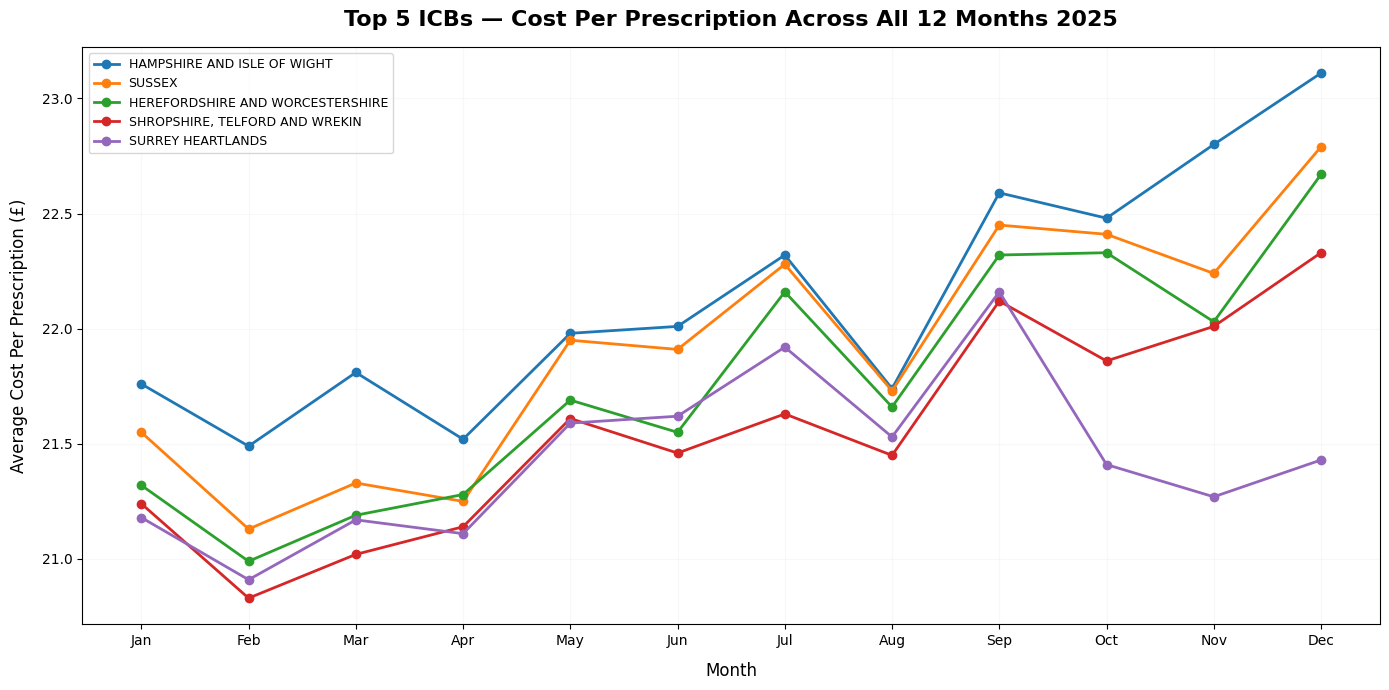

Chart saved


In [74]:
# Shorten ICB names for the chart
top5_monthly['short_name'] = top5_monthly['ICB_NAME'].str.replace('INTEGRATED CARE BOARD', '').str.replace('NHS ', '').str.strip()
# Removes common words to make names shorter and readable

fig, ax = plt.subplots(figsize=(14, 7))

for icb in top5_monthly['short_name'].unique():
    data = top5_monthly[top5_monthly['short_name'] == icb]
    ax.plot(data['MONTH'], data['avg_cost_per_prescription'], 
            marker='o', linewidth=2, label=icb)
    # Plots each ICB as a separate line with dots at each month

ax.set_xlabel('Month', fontsize=12, labelpad=10)
ax.set_ylabel('Average Cost Per Prescription (£)', fontsize=12, labelpad=10)
ax.set_title('Top 5 ICBs — Cost Per Prescription Across All 12 Months 2025', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.08)

plt.tight_layout()
plt.savefig('chapter2_top5_icb_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [75]:
# Investigate Surrey Heartlands Q4 drop
surrey_investigation = con.execute("""
    SELECT 
        MONTH,
        BNF_CHAPTER_CODE,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE ICB_NAME = 'NHS SURREY HEARTLANDS INTEGRATED CARE BOARD'
    AND MONTH IN (9, 10, 11)
    GROUP BY MONTH, BNF_CHAPTER_CODE
    ORDER BY MONTH, total_cost_millions DESC
""").df()
# Focuses on September to November for Surrey Heartlands
# to find which drug category drops in October and November

print(surrey_investigation)

    MONTH                                   BNF_CHAPTER_CODE  \
0       9                               06: Endocrine System   
1       9                         04: Central Nervous System   
2       9                             03: Respiratory System   
3       9                          02: Cardiovascular System   
4       9                                     21: Appliances   
5       9                            09: Nutrition and Blood   
6       9                       01: Gastro-Intestinal System   
7       9                               23: Stoma Appliances   
8       9  07: Obstetrics, Gynaecology and Urinary-Tract ...   
9       9                                           13: Skin   
10      9        08: Malignant Disease and Immunosuppression   
11      9                                     05: Infections   
12      9                                            11: Eye   
13      9             10: Musculoskeletal and Joint Diseases   
14      9                       12: Ear,

In [76]:
# Step 5: Drill down by drug category for top 5 high spending ICBs
top5_drug_breakdown = con.execute("""
    SELECT 
        ICB_NAME,
        BNF_CHAPTER_CODE,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE ICB_NAME IN (
        'NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CARE BOARD',
        'NHS SUSSEX INTEGRATED CARE BOARD',
        'NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATED CARE BOARD',
        'NHS SHROPSHIRE, TELFORD AND WREKIN INTEGRATED CARE BOARD',
        'NHS SURREY HEARTLANDS INTEGRATED CARE BOARD'
    )
    GROUP BY ICB_NAME, BNF_CHAPTER_CODE
    ORDER BY ICB_NAME, total_cost_millions DESC
""").df()
# Shows which drug categories are driving high costs in each top 5 ICB

print(top5_drug_breakdown)

                                              ICB_NAME  \
0    NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
1    NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
2    NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
3    NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
4    NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
..                                                 ...   
97                    NHS SUSSEX INTEGRATED CARE BOARD   
98                    NHS SUSSEX INTEGRATED CARE BOARD   
99                    NHS SUSSEX INTEGRATED CARE BOARD   
100                   NHS SUSSEX INTEGRATED CARE BOARD   
101                   NHS SUSSEX INTEGRATED CARE BOARD   

                       BNF_CHAPTER_CODE  avg_cost_per_prescription  \
0                  06: Endocrine System                      33.76   
1            04: Central Nervous System                      17.30   
2                03: Respiratory System                      24.72   
3             02: Cardi

In [77]:
# Step 6: NIC_RATIO check for top 5 high spending ICBs vs bottom 5
nic_ratio_check = con.execute("""
    SELECT 
        ICB_NAME,
        REGIONAL_OFFICE,
        ROUND(AVG(NIC_RATIO), 4) AS avg_nic_ratio,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE ICB_NAME IN (
        'NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CARE BOARD',
        'NHS SUSSEX INTEGRATED CARE BOARD',
        'NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATED CARE BOARD',
        'NHS SHROPSHIRE, TELFORD AND WREKIN INTEGRATED CARE BOARD',
        'NHS SURREY HEARTLANDS INTEGRATED CARE BOARD',
        'NHS NORTH WEST LONDON INTEGRATED CARE BOARD',
        'NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD',
        'NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEGRATED CARE BOARD',
        'NHS BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE BOARD',
        'NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD'
    )
    GROUP BY ICB_NAME, REGIONAL_OFFICE
    ORDER BY avg_nic_ratio DESC
""").df()
# Compares NIC_RATIO between top 5 and bottom 5 ICBs
# NIC_RATIO > 1 means paying above standard NHS price
# NIC_RATIO < 1 means paying below standard NHS price

print(nic_ratio_check)

                                            ICB_NAME  \
0          NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD   
1        NHS NORTH WEST LONDON INTEGRATED CARE BOARD   
2          NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD   
3                   NHS SUSSEX INTEGRATED CARE BOARD   
4  NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...   
5  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
6  NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEGRATED ...   
7        NHS SURREY HEARTLANDS INTEGRATED CARE BOARD   
8  NHS SHROPSHIRE, TELFORD AND WREKIN INTEGRATED ...   
9  NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...   

            REGIONAL_OFFICE  avg_nic_ratio  avg_cost_per_prescription  
0                SOUTH WEST         0.9415                      19.16  
1                    LONDON         0.9411                      18.04  
2  NORTH EAST AND YORKSHIRE         0.9396                      18.18  
3                SOUTH EAST         0.9384                      21.92  
4                SOUTH 

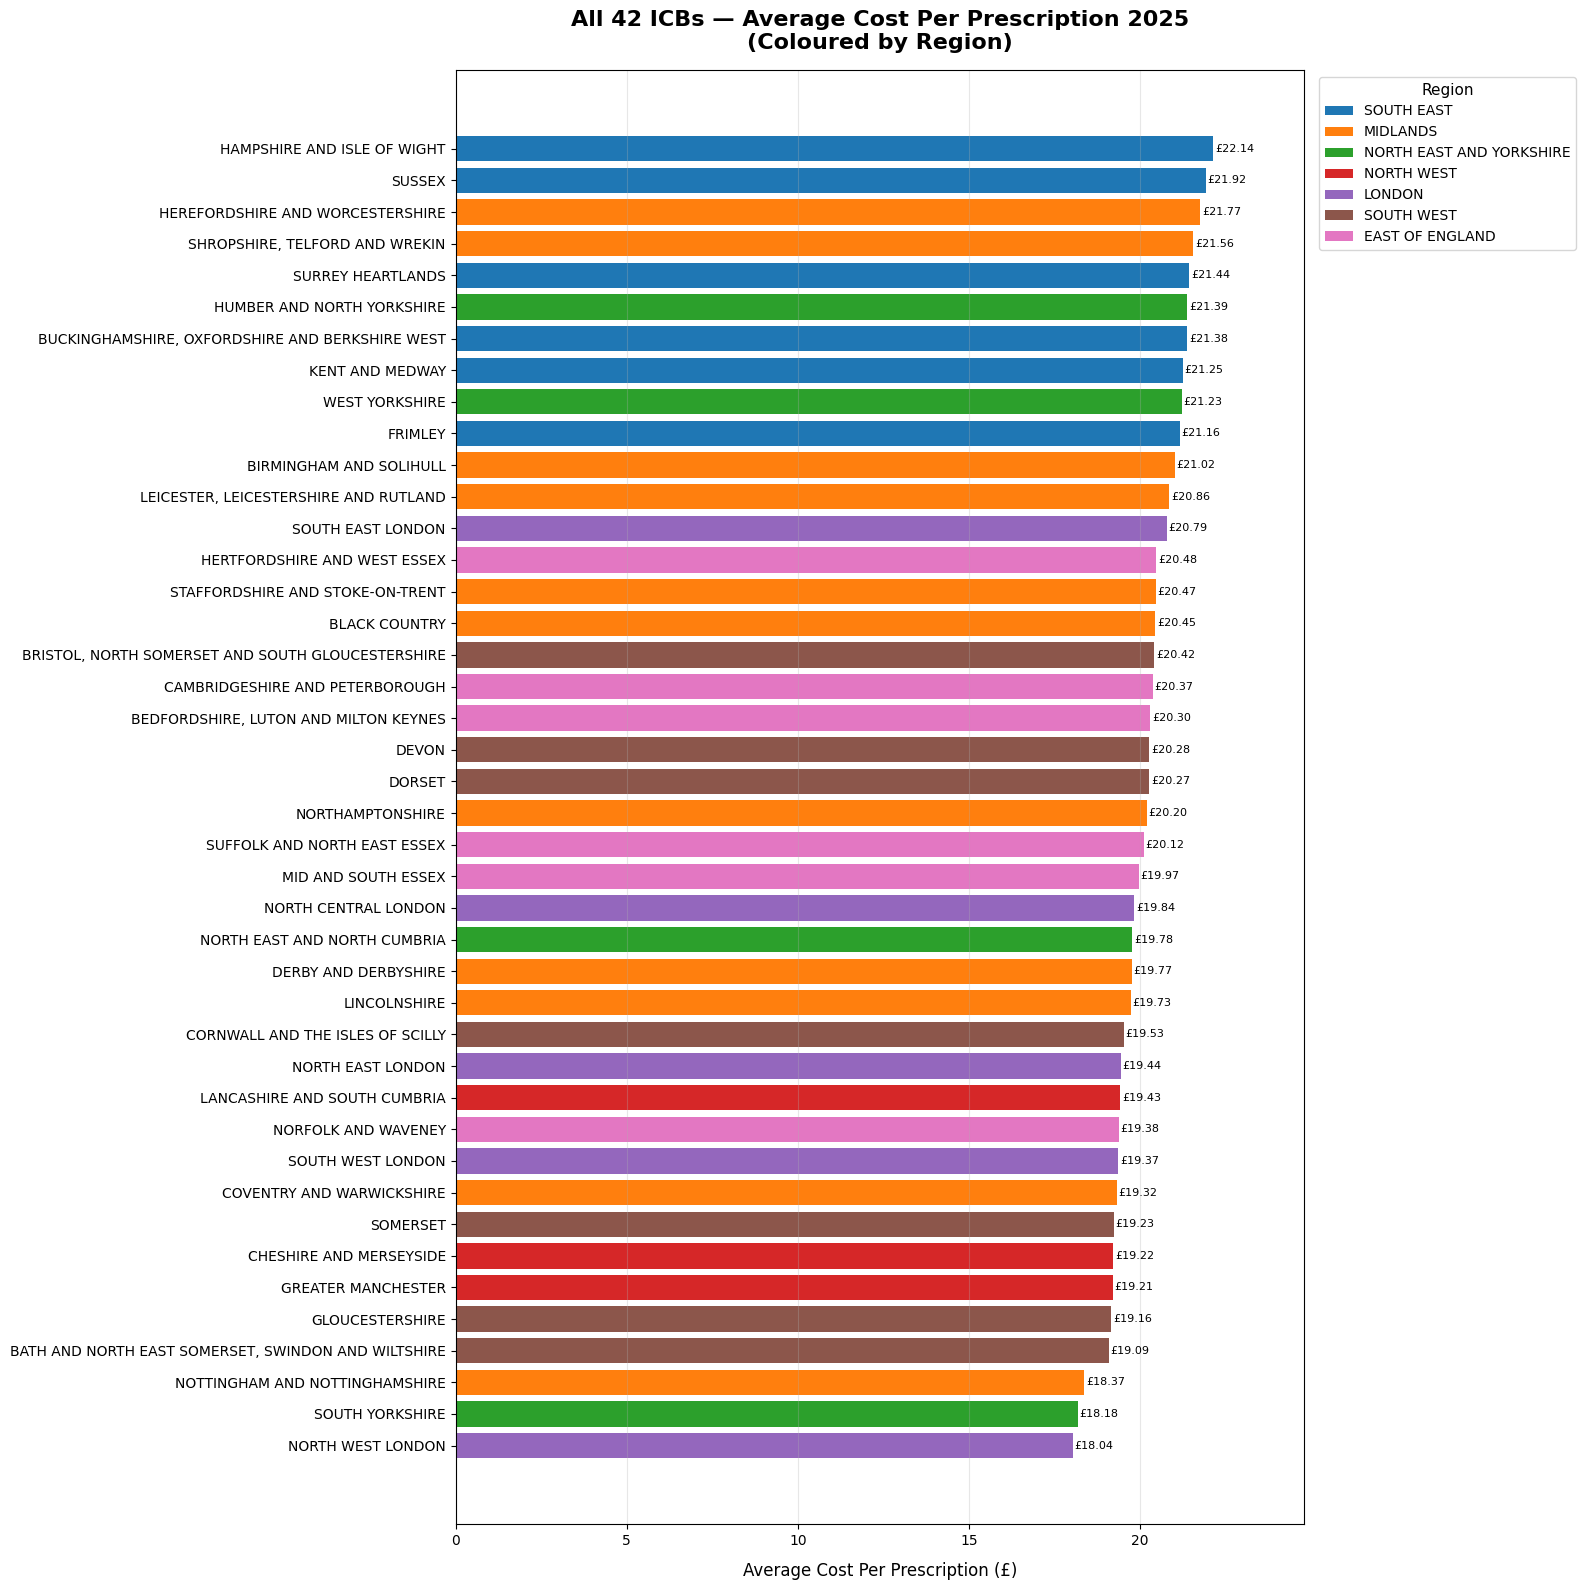

Chart saved


In [78]:
# Shorten ICB names for chart
icb_avg['short_name'] = icb_avg['ICB_NAME'].str.replace('INTEGRATED CARE BOARD', '').str.replace('NHS ', '').str.strip()

fig, ax = plt.subplots(figsize=(16, 16))

# Color bars by region
region_colors = {
    'SOUTH EAST': '#1f77b4',
    'MIDLANDS': '#ff7f0e',
    'NORTH EAST AND YORKSHIRE': '#2ca02c',
    'NORTH WEST': '#d62728',
    'LONDON': '#9467bd',
    'SOUTH WEST': '#8c564b',
    'EAST OF ENGLAND': '#e377c2'
}

colors = [region_colors[r] for r in icb_avg['REGIONAL_OFFICE']]

bars = ax.barh(icb_avg['short_name'][::-1],
               icb_avg['avg_cost_per_prescription'][::-1],
               color=colors[::-1])

# Add value labels
for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'£{bar.get_width():.2f}', va='center', fontsize=8)

# Legend outside the chart on the right side
legend_elements = [Patch(facecolor=color, label=region)
                   for region, color in region_colors.items()]
ax.legend(handles=legend_elements, 
          loc='upper left',
          bbox_to_anchor=(1.01, 1),
          # Places legend outside the chart to the right
          fontsize=10,
          title='Region',
          title_fontsize=11)

ax.set_xlabel('Average Cost Per Prescription (£)', fontsize=12, labelpad=10)
ax.set_title('All 42 ICBs — Average Cost Per Prescription 2025\n(Coloured by Region)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlim(0, max(icb_avg['avg_cost_per_prescription']) * 1.12)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('chapter2_icb_ranked.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

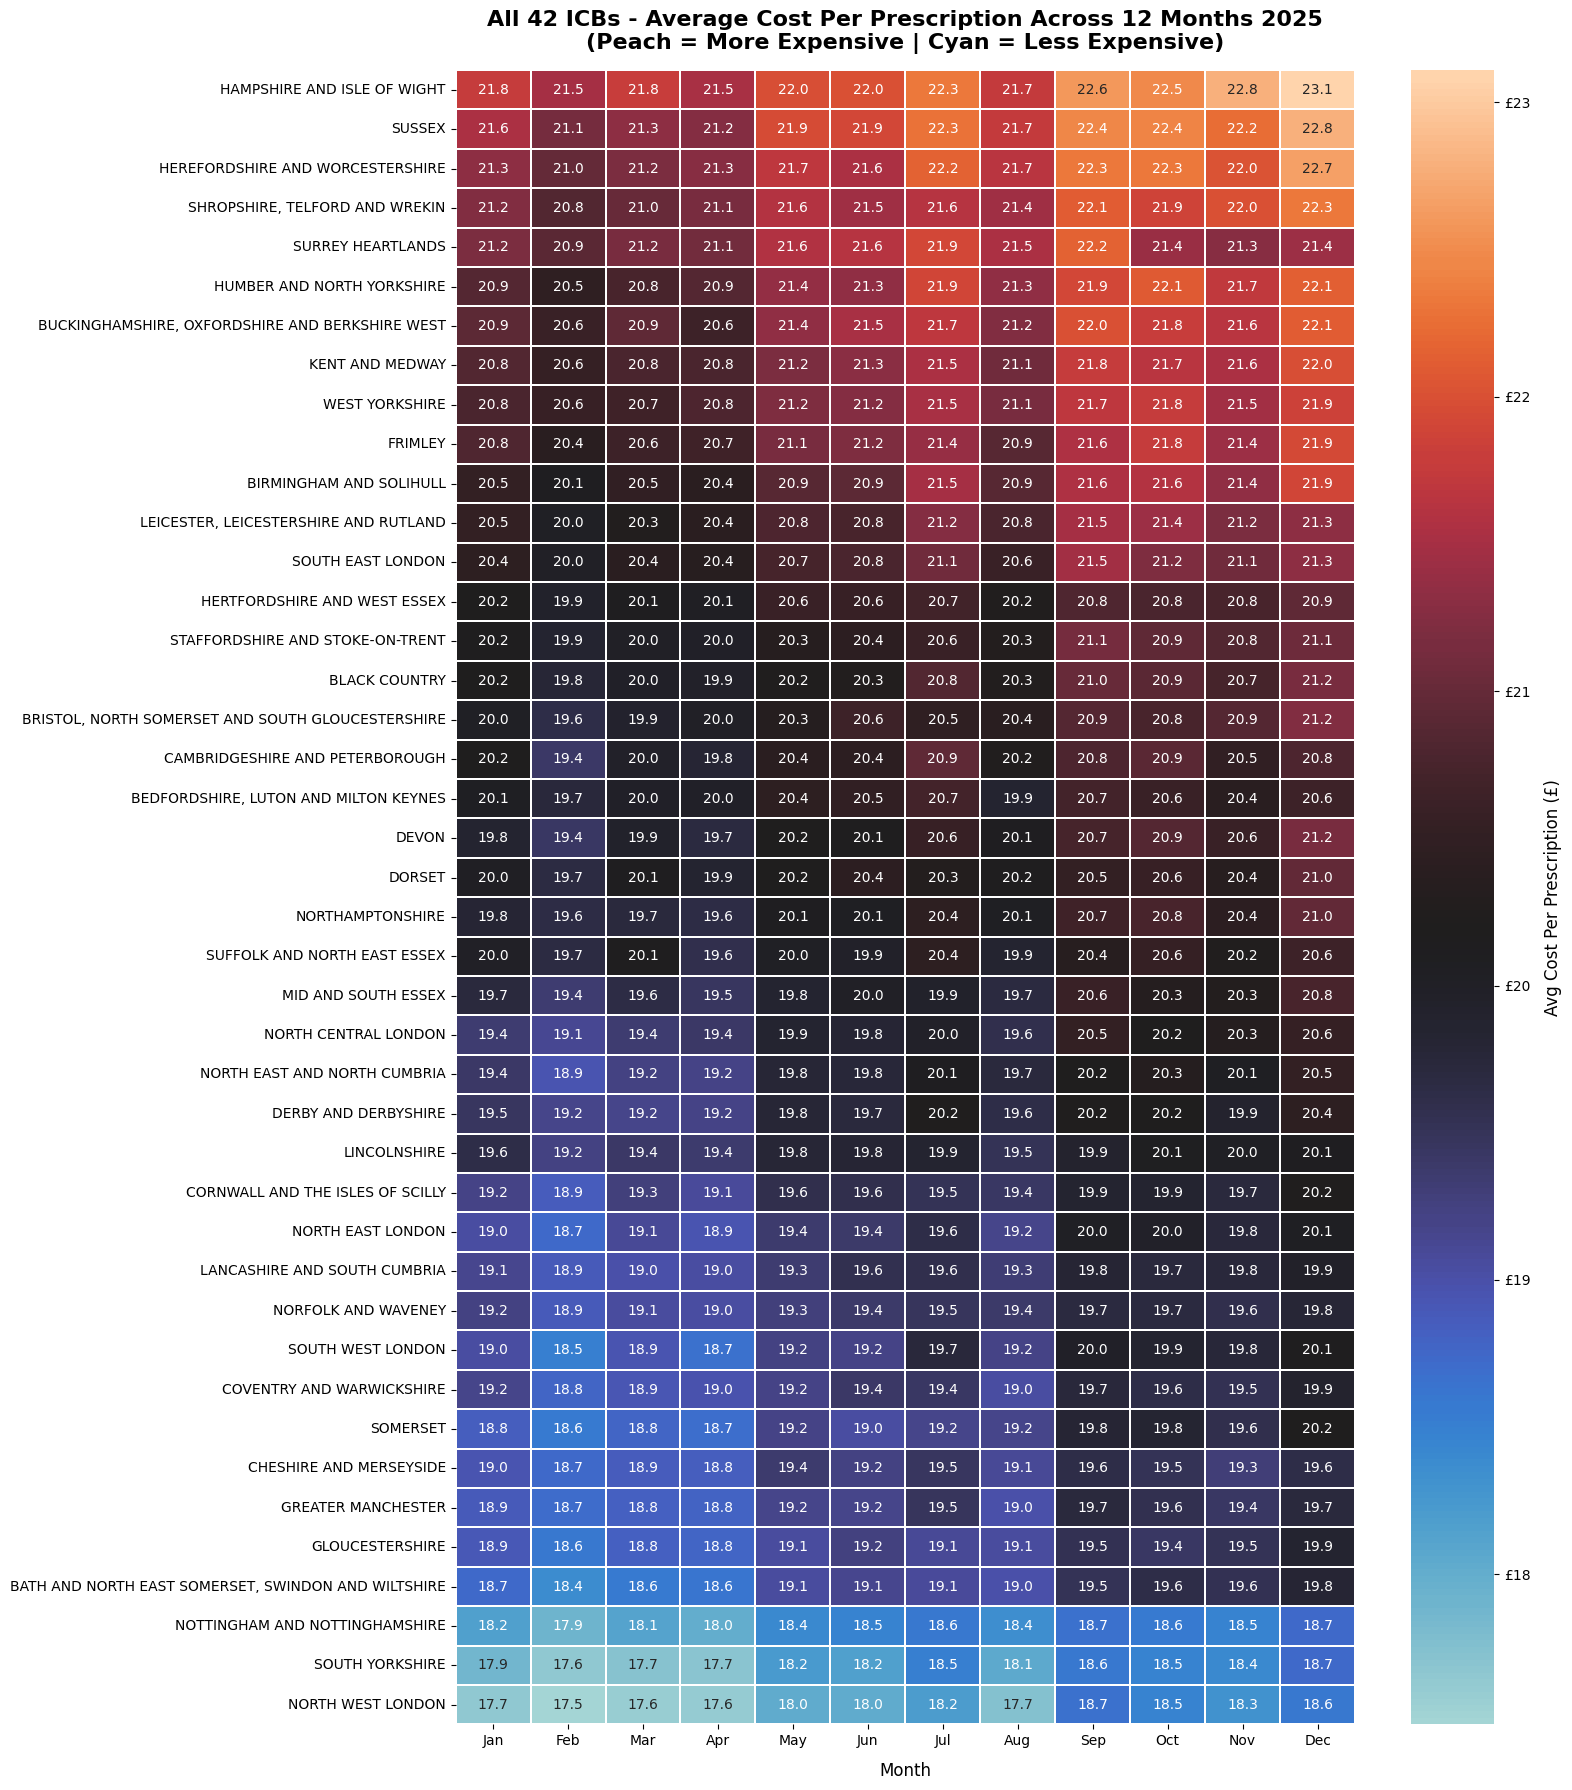

Chart saved


In [79]:
# Get monthly data for all 42 ICBs
icb_heatmap_data = con.execute("""
    SELECT 
        ICB_NAME,
        MONTH,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    GROUP BY ICB_NAME, MONTH
    ORDER BY ICB_NAME, MONTH
""").df()

# Shorten ICB names
icb_heatmap_data['short_name'] = icb_heatmap_data['ICB_NAME'].str.replace('INTEGRATED CARE BOARD', '').str.replace('NHS ', '').str.strip()

# Pivot data — rows are ICBs, columns are months
heatmap_pivot = icb_heatmap_data.pivot(index='short_name', columns='MONTH', values='avg_cost_per_prescription')
heatmap_pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Sort by average cost across all months
heatmap_pivot = heatmap_pivot.loc[heatmap_pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(16, 18))

sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt='.1f',
    center=20.19,
    vmin=17.49,
    vmax=23.11,
    # Yellow = low cost, Red = high cost
    linewidths=0.3,
    ax=ax
)

cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel('Avg Cost Per Prescription (£)', fontsize=12, labelpad=10)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:.0f}'))

ax.set_title('All 42 ICBs - Average Cost Per Prescription Across 12 Months 2025\n(Peach = More Expensive | Cyan = Less Expensive)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12, labelpad=10)
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('chapter2_icb_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [80]:
print(plt.rcParams["image.cmap"])

viridis


In [81]:
# Load the ICB boundary file
icb_map = gpd.read_file("D:/UEA/Business Analytics/P1/Code_Dataset/Integrated_Care_Boards_April_2023_EN_BGC_4724716452693616968.geojson")
# Reads the geographic boundary file

print(icb_map.columns.tolist())
# Shows all column names so we can find the ICB name column to match with our data

['FID', 'ICB23CD', 'ICB23NM', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'GlobalID', 'geometry']


In [82]:
# Check ICB names in the boundary file
print(icb_map['ICB23NM'].tolist())

['NHS Cheshire and Merseyside Integrated Care Board', 'NHS Staffordshire and Stoke-on-Trent Integrated Care Board', 'NHS Shropshire, Telford and Wrekin Integrated Care Board', 'NHS Lincolnshire Integrated Care Board', 'NHS Leicester, Leicestershire and Rutland Integrated Care Board', 'NHS Coventry and Warwickshire Integrated Care Board', 'NHS Herefordshire and Worcestershire Integrated Care Board', 'NHS Norfolk and Waveney Integrated Care Board', 'NHS Suffolk and North East Essex Integrated Care Board', 'NHS Bedfordshire, Luton and Milton Keynes Integrated Care Board', 'NHS Hertfordshire and West Essex Integrated Care Board', 'NHS Mid and South Essex Integrated Care Board', 'NHS North West London Integrated Care Board', 'NHS North Central London Integrated Care Board', 'NHS North East London Integrated Care Board', 'NHS South East London Integrated Care Board', 'NHS South West London Integrated Care Board', 'NHS Kent and Medway Integrated Care Board', 'NHS Frimley Integrated Care Board

In [83]:
# Convert ICB names in boundary file to uppercase to match our dataset
icb_map['ICB23NM_UPPER'] = icb_map['ICB23NM'].str.upper()
# Creates a new column with uppercase names for matching

# Check if names now match
our_icbs = set(icb_avg['ICB_NAME'].tolist())
map_icbs = set(icb_map['ICB23NM_UPPER'].tolist())

print("In our data but not in map:")
print(our_icbs - map_icbs)

print("\nIn map but not in our data:")
print(map_icbs - our_icbs)

In our data but not in map:
set()

In map but not in our data:
set()


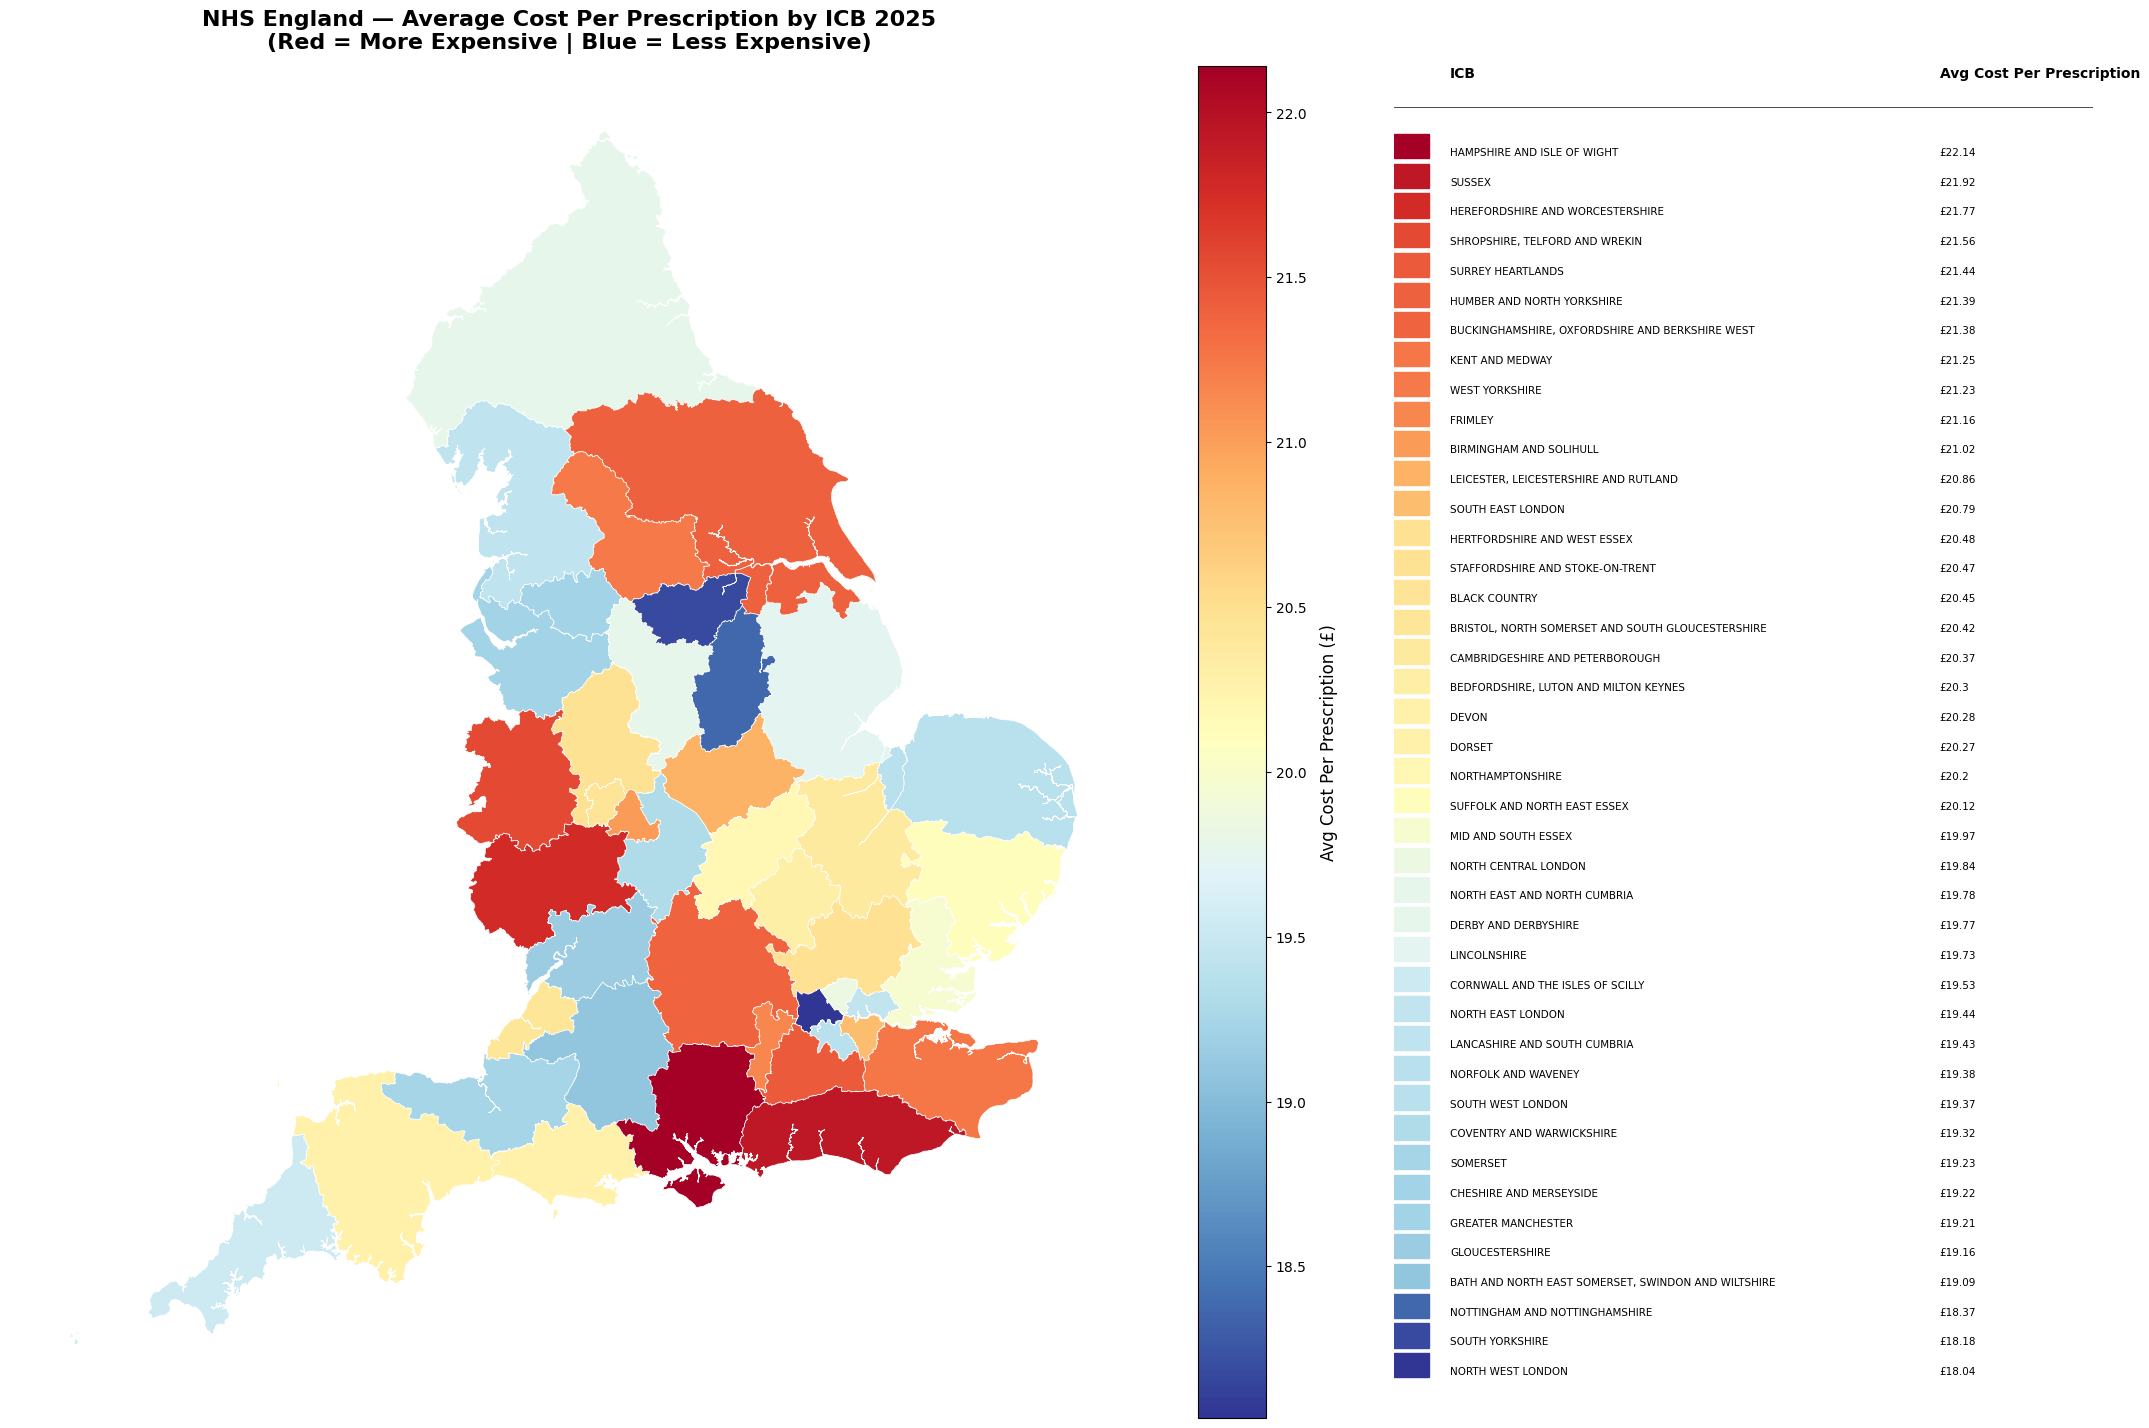

Map saved


In [84]:
# Get avg cost per prescription per ICB - already in icb_avg
icb_avg['short_name'] = icb_avg['ICB_NAME'].str.replace('INTEGRATED CARE BOARD', '').str.replace('NHS ', '').str.strip()

# Merge with boundary file
icb_map['ICB23NM_UPPER'] = icb_map['ICB23NM'].str.upper()
icb_map_merged = icb_map.merge(
    icb_avg[['ICB_NAME', 'avg_cost_per_prescription', 'short_name']],
    left_on='ICB23NM_UPPER',
    right_on='ICB_NAME',
    how='left'
)

# Sort by avg cost for legend
icb_avg_sorted = icb_avg.sort_values('avg_cost_per_prescription', ascending=False)

# Define colormap and normalizer
vmin_a = icb_avg['avg_cost_per_prescription'].min()
vmax_a = icb_avg['avg_cost_per_prescription'].max()
cmap = cm.RdYlBu_r
norm_a = mcolors.Normalize(vmin=vmin_a, vmax=vmax_a)

fig = plt.figure(figsize=(22, 14))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1])

ax_map = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

# Plot map
icb_map_merged.plot(
    column='avg_cost_per_prescription',
    cmap='RdYlBu_r',
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Avg Cost Per Prescription (£)', 'orientation': 'vertical'},
    ax=ax_map,
    vmin=vmin_a,
    vmax=vmax_a
)

ax_map.get_figure().axes[-1].yaxis.label.set_size(12)
ax_map.get_figure().axes[-1].yaxis.labelpad = 10

ax_map.set_title('NHS England — Average Cost Per Prescription by ICB 2025\n(Red = More Expensive | Blue = Less Expensive)', fontsize=16, fontweight='bold', pad=15)
ax_map.axis('off')

# Legend table
ax_legend.axis('off')
ax_legend.text(0.08, 1.0, 'ICB', fontsize=10, fontweight='bold', transform=ax_legend.transAxes, va='top')
ax_legend.text(0.78, 1.0, 'Avg Cost Per Prescription', fontsize=10, fontweight='bold', transform=ax_legend.transAxes, va='top')
ax_legend.plot([0, 1], [0.97, 0.97], color='black', linewidth=0.5, transform=ax_legend.transAxes)

for idx, (_, row) in enumerate(icb_avg_sorted.iterrows()):
    y_pos = 0.94 - idx * 0.022
    color = cmap(norm_a(row['avg_cost_per_prescription']))

    ax_legend.add_patch(plt.Rectangle(
        (0.0, y_pos - 0.008), 0.05, 0.018,
        color=color,
        transform=ax_legend.transAxes
    ))

    ax_legend.text(0.08, y_pos, row['short_name'], fontsize=7.5, transform=ax_legend.transAxes, va='top')
    ax_legend.text(0.78, y_pos, f"£{row['avg_cost_per_prescription']}", fontsize=7.5, transform=ax_legend.transAxes, va='top')

plt.tight_layout()
plt.savefig('chapter2_icb_avg_cost_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Map saved")

In [85]:
# Step 5 complete — Top 5 vs Bottom 5 ICBs drug category comparison
top5_bottom5_drugs = con.execute("""
    SELECT 
        ICB_NAME,
        BNF_CHAPTER_CODE,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE ICB_NAME IN (
        'NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CARE BOARD',
        'NHS SUSSEX INTEGRATED CARE BOARD',
        'NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATED CARE BOARD',
        'NHS SHROPSHIRE, TELFORD AND WREKIN INTEGRATED CARE BOARD',
        'NHS SURREY HEARTLANDS INTEGRATED CARE BOARD',
        'NHS NORTH WEST LONDON INTEGRATED CARE BOARD',
        'NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD',
        'NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEGRATED CARE BOARD',
        'NHS BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE BOARD',
        'NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD'
    )
    GROUP BY ICB_NAME, BNF_CHAPTER_CODE
    ORDER BY ICB_NAME, avg_cost_per_prescription DESC
""").df()

print(top5_bottom5_drugs)

                                              ICB_NAME  \
0    NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...   
1    NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...   
2    NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...   
3    NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...   
4    NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...   
..                                                 ...   
198                   NHS SUSSEX INTEGRATED CARE BOARD   
199                   NHS SUSSEX INTEGRATED CARE BOARD   
200                   NHS SUSSEX INTEGRATED CARE BOARD   
201                   NHS SUSSEX INTEGRATED CARE BOARD   
202                   NHS SUSSEX INTEGRATED CARE BOARD   

                                      BNF_CHAPTER_CODE  \
0                                 23: Stoma Appliances   
1          08: Malignant Disease and Immunosuppression   
2                                        20: Dressings   
3                                       21: Appliances   
4            

In [86]:
# Volume comparison — top 5 vs bottom 5 ICBs
volume_comparison = con.execute("""
    SELECT 
        ICB_NAME,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription,
        ROUND(SUM(ITEMS) / COUNT(DISTINCT MONTH), 2) AS avg_monthly_items
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE ICB_NAME IN (
        'NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CARE BOARD',
        'NHS SUSSEX INTEGRATED CARE BOARD',
        'NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATED CARE BOARD',
        'NHS SHROPSHIRE, TELFORD AND WREKIN INTEGRATED CARE BOARD',
        'NHS SURREY HEARTLANDS INTEGRATED CARE BOARD',
        'NHS NORTH WEST LONDON INTEGRATED CARE BOARD',
        'NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD',
        'NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEGRATED CARE BOARD',
        'NHS BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE INTEGRATED CARE BOARD',
        'NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD'
    )
    GROUP BY ICB_NAME
    ORDER BY avg_cost_per_prescription DESC
""").df()

print(volume_comparison)

                                            ICB_NAME  total_items_millions  \
0  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...                 36.39   
1                   NHS SUSSEX INTEGRATED CARE BOARD                 36.98   
2  NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...                 17.14   
3  NHS SHROPSHIRE, TELFORD AND WREKIN INTEGRATED ...                 10.68   
4        NHS SURREY HEARTLANDS INTEGRATED CARE BOARD                 16.61   
5          NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD                 14.84   
6  NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...                 20.64   
7  NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEGRATED ...                 26.81   
8          NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD                 39.43   
9        NHS NORTH WEST LONDON INTEGRATED CARE BOARD                 39.11   

   total_cost_millions  avg_cost_per_prescription  avg_monthly_items  
0               347.80                      22.14         3032657.25  

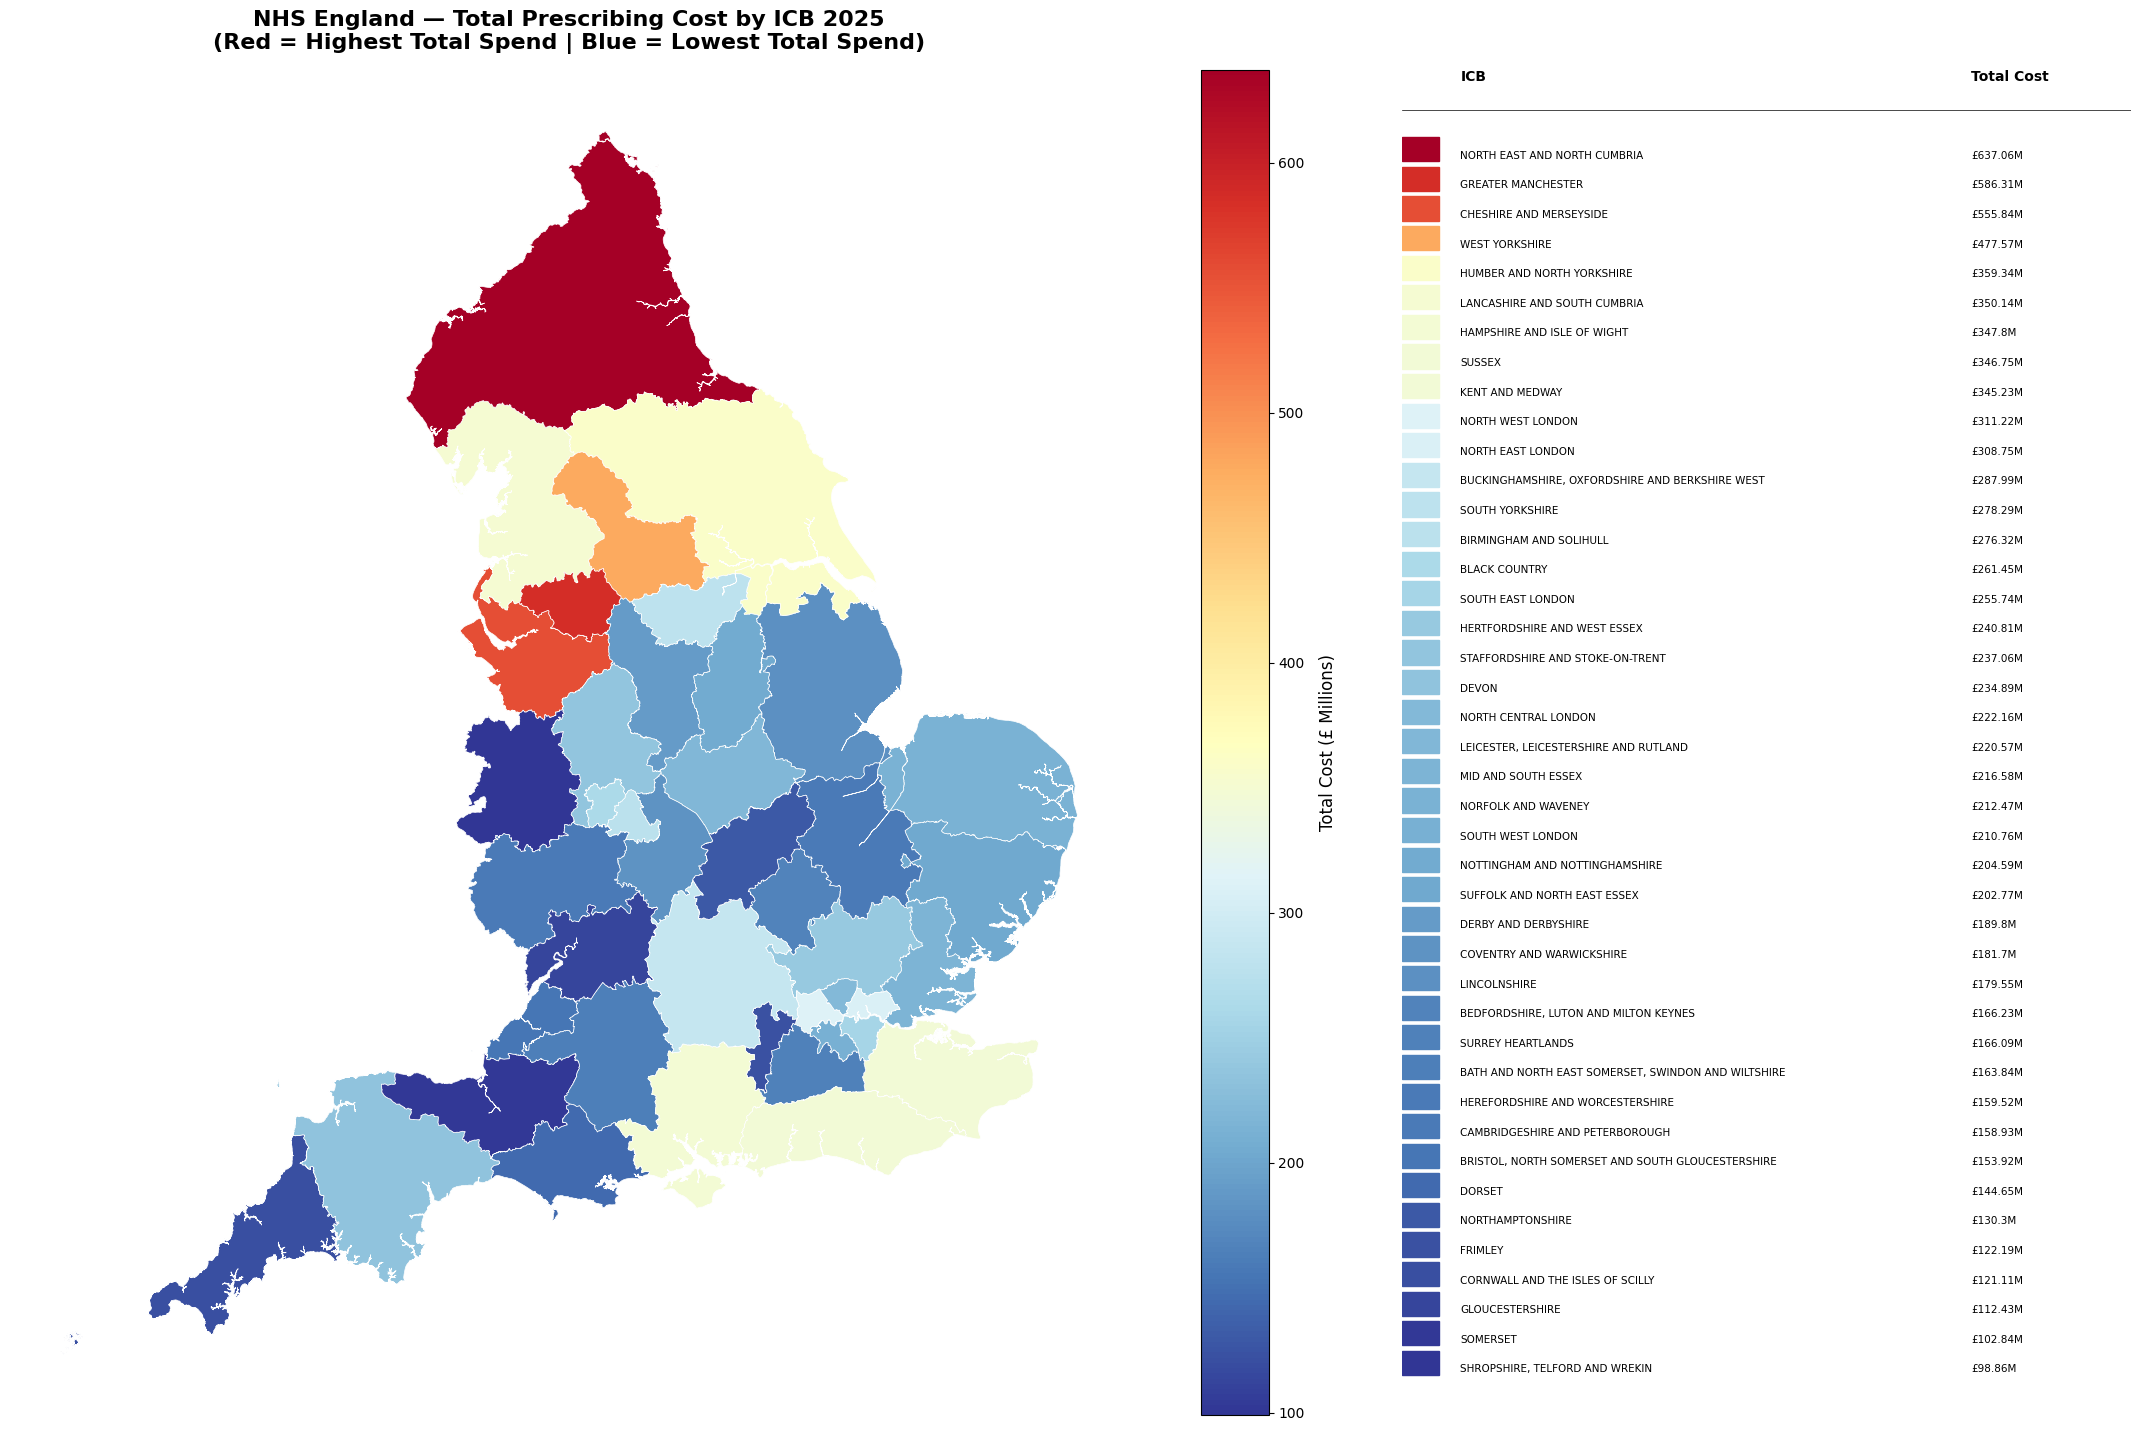

Map saved


In [87]:
# Get total cost per ICB
icb_total_cost = con.execute("""
    SELECT 
        ICB_NAME,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    GROUP BY ICB_NAME
    ORDER BY total_cost_millions DESC
""").df()

# Shorten names for legend
icb_total_cost['short_name'] = icb_total_cost['ICB_NAME'].str.replace('INTEGRATED CARE BOARD', '').str.replace('NHS ', '').str.strip()

# Merge with boundary file
icb_map['ICB23NM_UPPER'] = icb_map['ICB23NM'].str.upper()
icb_map_cost = icb_map.merge(
    icb_total_cost,
    left_on='ICB23NM_UPPER',
    right_on='ICB_NAME',
    how='left'
)

fig = plt.figure(figsize=(22, 14))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1])

ax_map = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

# Define colormap and normalizer
vmin = icb_total_cost['total_cost_millions'].min()
vmax = icb_total_cost['total_cost_millions'].max()
cmap = cm.RdYlBu_r
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
# This maps each ICB value to its exact color on the coolwarm scale

# Plot map
icb_map_cost.plot(
    column='total_cost_millions',
    cmap='RdYlBu_r',
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Total Cost (£ Millions)', 'orientation': 'vertical'},
    ax=ax_map,
    vmin=vmin,
    vmax=vmax
)

ax_map.get_figure().axes[-1].yaxis.label.set_size(12)
ax_map.get_figure().axes[-1].yaxis.labelpad = 10

ax_map.set_title('NHS England — Total Prescribing Cost by ICB 2025\n(Red = Highest Total Spend | Blue = Lowest Total Spend)', fontsize=16, fontweight='bold', pad=15)
ax_map.axis('off')

# Legend table on right
ax_legend.axis('off')

# Headings
ax_legend.text(0.08, 1.0, 'ICB', fontsize=10, fontweight='bold', transform=ax_legend.transAxes, va='top')
ax_legend.text(0.78, 1.0, 'Total Cost', fontsize=10, fontweight='bold', transform=ax_legend.transAxes, va='top')
ax_legend.plot([0, 1], [0.97, 0.97], color='black', linewidth=0.5, transform=ax_legend.transAxes)

# Rows with color squares
for idx, (_, row) in enumerate(icb_total_cost.iterrows()):
    y_pos = 0.94 - idx * 0.022

    # Get exact color for this ICB value
    color = cmap(norm(row['total_cost_millions']))

    # Draw color square
    ax_legend.add_patch(plt.Rectangle(
        (0.0, y_pos - 0.008), 0.05, 0.018,
        color=color,
        transform=ax_legend.transAxes
    ))

    # ICB name
    ax_legend.text(0.08, y_pos, row['short_name'], fontsize=7.5, transform=ax_legend.transAxes, va='top')

    # Total cost value
    ax_legend.text(0.78, y_pos, f"£{row['total_cost_millions']}M", fontsize=7.5, transform=ax_legend.transAxes, va='top')

plt.tight_layout()
plt.savefig('chapter2_icb_total_cost_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Map saved")

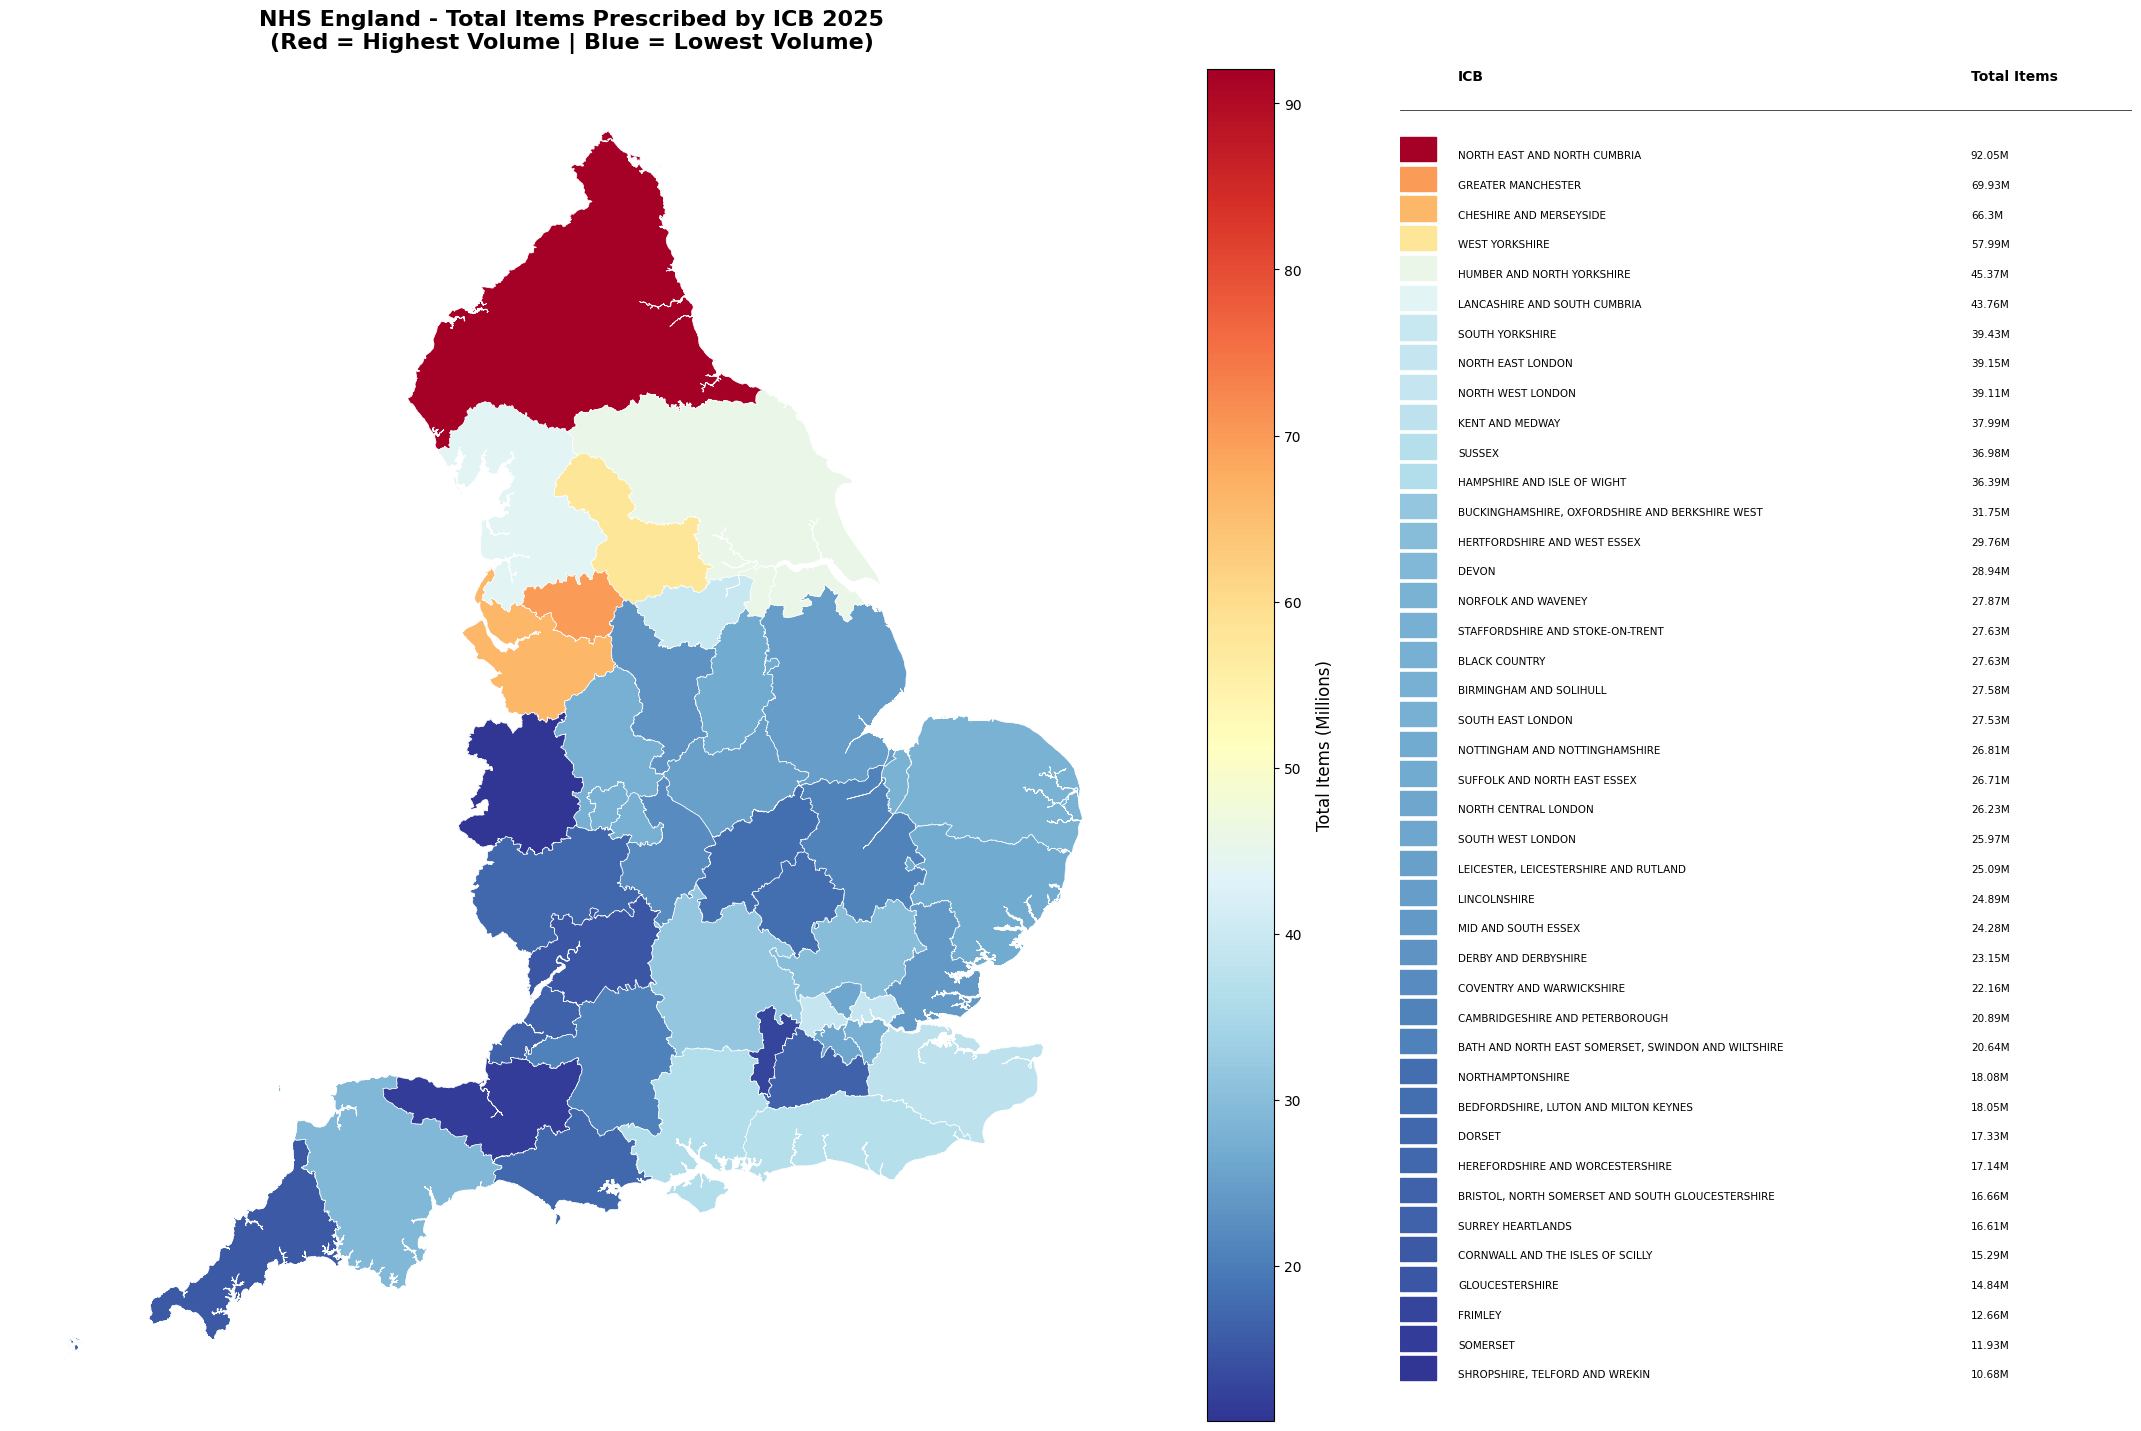

Map saved


In [88]:
# Get total items per ICB
icb_volume = con.execute("""
    SELECT 
        ICB_NAME,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    GROUP BY ICB_NAME
    ORDER BY total_items_millions DESC
""").df()

icb_volume['short_name'] = icb_volume['ICB_NAME'].str.replace('INTEGRATED CARE BOARD', '').str.replace('NHS ', '').str.strip()

# Merge with boundary file
icb_map_volume = icb_map.merge(
    icb_volume,
    left_on='ICB23NM_UPPER',
    right_on='ICB_NAME',
    how='left'
)

# Define colormap and normalizer
vmin_v = icb_volume['total_items_millions'].min()
vmax_v = icb_volume['total_items_millions'].max()
cmap = cm.RdYlBu_r
norm_v = mcolors.Normalize(vmin=vmin_v, vmax=vmax_v)

fig = plt.figure(figsize=(22, 14))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1])

ax_map = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

# Plot map
icb_map_volume.plot(
    column='total_items_millions',
    cmap='RdYlBu_r',
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Total Items (Millions)', 'orientation': 'vertical'},
    ax=ax_map,
    vmin=vmin_v,
    vmax=vmax_v
)

ax_map.get_figure().axes[-1].yaxis.label.set_size(12)
ax_map.get_figure().axes[-1].yaxis.labelpad = 10

ax_map.set_title('NHS England - Total Items Prescribed by ICB 2025\n(Red = Highest Volume | Blue = Lowest Volume)', fontsize=16, fontweight='bold', pad=15)
ax_map.axis('off')

# Legend table
ax_legend.axis('off')
ax_legend.text(0.08, 1.0, 'ICB', fontsize=10, fontweight='bold', transform=ax_legend.transAxes, va='top')
ax_legend.text(0.78, 1.0, 'Total Items', fontsize=10, fontweight='bold', transform=ax_legend.transAxes, va='top')
ax_legend.plot([0, 1], [0.97, 0.97], color='black', linewidth=0.5, transform=ax_legend.transAxes)

for idx, (_, row) in enumerate(icb_volume.iterrows()):
    y_pos = 0.94 - idx * 0.022
    color = cmap(norm_v(row['total_items_millions']))

    ax_legend.add_patch(plt.Rectangle(
        (0.0, y_pos - 0.008), 0.05, 0.018,
        color=color,
        transform=ax_legend.transAxes
    ))

    ax_legend.text(0.08, y_pos, row['short_name'], fontsize=7.5, transform=ax_legend.transAxes, va='top')
    ax_legend.text(0.78, y_pos, f"{row['total_items_millions']}M", fontsize=7.5, transform=ax_legend.transAxes, va='top')

plt.tight_layout()
plt.savefig('chapter2_icb_volume_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Map saved")

In [89]:
# Get December and February avg cost per prescription per ICB
dec_feb_data = con.execute("""
    SELECT 
        ICB_NAME,
        MONTH,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE MONTH IN (2, 12)
    GROUP BY ICB_NAME, MONTH
    ORDER BY ICB_NAME, MONTH
""").df()

# Split into December and February
feb_data = dec_feb_data[dec_feb_data['MONTH'] == 2][['ICB_NAME', 'avg_cost_per_prescription']].rename(columns={'avg_cost_per_prescription': 'feb_cost'})
dec_data = dec_feb_data[dec_feb_data['MONTH'] == 12][['ICB_NAME', 'avg_cost_per_prescription']].rename(columns={'avg_cost_per_prescription': 'dec_cost'})

print("February data:")
print(feb_data.head())
print("\nDecember data:")
print(dec_data.head())

February data:
                                            ICB_NAME  feb_cost
0  NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...     18.38
2  NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...     19.74
4  NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD     20.12
6            NHS BLACK COUNTRY INTEGRATED CARE BOARD     19.78
8  NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST...     19.63

December data:
                                            ICB_NAME  dec_cost
1  NHS BATH AND NORTH EAST SOMERSET, SWINDON AND ...     19.80
3  NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...     20.64
5  NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD     21.90
7            NHS BLACK COUNTRY INTEGRATED CARE BOARD     21.16
9  NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST...     21.24


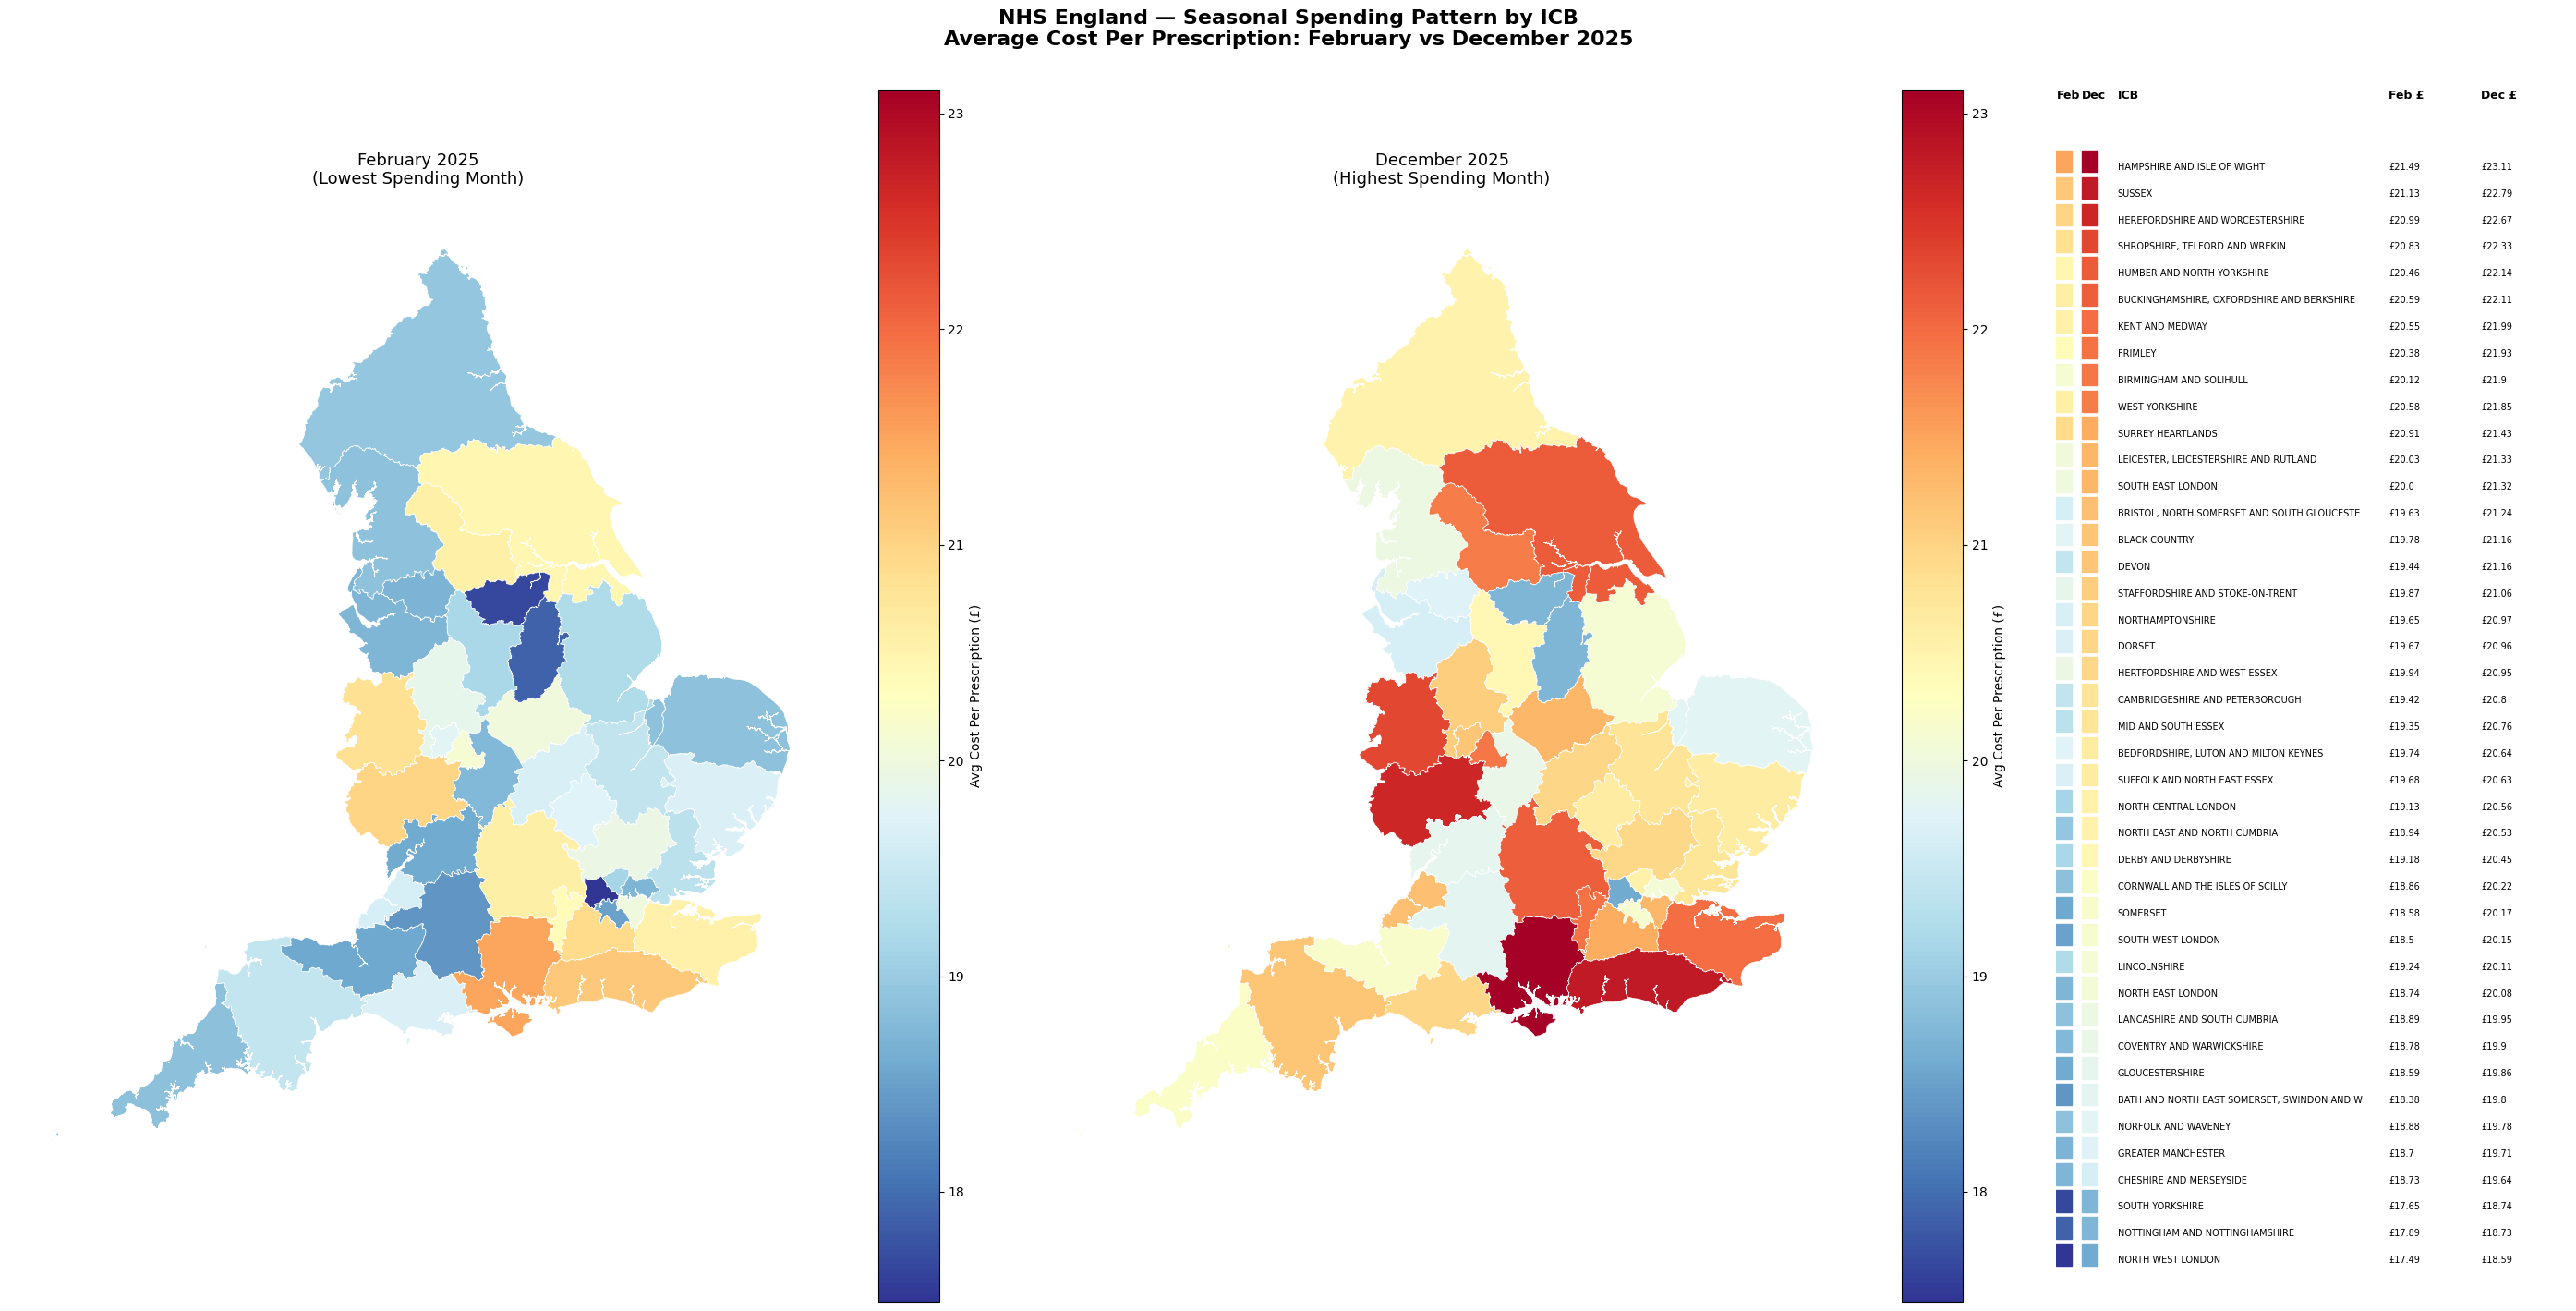

Map saved


In [90]:
# Merge with boundary file
icb_map['ICB23NM_UPPER'] = icb_map['ICB23NM'].str.upper()

icb_map_feb = icb_map.merge(feb_data, left_on='ICB23NM_UPPER', right_on='ICB_NAME', how='left')
icb_map_dec = icb_map.merge(dec_data, left_on='ICB23NM_UPPER', right_on='ICB_NAME', how='left')

# Merge feb and dec data for legend
legend_data = feb_data.merge(dec_data, on='ICB_NAME', how='left')
legend_data['short_name'] = legend_data['ICB_NAME'].str.replace('INTEGRATED CARE BOARD', '').str.replace('NHS ', '').str.strip()
legend_data['short_name'] = legend_data['short_name'].str[:43]
legend_data = legend_data.sort_values('dec_cost', ascending=False)

# Same scale for both maps
vmin_s = dec_feb_data['avg_cost_per_prescription'].min()
vmax_s = dec_feb_data['avg_cost_per_prescription'].max()
cmap = cm.RdYlBu_r
norm_s = mcolors.Normalize(vmin=vmin_s, vmax=vmax_s)

fig = plt.figure(figsize=(28, 14))
gs = gridspec.GridSpec(1, 3, width_ratios=[2, 2, 1])

ax_feb = fig.add_subplot(gs[0])
ax_dec = fig.add_subplot(gs[1])
ax_legend = fig.add_subplot(gs[2])

# February map
icb_map_feb.plot(
    column='feb_cost',
    cmap='RdYlBu_r',
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Avg Cost Per Prescription (£)', 'orientation': 'vertical'},
    ax=ax_feb,
    vmin=vmin_s,
    vmax=vmax_s
)

ax_map.get_figure().axes[-1].yaxis.label.set_size(12)
ax_map.get_figure().axes[-1].yaxis.labelpad = 10

ax_feb.set_title('February 2025\n(Lowest Spending Month)', fontsize=13, pad=15)
ax_feb.get_figure().axes[1].yaxis.label.set_size(20)
ax_feb.axis('off')

# December map
icb_map_dec.plot(
    column='dec_cost',
    cmap='RdYlBu_r',
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Avg Cost Per Prescription (£)', 'orientation': 'vertical'},
    ax=ax_dec,
    vmin=vmin_s,
    vmax=vmax_s
)

ax_map.get_figure().axes[-1].yaxis.label.set_size(12)
ax_map.get_figure().axes[-1].yaxis.labelpad = 10

ax_dec.set_title('December 2025\n(Highest Spending Month)', fontsize=13, pad=15)
ax_feb.get_figure().axes[1].yaxis.label.set_size(20)
ax_dec.axis('off')

# Legend table
ax_legend.axis('off')

# Headings
ax_legend.text(0.0, 1.0, 'Feb', fontsize=9, fontweight='bold', transform=ax_legend.transAxes, va='top')
ax_legend.text(0.05, 1.0, 'Dec', fontsize=9, fontweight='bold', transform=ax_legend.transAxes, va='top')
ax_legend.text(0.12, 1.0, 'ICB', fontsize=9, fontweight='bold', transform=ax_legend.transAxes, va='top')
ax_legend.text(0.65, 1.0, 'Feb £', fontsize=9, fontweight='bold', transform=ax_legend.transAxes, va='top')
ax_legend.text(0.83, 1.0, 'Dec £', fontsize=9, fontweight='bold', transform=ax_legend.transAxes, va='top')
ax_legend.plot([0, 1], [0.97, 0.97], color='black', linewidth=0.5, transform=ax_legend.transAxes)

for idx, (_, row) in enumerate(legend_data.iterrows()):
    y_pos = 0.94 - idx * 0.022

    # Feb color square
    feb_color = cmap(norm_s(row['feb_cost']))
    ax_legend.add_patch(plt.Rectangle(
        (0.0, y_pos - 0.008), 0.03, 0.018,
        color=feb_color,
        transform=ax_legend.transAxes
    ))

    # Dec color square
    dec_color = cmap(norm_s(row['dec_cost']))
    ax_legend.add_patch(plt.Rectangle(
        (0.05, y_pos - 0.008), 0.03, 0.018,
        color=dec_color,
        transform=ax_legend.transAxes
    ))

    # ICB name
    ax_legend.text(0.12, y_pos, row['short_name'], fontsize=7, transform=ax_legend.transAxes, va='top')

    # Feb and Dec values
    ax_legend.text(0.65, y_pos, f"£{row['feb_cost']}", fontsize=7, transform=ax_legend.transAxes, va='top')
    ax_legend.text(0.83, y_pos, f"£{row['dec_cost']}", fontsize=7, transform=ax_legend.transAxes, va='top')

fig.suptitle('NHS England — Seasonal Spending Pattern by ICB\nAverage Cost Per Prescription: February vs December 2025',
             fontsize=16, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('chapter2_seasonal_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Map saved")

=========================================================================================================================================================

10. Chapter 3

In [91]:
practice_count = con.execute("""
    SELECT COUNT(DISTINCT PRACTICE_CODE) AS total_practices
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
""").df()

print(practice_count)

   total_practices
0            10013


In [92]:
# Step 1: Average cost per prescription per practice
practice_avg = con.execute("""
    SELECT 
        PRACTICE_CODE,
        PRACTICE_NAME,
        ICB_NAME,
        REGIONAL_OFFICE,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions,
        COUNT(DISTINCT MONTH) AS months_active
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    GROUP BY PRACTICE_CODE, PRACTICE_NAME, ICB_NAME, REGIONAL_OFFICE
""").df()

print(f"Total practices: {len(practice_avg)}")
print(practice_avg.head())

Total practices: 10123
  PRACTICE_CODE                    PRACTICE_NAME  \
0        G82119                     PARK SURGERY   
1        F84031  THE JUBILEE STREET PRACTICE LTD   
2        C84014       WOODLANDS MEDICAL PRACTICE   
3        L84047               CHURCHDOWN SURGERY   
4        L83035          LITCHDON MEDICAL CENTRE   

                                            ICB_NAME REGIONAL_OFFICE  \
0          NHS KENT AND MEDWAY INTEGRATED CARE BOARD      SOUTH EAST   
1        NHS NORTH EAST LONDON INTEGRATED CARE BOARD          LONDON   
2  NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEGRATED ...        MIDLANDS   
3          NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD      SOUTH WEST   
4                    NHS DEVON INTEGRATED CARE BOARD      SOUTH WEST   

   avg_cost_per_prescription  total_cost_millions  total_items_millions  \
0                      27.47                 5.45                  0.55   
1                      22.43                 2.67                  0.42   
2     

In [93]:
# Check how many practices are active all 12 months vs partial year
active_check = con.execute("""
    SELECT 
        months_active,
        COUNT(*) AS practice_count
    FROM (
        SELECT 
            PRACTICE_CODE,
            COUNT(DISTINCT MONTH) AS months_active
        FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
        GROUP BY PRACTICE_CODE
    )
    GROUP BY months_active
    ORDER BY months_active DESC
""").df()

print(active_check)

    months_active  practice_count
0              12            8374
1              11             181
2              10             157
3               9             129
4               8              97
5               7              95
6               6             117
7               5              89
8               4             138
9               3             122
10              2             173
11              1             341


In [94]:
# Step 2: Filter to only practices active all 12 months and calculate expected cost
# Expected cost = the ICB average — what a practice "should" be spending
practice_residuals = con.execute("""
    WITH stable_practices AS (
        SELECT PRACTICE_CODE
        FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
        GROUP BY PRACTICE_CODE
        HAVING COUNT(DISTINCT MONTH) = 12
    ),
    -- Step 1: Get only practices active all 12 months
    
    practice_monthly AS (
        SELECT 
            d.PRACTICE_CODE,
            d.PRACTICE_NAME,
            d.ICB_NAME,
            d.REGIONAL_OFFICE,
            d.MONTH,
            ROUND(AVG(d.COST_PER_ITEM), 2) AS practice_avg
        FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet') d
        JOIN stable_practices s ON d.PRACTICE_CODE = s.PRACTICE_CODE
        GROUP BY d.PRACTICE_CODE, d.PRACTICE_NAME, d.ICB_NAME, d.REGIONAL_OFFICE, d.MONTH
    ),
    -- Step 2: Get each practice's average cost per prescription per month
    
    icb_monthly AS (
        SELECT 
            ICB_NAME,
            MONTH,
            ROUND(AVG(COST_PER_ITEM), 2) AS icb_avg
        FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
        GROUP BY ICB_NAME, MONTH
    )
    -- Step 3: Get the ICB average per month — this is the "expected" cost
    
    SELECT 
        p.PRACTICE_CODE,
        p.PRACTICE_NAME,
        p.ICB_NAME,
        p.REGIONAL_OFFICE,
        p.MONTH,
        p.practice_avg,
        i.icb_avg AS expected_cost,
        ROUND(p.practice_avg - i.icb_avg, 2) AS residual
    FROM practice_monthly p
    JOIN icb_monthly i ON p.ICB_NAME = i.ICB_NAME AND p.MONTH = i.MONTH
    -- Step 4: Calculate residual = practice cost minus what's expected for their ICB
""").df()

print(f"Total rows: {len(practice_residuals)}")
print(practice_residuals.head())

Total rows: 100488
  PRACTICE_CODE                   PRACTICE_NAME  \
0        Y08573                      HASTINGSSH   
1        F81623  KADIM PRIMECARE MEDICAL CENTRE   
2        Y02307                     HMP BRISTOL   
3        Y04667        PCOC GYNAECOLOGY SERVICE   
4        N81010          NANTWICH HEALTH CENTRE   

                                            ICB_NAME  REGIONAL_OFFICE  MONTH  \
0          NHS KENT AND MEDWAY INTEGRATED CARE BOARD       SOUTH EAST      1   
1      NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD  EAST OF ENGLAND      1   
2  NHS BRISTOL, NORTH SOMERSET AND SOUTH GLOUCEST...       SOUTH WEST      1   
3  NHS BEDFORDSHIRE, LUTON AND MILTON KEYNES INTE...  EAST OF ENGLAND      1   
4  NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD       NORTH WEST      2   

   practice_avg  expected_cost  residual  
0         12.60          20.84     -8.24  
1         13.70          19.71     -6.01  
2          1.52          20.03    -18.51  
3          3.44      

In [95]:
# Step 3: Average residual per practice across all 12 months
practice_outliers = con.execute("""
    SELECT 
        PRACTICE_CODE,
        PRACTICE_NAME,
        ICB_NAME,
        REGIONAL_OFFICE,
        ROUND(AVG(residual), 2) AS avg_residual,
        ROUND(AVG(practice_avg), 2) AS avg_practice_cost,
        ROUND(AVG(expected_cost), 2) AS avg_expected_cost
    FROM practice_residuals
    GROUP BY PRACTICE_CODE, PRACTICE_NAME, ICB_NAME, REGIONAL_OFFICE
    ORDER BY avg_residual DESC
""").df()

print(f"Total practices analysed: {len(practice_outliers)}")
print("\n--- Top 10 Overspenders ---")
print(practice_outliers.head(10))
print("\n--- Top 10 Underspenders ---")
print(practice_outliers.tail(10))

Total practices analysed: 8479

--- Top 10 Overspenders ---
  PRACTICE_CODE                           PRACTICE_NAME  \
0        Y02914       NCL COVID MEDICINES DELIVERY UNIT   
1        Y07977            LLR REFERRAL SUPPORT SERVICE   
2        Y08445                                MSE CMDU   
3        Y03527        CHILD DEVELOPMENT CENTRE IPSWICH   
4        Y05384                             PATHFINDERS   
5        Y04816            BANES BLADDER AND BOWEL TEAM   
6        Y04507                     THE CHILDRENS TRUST   
7        Y06769  SOUTH CENTRAL AMBULANCE SERVICE - CCAS   
8        Y00945            COMMUNITY PAEDIATRIC SERVICE   
9        Y06508   CARMELITA HOUSE - PAEDIATRIC SERVICES   

                                            ICB_NAME  REGIONAL_OFFICE  \
0     NHS NORTH CENTRAL LONDON INTEGRATED CARE BOARD           LONDON   
1  NHS LEICESTER, LEICESTERSHIRE AND RUTLAND INTE...         MIDLANDS   
2      NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD  EAST OF ENGLAND  

In [96]:
# Check if the Y prefix pattern holds for all specialist services
y_practices_check = con.execute("""
    SELECT 
        SUBSTR(PRACTICE_CODE, 1, 1) AS first_letter,
        COUNT(DISTINCT PRACTICE_CODE) AS practice_count
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    GROUP BY first_letter
    ORDER BY practice_count DESC
""").df()

print(y_practices_check)

   first_letter  practice_count
0             Y            3988
1             M             706
2             C             593
3             F             555
4             P             543
5             E             522
6             G             443
7             B             424
8             L             381
9             A             369
10            H             351
11            N             348
12            K             279
13            J             275
14            D             233
15            0               2
16            R               1


In [97]:
# Check the names of Y-prefix practices to see what they actually are
y_practice_names = con.execute("""
    SELECT 
        PRACTICE_CODE,
        PRACTICE_NAME
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE PRACTICE_CODE LIKE 'Y%'
    GROUP BY PRACTICE_CODE, PRACTICE_NAME
    LIMIT 30
""").df()

print(y_practice_names)

   PRACTICE_CODE                             PRACTICE_NAME
0         Y03730                           WEST KENT GROUP
1         Y07888       MID HAMPSHIRE COMMUNITY DERMATOLOGY
2         Y05991                          VIA REDBRIDGE R3
3         Y01003                                  BURY OOH
4         Y07103                 APCOS TENTERDEN OPTICIANS
5         Y07959     HERTS FRAILTY HOSPITAL AT HOME - CLCH
6         Y05376                WE ARE WITH YOU SHROPSHIRE
7         Y04981     HERTFORDSHIRE COMMUNITY SEXUAL HEALTH
8         Y05716      COMMUNITY ANTICOAG SERVICE LIVERPOOL
9         Y00265                     CHAPEL MEDICAL CENTRE
10        Y06961  NORTH EAST LINCOLNSHIRE VOCARENHS111 OOH
11        Y07459               EAST END HEALTH NETWORK PCN
12        Y07939                         PSYCHIATRY UK-LLP
13        Y08484               YORK DRUG & ALCOHOL SERVICE
14        Y06841     DONCASTER CHILDRENS 0-19YRS COMM.SERV
15        Y06846    DONCASTER COMM CHILD SPECIALIST NURS

In [98]:
# Load the NHS GP practice list
gp_list = pd.read_csv("D:/UEA/Business Analytics/P1/Code_Dataset/epraccur.csv", header=None)
# header=None because epraccur has no column headers

print(gp_list.shape)
print(gp_list.head())

(15523, 27)
       0                           1    2    3               4   \
0  A81001         THE DENSHAM SURGERY  Y63  QHM   HEALTH CENTRE   
1  A81002  QUEENS PARK MEDICAL CENTRE  Y63  QHM   FARRER STREET   
2  A81003   VICTORIA MEDICAL PRACTICE  Y63  QHM   HEALTH CENTRE   
3  A81004       ACKLAM MEDICAL CENTRE  Y63  QHM  TRIMDON AVENUE   
4  A81005          SPRINGWOOD SURGERY  Y63  QHM    RECTORY LANE   

              5    6                 7   8         9   ...            17  18  \
0  LAWSON STREET  NaN  STOCKTON-ON-TEES NaN  TS18 1HU  ...  01642 672351 NaN   
1            NaN  NaN  STOCKTON ON TEES NaN  TS18 2AW  ...  01642 618170 NaN   
2  VICTORIA ROAD  NaN        HARTLEPOOL NaN  TS26 8DB  ...  01429 272945 NaN   
3         ACKLAM  NaN     MIDDLESBROUGH NaN   TS5 8SB  ...  01642 827697 NaN   
4            NaN  NaN       GUISBOROUGH NaN  TS14 7DJ  ...  01287 619611 NaN   

   19  20 21  22   23  24    25  26  
0 NaN NaN  1 NaN  16C NaN  RO76 NaN  
1 NaN NaN  1 NaN  16C NaN  R

Verified with our dataset that 0 and 1 are PRACTICE_CODE and PRACTICE_NAME

In [99]:
# Check if A81001 exists in our dataset
check = con.execute("""
    SELECT DISTINCT PRACTICE_CODE, PRACTICE_NAME
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE PRACTICE_CODE = 'A81001'
""").df()

print(check)

  PRACTICE_CODE        PRACTICE_NAME
0        A81001  THE DENSHAM SURGERY


In [100]:
# Keep only practice code and name, add proper headers
gp_list = gp_list[[0, 1]].copy()
gp_list.columns = ['PRACTICE_CODE', 'PRACTICE_NAME']
# Only keep the two columns we need

print(f"Total GP practices in NHS list: {len(gp_list)}")
print(gp_list.head())

Total GP practices in NHS list: 15523
  PRACTICE_CODE               PRACTICE_NAME
0        A81001         THE DENSHAM SURGERY
1        A81002  QUEENS PARK MEDICAL CENTRE
2        A81003   VICTORIA MEDICAL PRACTICE
3        A81004       ACKLAM MEDICAL CENTRE
4        A81005          SPRINGWOOD SURGERY


In [101]:
# Filter to only real GP practices
real_gp_outliers = practice_outliers[practice_outliers['PRACTICE_CODE'].isin(gp_list['PRACTICE_CODE'])]
# Keeps only practices that appear in the official NHS GP list

print(f"Total practices before filter: {len(practice_outliers)}")
print(f"Real GP practices after filter: {len(real_gp_outliers)}")

Total practices before filter: 8479
Real GP practices after filter: 8479


In [102]:
# Check if the top overspenders are in the NHS GP list
top_overspenders = practice_outliers.head(10)['PRACTICE_CODE'].tolist()

check = gp_list[gp_list['PRACTICE_CODE'].isin(top_overspenders)]
print(check)

      PRACTICE_CODE                           PRACTICE_NAME
8853         Y00945            COMMUNITY PAEDIATRIC SERVICE
9719         Y02914       NCL COVID MEDICINES DELIVERY UNIT
10147        Y03527        CHILD DEVELOPMENT CENTRE IPSWICH
11006        Y04507                     THE CHILDRENS TRUST
11300        Y04816            BANES BLADDER AND BOWEL TEAM
11845        Y05384                             PATHFINDERS
12966        Y06508   CARMELITA HOUSE - PAEDIATRIC SERVICES
13198        Y06769  SOUTH CENTRAL AMBULANCE SERVICE - CCAS
14398        Y07977            LLR REFERRAL SUPPORT SERVICE
14865        Y08445                                MSE CMDU


In [103]:
# Check all columns in the epraccur file to find status codes
gp_list_full = pd.read_csv("D:/UEA/Business Analytics/P1/Code_Dataset/epraccur.csv", header=None)

# Check column 12 which typically contains status code in epraccur
print(gp_list_full[[0, 1, 12]].head(20))
print("\nUnique values in column 12:")
print(gp_list_full[12].value_counts())

        0                                1         12
0   A81001              THE DENSHAM SURGERY    ACTIVE
1   A81002       QUEENS PARK MEDICAL CENTRE    ACTIVE
2   A81003        VICTORIA MEDICAL PRACTICE  INACTIVE
3   A81004            ACKLAM MEDICAL CENTRE    ACTIVE
4   A81005               SPRINGWOOD SURGERY    ACTIVE
5   A81006  TENNANT STREET MEDICAL PRACTICE    ACTIVE
6   A81007                BANKHOUSE SURGERY    ACTIVE
7   A81008              ALBERT HOUSE CLINIC  INACTIVE
8   A81009           VILLAGE MEDICAL CENTRE    ACTIVE
9   A81011                CHADWICK PRACTICE    ACTIVE
10  A81012        WESTBOURNE MEDICAL CENTRE    ACTIVE
11  A81013                  BROTTON SURGERY    ACTIVE
12  A81014              QUEENSTREE PRACTICE    ACTIVE
13  A81015                    LAGAN SURGERY  INACTIVE
14  A81016                     PARK SURGERY    ACTIVE
15  A81017              WOODBRIDGE PRACTICE    ACTIVE
16  A81018         BENTLEY MEDICAL PRACTICE    ACTIVE
17  A81019          CROSSFEL

In [104]:
# Check column 25 for prescriber type
print(gp_list_full[[0, 1, 12, 25]].head(20))
print("\nUnique values in column 25:")
print(gp_list_full[25].value_counts())

        0                                1         12    25
0   A81001              THE DENSHAM SURGERY    ACTIVE  RO76
1   A81002       QUEENS PARK MEDICAL CENTRE    ACTIVE  RO76
2   A81003        VICTORIA MEDICAL PRACTICE  INACTIVE  RO76
3   A81004            ACKLAM MEDICAL CENTRE    ACTIVE  RO76
4   A81005               SPRINGWOOD SURGERY    ACTIVE  RO76
5   A81006  TENNANT STREET MEDICAL PRACTICE    ACTIVE  RO76
6   A81007                BANKHOUSE SURGERY    ACTIVE  RO76
7   A81008              ALBERT HOUSE CLINIC  INACTIVE  RO76
8   A81009           VILLAGE MEDICAL CENTRE    ACTIVE  RO76
9   A81011                CHADWICK PRACTICE    ACTIVE  RO76
10  A81012        WESTBOURNE MEDICAL CENTRE    ACTIVE  RO76
11  A81013                  BROTTON SURGERY    ACTIVE  RO76
12  A81014              QUEENSTREE PRACTICE    ACTIVE  RO76
13  A81015                    LAGAN SURGERY  INACTIVE  RO76
14  A81016                     PARK SURGERY    ACTIVE  RO76
15  A81017              WOODBRIDGE PRACT

In [105]:
# Check what code the specialist services have
specialist_check = gp_list_full[gp_list_full[0].isin(['Y02914', 'Y07977', 'Y08445', 'Y03527', 'Y05384'])][[0, 1, 12, 25]]
print(specialist_check)

           0                                  1       12     25
9719   Y02914  NCL COVID MEDICINES DELIVERY UNIT  ACTIVE   RO76
10147  Y03527   CHILD DEVELOPMENT CENTRE IPSWICH  ACTIVE  RO247
11845  Y05384                        PATHFINDERS  ACTIVE  RO246
14398  Y07977       LLR REFERRAL SUPPORT SERVICE  ACTIVE  RO247
14865  Y08445                           MSE CMDU  ACTIVE   RO72


In [106]:
# Identify real GP practices using behaviour filter
real_gp_codes = con.execute("""
    SELECT PRACTICE_CODE
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    GROUP BY PRACTICE_CODE
    HAVING COUNT(DISTINCT BNF_CHAPTER_CODE) >= 15
    -- Prescribes across at least 15 of 21 drug categories
    AND SUM(ITEMS) >= 10000
    -- At least 10,000 total items in the year
    AND COUNT(DISTINCT MONTH) = 12
    -- Active all 12 months
""").df()

print(f"Real GP practices identified: {len(real_gp_codes)}")

Real GP practices identified: 6498


In [107]:
# Filter practice_outliers to only real GP practices
real_gp_outliers = practice_outliers[practice_outliers['PRACTICE_CODE'].isin(real_gp_codes['PRACTICE_CODE'])]

print(f"Total practices before filter: {len(practice_outliers)}")
print(f"Real GP practices after filter: {len(real_gp_outliers)}")

print("\n--- Top 10 Overspenders ---")
print(real_gp_outliers.head(10)[['PRACTICE_CODE', 'PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE', 'avg_residual', 'avg_practice_cost', 'avg_expected_cost']])

print("\n--- Top 10 Underspenders ---")
print(real_gp_outliers.tail(10)[['PRACTICE_CODE', 'PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE', 'avg_residual', 'avg_practice_cost', 'avg_expected_cost']])

Total practices before filter: 8479
Real GP practices after filter: 6567

--- Top 10 Overspenders ---
    PRACTICE_CODE                      PRACTICE_NAME  \
88         Y06934           WORCESTERSHIRE COMMUNITY   
105        Y03942          BCHC MEDICINES MANAGEMENT   
112        Y03979               WWL COMMUNITY NURSES   
137        Y05715  ST HELENS OUT OF HOSPITAL SERVICE   
144        Y03893     OLDHAM CARE ORGANISATION - NMP   
147        Y08168            CHCP COMMUNITY SERVICES   
148        Y03884         ENFIELD COMMUNITY SERVICES   
152        Y06581    SFHT COMMUNITY PAEDS PRESCRIBER   
164        Y04107            WEST LONDON TRUST (NMP)   
181        Y03870               NHS FYLDE & WYRE CCG   

                                              ICB_NAME  \
88   NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...   
105  NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD   
112       NHS GREATER MANCHESTER INTEGRATED CARE BOARD   
137  NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE 

In [108]:
# Increase thresholds to be stricter
real_gp_codes = con.execute("""
    SELECT PRACTICE_CODE
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    GROUP BY PRACTICE_CODE
    HAVING COUNT(DISTINCT BNF_CHAPTER_CODE) >= 18
    -- Increased from 15 to 18 categories
    AND SUM(ITEMS) >= 50000
    -- Increased from 10,000 to 50,000 items
    AND COUNT(DISTINCT MONTH) = 12
""").df()

print(f"Real GP practices identified: {len(real_gp_codes)}")

Real GP practices identified: 5954


In [109]:
# Apply stricter filter to outlier analysis
real_gp_outliers = practice_outliers[practice_outliers['PRACTICE_CODE'].isin(real_gp_codes['PRACTICE_CODE'])]

print(f"Real GP practices after strict filter: {len(real_gp_outliers)}")

print("\n--- Top 10 Overspenders ---")
print(real_gp_outliers.head(10)[['PRACTICE_CODE', 'PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE', 'avg_residual', 'avg_practice_cost', 'avg_expected_cost']])

print("\n--- Top 10 Underspenders ---")
print(real_gp_outliers.tail(10)[['PRACTICE_CODE', 'PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE', 'avg_residual', 'avg_practice_cost', 'avg_expected_cost']])

Real GP practices after strict filter: 6018

--- Top 10 Overspenders ---
    PRACTICE_CODE                            PRACTICE_NAME  \
105        Y03942                BCHC MEDICINES MANAGEMENT   
207        Y03894  PRIMARY CARE PRESCRIBING - STH EMPLOYED   
229        Y03811                   BLACKPOOL LOCALITY CHS   
274        Y03808                  BURY COMMUNITY SERVICES   
276        Y05106                     DISTRICT NURSES SWBH   
311        Y03831     NON MEDICAL PRESCRIBING SOUTHEND CCG   
348        Y03747                 WALSALL COMMUNITY NURSES   
362        B83033               MODALITY PARTNERSHIP (AWC)   
394        F85002                  MEDICUS HEALTH PARTNERS   
415        Y03881                               CCICP NMPS   

                                              ICB_NAME  \
105  NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD   
207          NHS SOUTH YORKSHIRE INTEGRATED CARE BOARD   
229  NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...   
274       NH

In [110]:
# Check what non-Y top overspenders look like
non_y_outliers = real_gp_outliers[~real_gp_outliers['PRACTICE_CODE'].str.startswith('Y')]

print(f"Non-Y practices: {len(non_y_outliers)}")
print("\n--- Top 10 Overspenders (Non-Y only) ---")
print(non_y_outliers.head(10)[['PRACTICE_CODE', 'PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE', 'avg_residual', 'avg_practice_cost', 'avg_expected_cost']])

print("\n--- Top 10 Underspenders (Non-Y only) ---")
print(non_y_outliers.tail(10)[['PRACTICE_CODE', 'PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE', 'avg_residual', 'avg_practice_cost', 'avg_expected_cost']])

Non-Y practices: 5764

--- Top 10 Overspenders (Non-Y only) ---
    PRACTICE_CODE                  PRACTICE_NAME  \
362        B83033     MODALITY PARTNERSHIP (AWC)   
394        F85002        MEDICUS HEALTH PARTNERS   
425        A84036     VALENS MEDICAL PARTNERSHIP   
428        M88616  GREAT BRIDGE PSHIP FOR HEALTH   
433        H82005       CUCKFIELD MEDICAL CENTRE   
437        F86007       THE FOREST EDGE PRACTICE   
442        H81615  FARNHAM DENE MEDICAL PRACTICE   
445        A82016            CARLISLE HEALTHCARE   
450        L83100           BEACON MEDICAL GROUP   
451        C82038  LATHAM HOUSE MEDICAL PRACTICE   

                                              ICB_NAME  \
362           NHS WEST YORKSHIRE INTEGRATED CARE BOARD   
394     NHS NORTH CENTRAL LONDON INTEGRATED CARE BOARD   
425  NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...   
428            NHS BLACK COUNTRY INTEGRATED CARE BOARD   
433                   NHS SUSSEX INTEGRATED CARE BOARD   
437        NHS 

In [111]:
# Filter 1: Already done in practice_outliers — only practices active 12 months
# Filter 2: Remove Y prefix codes
final_gp_outliers = practice_outliers[~practice_outliers['PRACTICE_CODE'].str.startswith('Y')]
# Removes all Y prefix practices from the outlier list

print(f"Total practices before filter: {len(practice_outliers)}")
print(f"Final GP practices after removing Y codes: {len(final_gp_outliers)}")

print("\n--- Top 10 Overspenders ---")
print(final_gp_outliers.head(10)[['PRACTICE_CODE', 'PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE', 'avg_residual', 'avg_practice_cost', 'avg_expected_cost']])

print("\n--- Top 10 Underspenders ---")
print(final_gp_outliers.tail(10)[['PRACTICE_CODE', 'PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE', 'avg_residual', 'avg_practice_cost', 'avg_expected_cost']])

Total practices before filter: 8479
Final GP practices after removing Y codes: 6014

--- Top 10 Overspenders ---
    PRACTICE_CODE                        PRACTICE_NAME  \
156        P84696             COMMUNITY PAEDIATRICIANS   
197        A89634             CONSULTANT - ST BENEDICT   
241        D82643  SPECIALIST PALLIATIVE CARE SERVICES   
306        P87664                  CHILDREN'S SERVICES   
362        B83033           MODALITY PARTNERSHIP (AWC)   
373        M83704            DOUGLAS MACMILLAN HOSPICE   
374        P81801                           C.A.M.H.S.   
394        F85002              MEDICUS HEALTH PARTNERS   
425        A84036           VALENS MEDICAL PARTNERSHIP   
428        M88616        GREAT BRIDGE PSHIP FOR HEALTH   

                                              ICB_NAME  \
156       NHS GREATER MANCHESTER INTEGRATED CARE BOARD   
197  NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...   
241      NHS NORFOLK AND WAVENEY INTEGRATED CARE BOARD   
306       NHS GR

In [112]:
# Combine all three filters
final_gp_outliers_clean = real_gp_outliers[~real_gp_outliers['PRACTICE_CODE'].str.startswith('Y')]
# Takes real_gp_outliers (Filter 1 + Filter 3) and applies Filter 2 (non-Y)

print(f"Final clean GP practices: {len(final_gp_outliers_clean)}")
print("\n--- Top 10 Overspenders ---")
print(final_gp_outliers_clean.head(10)[['PRACTICE_CODE', 'PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE', 'avg_residual']])

Final clean GP practices: 5764

--- Top 10 Overspenders ---
    PRACTICE_CODE                  PRACTICE_NAME  \
362        B83033     MODALITY PARTNERSHIP (AWC)   
394        F85002        MEDICUS HEALTH PARTNERS   
425        A84036     VALENS MEDICAL PARTNERSHIP   
428        M88616  GREAT BRIDGE PSHIP FOR HEALTH   
433        H82005       CUCKFIELD MEDICAL CENTRE   
437        F86007       THE FOREST EDGE PRACTICE   
442        H81615  FARNHAM DENE MEDICAL PRACTICE   
445        A82016            CARLISLE HEALTHCARE   
450        L83100           BEACON MEDICAL GROUP   
451        C82038  LATHAM HOUSE MEDICAL PRACTICE   

                                              ICB_NAME  \
362           NHS WEST YORKSHIRE INTEGRATED CARE BOARD   
394     NHS NORTH CENTRAL LONDON INTEGRATED CARE BOARD   
425  NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...   
428            NHS BLACK COUNTRY INTEGRATED CARE BOARD   
433                   NHS SUSSEX INTEGRATED CARE BOARD   
437        NHS NORT

In [113]:
print("--- Top 10 Underspenders ---")
print(final_gp_outliers_clean.tail(10)[['PRACTICE_CODE', 'PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE', 'avg_residual', 'avg_practice_cost', 'avg_expected_cost']])

--- Top 10 Underspenders ---
     PRACTICE_CODE                    PRACTICE_NAME  \
7322        J82036                WEST MEON SURGERY   
7327        J84008                     ARGYLL HOUSE   
7337        C84151   THE MEDICAL CENTRE - ZULU ROAD   
7348        J84016     SOUTH WIGHT MEDICAL PRACTICE   
7354        F84741         PLASHET HARMONY PRACTICE   
7372        M85082        HANDSWORTH MEDICAL PRACT.   
7429        B83657  BEVAN COMMUNITY BENEFIT SOCIETY   
7471        B86669      YORK STREET HEALTH PRACTICE   
7482        B81628          BARNETBY MEDICAL CENTRE   
7997        G81689                  ARCH HEALTHCARE   

                                               ICB_NAME  \
7322  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
7327  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
7337  NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEGRATED ...   
7348  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
7354        NHS NORTH EAST LONDON INTEGRATED CARE BOARD   
7372  NHS B

In [114]:
# Investigate ARCH HEALTHCARE
arch_check = con.execute("""
    SELECT 
        PRACTICE_CODE,
        PRACTICE_NAME,
        ICB_NAME,
        COUNT(DISTINCT BNF_CHAPTER_CODE) AS num_categories,
        SUM(ITEMS) AS total_items,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost,
        COUNT(DISTINCT MONTH) AS months_active
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE PRACTICE_CODE = 'G81689'
    GROUP BY PRACTICE_CODE, PRACTICE_NAME, ICB_NAME
""").df()

print(arch_check)

  PRACTICE_CODE    PRACTICE_NAME                          ICB_NAME  \
0        G81689  ARCH HEALTHCARE  NHS SUSSEX INTEGRATED CARE BOARD   

   num_categories  total_items  avg_cost  months_active  
0              20      90803.0      8.39             12  


In [115]:
# Step 5: Identify top 5% and bottom 5% outlier practices
total_practices = len(final_gp_outliers_clean)
top_5_percent = int(total_practices * 0.05)
# Calculates how many practices fall in the top 5%

print(f"Total practices: {total_practices}")
print(f"Top 5% threshold: {top_5_percent} practices")

# Top 5% overspenders
top_overspenders = final_gp_outliers_clean.head(top_5_percent)
print(f"\nTop 5% overspenders: {len(top_overspenders)} practices")
print(f"Residual range: £{top_overspenders['avg_residual'].min()} to £{top_overspenders['avg_residual'].max()}")

# Bottom 5% underspenders
bottom_underspenders = final_gp_outliers_clean.tail(top_5_percent)
print(f"\nBottom 5% underspenders: {len(bottom_underspenders)} practices")
print(f"Residual range: £{bottom_underspenders['avg_residual'].min()} to £{bottom_underspenders['avg_residual'].max()}")

Total practices: 5764
Top 5% threshold: 288 practices

Top 5% overspenders: 288 practices
Residual range: £3.98 to £14.56

Bottom 5% underspenders: 288 practices
Residual range: £-13.54 to £-5.36


In [116]:
# Step 6: Persistence check — do the same practices overspend month after month?
top_overspender_codes = top_overspenders['PRACTICE_CODE'].tolist()
# Gets the list of top 5% overspending practice codes

persistence_check = practice_residuals[practice_residuals['PRACTICE_CODE'].isin(top_overspender_codes)]
# Filters the monthly residuals for only the top 5% overspending practices

# Count how many months each practice has a positive residual
persistence_summary = persistence_check.groupby('PRACTICE_CODE').agg(
    months_overspending=('residual', lambda x: (x > 0).sum()),
    avg_residual=('residual', 'mean'),
    practice_name=('PRACTICE_NAME', 'first')
).reset_index()
# Counts how many of the 12 months each practice had a positive residual

persistence_summary = persistence_summary.sort_values('months_overspending', ascending=False)

print(persistence_summary['months_overspending'].value_counts().sort_index(ascending=False))
# Shows distribution of how many months practices overspend

months_overspending
12    281
11      3
Name: count, dtype: int64


In [117]:
# Persistence check for underspenders
bottom_underspender_codes = bottom_underspenders['PRACTICE_CODE'].tolist()

persistence_under = practice_residuals[practice_residuals['PRACTICE_CODE'].isin(bottom_underspender_codes)]

persistence_under_summary = persistence_under.groupby('PRACTICE_CODE').agg(
    months_underspending=('residual', lambda x: (x < 0).sum()),
    avg_residual=('residual', 'mean'),
    practice_name=('PRACTICE_NAME', 'first')
).reset_index()

persistence_under_summary = persistence_under_summary.sort_values('months_underspending', ascending=False)

print(persistence_under_summary['months_underspending'].value_counts().sort_index(ascending=False))

months_underspending
12    283
11      1
10      1
8       1
7       1
Name: count, dtype: int64


In [118]:
# Step 7: Cross-tabulate outlier practices against ICB
icb_overspend = top_overspenders.groupby('ICB_NAME').agg(
    num_overspending_practices=('PRACTICE_CODE', 'count'),
    avg_residual=('avg_residual', 'mean')
).reset_index()
# Counts how many overspending practices are in each ICB

icb_overspend = icb_overspend.sort_values('num_overspending_practices', ascending=False)

print("--- ICBs with most overspending practices ---")
print(icb_overspend.head(10))

--- ICBs with most overspending practices ---
                                             ICB_NAME  \
41           NHS WEST YORKSHIRE INTEGRATED CARE BOARD   
27  NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...   
29        NHS NORTH WEST LONDON INTEGRATED CARE BOARD   
28        NHS NORTH EAST LONDON INTEGRATED CARE BOARD   
40                   NHS SUSSEX INTEGRATED CARE BOARD   
19  NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE...   
15       NHS GREATER MANCHESTER INTEGRATED CARE BOARD   
34        NHS SOUTH EAST LONDON INTEGRATED CARE BOARD   
3             NHS BLACK COUNTRY INTEGRATED CARE BOARD   
20          NHS KENT AND MEDWAY INTEGRATED CARE BOARD   

    num_overspending_practices  avg_residual  
41                          19      5.827895  
27                          18      6.219444  
29                          18      4.956111  
28                          16      5.762500  
40                          15      5.363333  
19                          14      5.760714

In [119]:
# ICBs with most underspending practices
icb_underspend = bottom_underspenders.groupby('ICB_NAME').agg(
    num_underspending_practices=('PRACTICE_CODE', 'count'),
    avg_residual=('avg_residual', 'mean')
).reset_index()

icb_underspend = icb_underspend.sort_values('num_underspending_practices', ascending=False)

print("--- ICBs with most underspending practices ---")
print(icb_underspend.head(10))

--- ICBs with most underspending practices ---
                                             ICB_NAME  \
41           NHS WEST YORKSHIRE INTEGRATED CARE BOARD   
21  NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...   
19  NHS HUMBER AND NORTH YORKSHIRE INTEGRATED CARE...   
27  NHS NORTH EAST AND NORTH CUMBRIA INTEGRATED CA...   
7   NHS CHESHIRE AND MERSEYSIDE INTEGRATED CARE BOARD   
16  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...   
2   NHS BIRMINGHAM AND SOLIHULL INTEGRATED CARE BOARD   
5   NHS BUCKINGHAMSHIRE, OXFORDSHIRE AND BERKSHIRE...   
15       NHS GREATER MANCHESTER INTEGRATED CARE BOARD   
40                   NHS SUSSEX INTEGRATED CARE BOARD   

    num_underspending_practices  avg_residual  
41                           29     -6.550690  
21                           19     -6.427368  
19                           19     -6.867895  
27                           17     -6.193529  
7                            16     -6.385000  
16                           16     -

In [120]:
# Step 8: Cross-tabulate outlier practices against drug category
drug_overspend = con.execute("""
    SELECT 
        BNF_CHAPTER_CODE,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 2) AS total_items_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE PRACTICE_CODE IN ({})
    GROUP BY BNF_CHAPTER_CODE
    ORDER BY avg_cost_per_prescription DESC
""".format(','.join([f"'{p}'" for p in top_overspenders['PRACTICE_CODE'].tolist()]))).df()
# Gets drug category breakdown for top 5% overspending practices only

print("--- Drug categories in top 5% overspending practices ---")
print(drug_overspend)

--- Drug categories in top 5% overspending practices ---
                                     BNF_CHAPTER_CODE  \
0                  18: Preparations used in Diagnosis   
1                                23: Stoma Appliances   
2         08: Malignant Disease and Immunosuppression   
3                                       20: Dressings   
4                             09: Nutrition and Blood   
5                                      21: Appliances   
6                                06: Endocrine System   
7                    19: Other Drugs and Preparations   
8                         22: Incontinence Appliances   
9                        01: Gastro-Intestinal System   
10                             03: Respiratory System   
11                                    15: Anaesthesia   
12                         04: Central Nervous System   
13            14: Immunological Products and Vaccines   
14                                            11: Eye   
15                             

In [121]:
# Compare overspending practices drug costs vs national average
national_avg = con.execute("""
    SELECT 
        BNF_CHAPTER_CODE,
        ROUND(AVG(COST_PER_ITEM), 2) AS national_avg_cost
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    GROUP BY BNF_CHAPTER_CODE
    ORDER BY national_avg_cost DESC
""").df()

# Merge and calculate difference
drug_comparison = drug_overspend.merge(national_avg, on='BNF_CHAPTER_CODE', how='left')
drug_comparison['difference'] = (drug_comparison['avg_cost_per_prescription'] - drug_comparison['national_avg_cost']).round(2)
drug_comparison = drug_comparison.sort_values('difference', ascending=False)

print(drug_comparison[['BNF_CHAPTER_CODE', 'avg_cost_per_prescription', 'national_avg_cost', 'difference']])

                                     BNF_CHAPTER_CODE  \
4                             09: Nutrition and Blood   
3                                       20: Dressings   
7                    19: Other Drugs and Preparations   
9                        01: Gastro-Intestinal System   
1                                23: Stoma Appliances   
5                                      21: Appliances   
2         08: Malignant Disease and Immunosuppression   
12                         04: Central Nervous System   
6                                06: Endocrine System   
18                                     05: Infections   
10                             03: Respiratory System   
14                                            11: Eye   
17                       12: Ear, Nose and Oropharynx   
16  07: Obstetrics, Gynaecology and Urinary-Tract ...   
19                          02: Cardiovascular System   
11                                    15: Anaesthesia   
8                         22: I

In [122]:
# Check category 18 in overspending practices
cat18_check = con.execute("""
    SELECT 
        COUNT(*) AS total_rows,
        SUM(ITEMS) AS total_items,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE BNF_CHAPTER_CODE = '18: Preparations used in Diagnosis'
    AND PRACTICE_CODE IN ({})
""".format(','.join([f"'{p}'" for p in top_overspenders['PRACTICE_CODE'].tolist()]))).df()

print(cat18_check)

   total_rows  total_items  avg_cost
0          14         15.0    155.02


In [123]:
# Step 9: NIC_RATIO check for outlier practices vs normal practices
nic_comparison = con.execute("""
    SELECT 
        CASE 
            WHEN PRACTICE_CODE IN ({}) THEN 'Top 5% Overspenders'
            WHEN PRACTICE_CODE IN ({}) THEN 'Bottom 5% Underspenders'
            ELSE 'Normal Practices'
        END AS practice_group,
        ROUND(AVG(NIC_RATIO), 4) AS avg_nic_ratio,
        ROUND(AVG(COST_PER_ITEM), 2) AS avg_cost_per_prescription
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE PRACTICE_CODE IN ({})
    GROUP BY practice_group
    ORDER BY avg_nic_ratio DESC
""".format(
    ','.join([f"'{p}'" for p in top_overspenders['PRACTICE_CODE'].tolist()]),
    ','.join([f"'{p}'" for p in bottom_underspenders['PRACTICE_CODE'].tolist()]),
    ','.join([f"'{p}'" for p in final_gp_outliers_clean['PRACTICE_CODE'].tolist()])
)).df()

print(nic_comparison)

            practice_group  avg_nic_ratio  avg_cost_per_prescription
0      Top 5% Overspenders         0.9400                      26.14
1         Normal Practices         0.9346                      19.66
2  Bottom 5% Underspenders         0.9269                      14.17


In [124]:
print(f"Min expected cost: {final_gp_outliers_clean['avg_expected_cost'].min()}")
print(f"Max expected cost: {final_gp_outliers_clean['avg_expected_cost'].max()}")
print(f"Min actual cost: {final_gp_outliers_clean['avg_practice_cost'].min()}")
print(f"Max actual cost: {final_gp_outliers_clean['avg_practice_cost'].max()}")

Min expected cost: 17.66
Max expected cost: 22.54
Min actual cost: 8.37
Max actual cost: 35.79


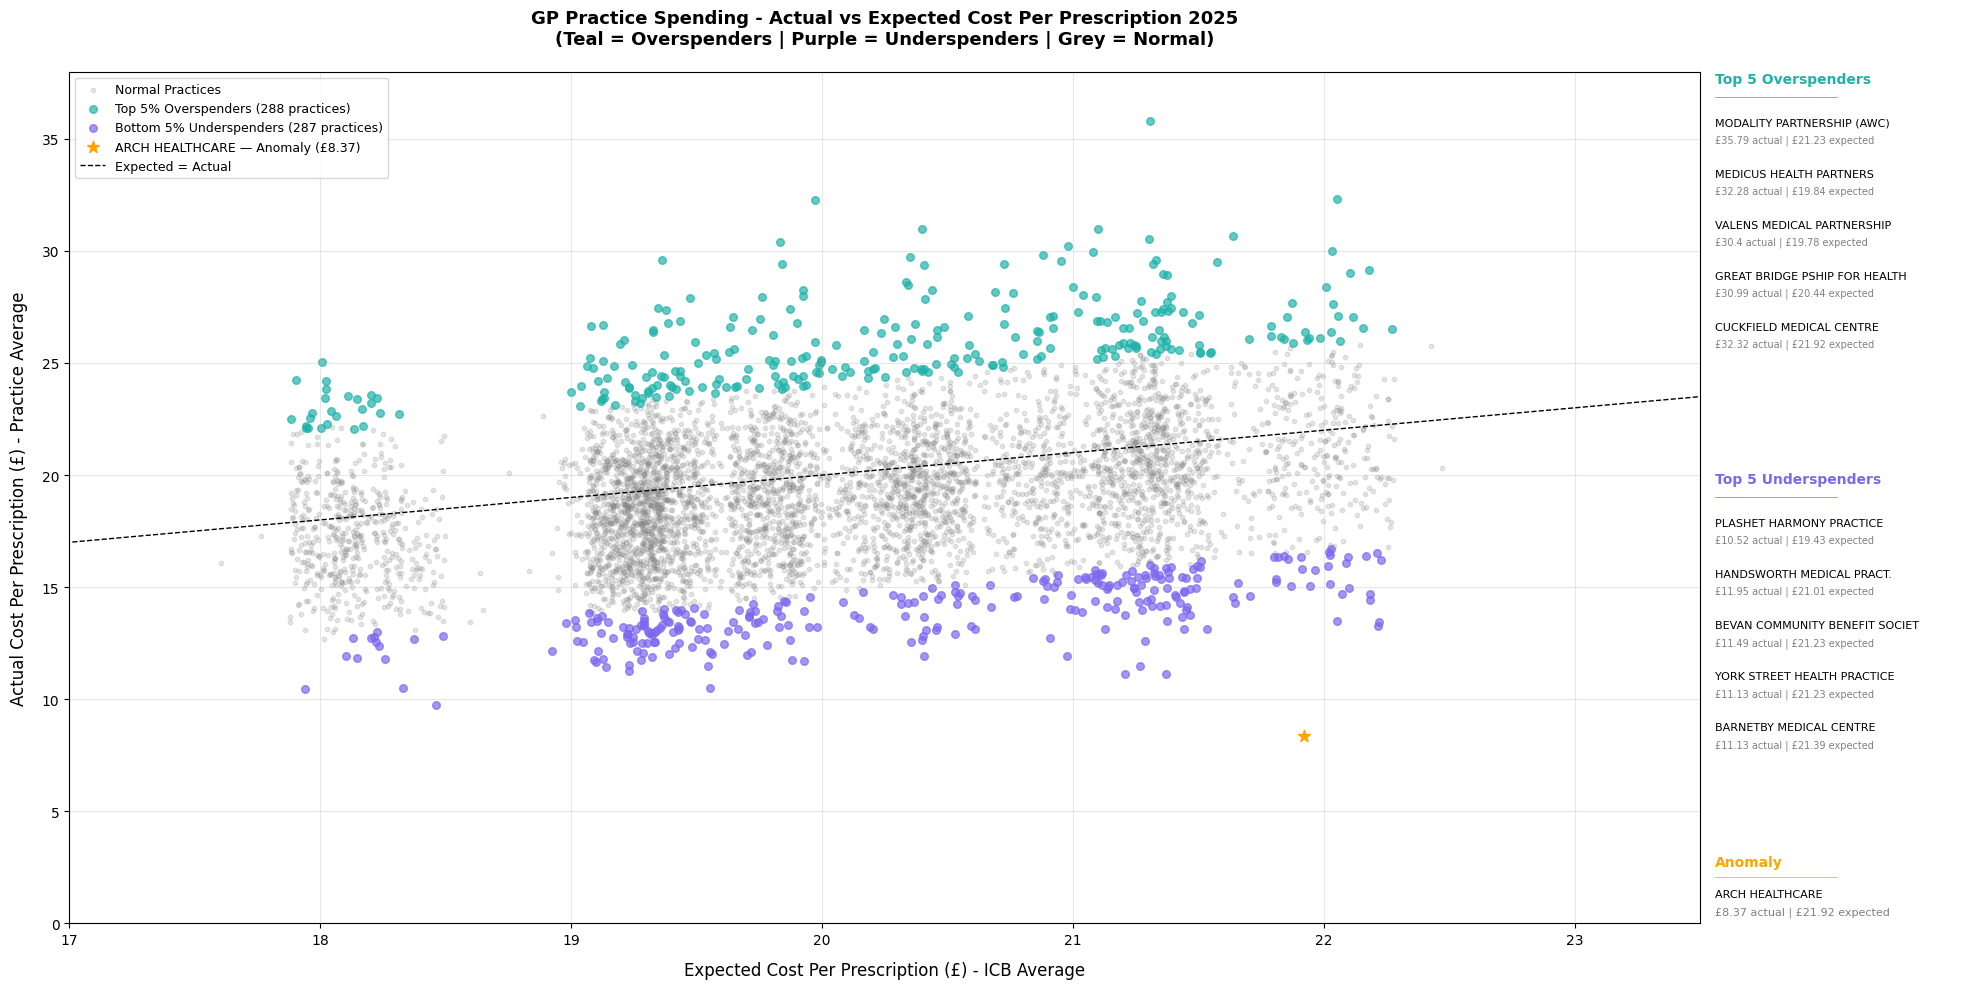

Chart saved


In [125]:
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 0.3])

ax_scatter = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

np.random.seed(42)

def add_jitter(data, amount=0.15):
    return data + np.random.uniform(-amount, amount, size=len(data))

# Normal practices
normal_practices = final_gp_outliers_clean[
    ~final_gp_outliers_clean['PRACTICE_CODE'].isin(
        top_overspenders['PRACTICE_CODE'].tolist() + 
        bottom_underspenders['PRACTICE_CODE'].tolist() +
        ['G81689']
    )
]

ax_scatter.scatter(
    add_jitter(normal_practices['avg_expected_cost']),
    normal_practices['avg_practice_cost'],
    color='grey', alpha=0.2, s=10, label='Normal Practices'
)

# Top 5% overspenders
ax_scatter.scatter(
    add_jitter(top_overspenders['avg_expected_cost']),
    top_overspenders['avg_practice_cost'],
    color='#20B2AA', alpha=0.7, s=30, label='Top 5% Overspenders (288 practices)'
)

# Bottom 5% underspenders
ax_scatter.scatter(
    add_jitter(bottom_underspenders[bottom_underspenders['PRACTICE_CODE'] != 'G81689']['avg_expected_cost']),
    bottom_underspenders[bottom_underspenders['PRACTICE_CODE'] != 'G81689']['avg_practice_cost'],
    color='#7B68EE', alpha=0.7, s=30, label='Bottom 5% Underspenders (287 practices)'
)

# ARCH HEALTHCARE
arch = final_gp_outliers_clean[final_gp_outliers_clean['PRACTICE_CODE'] == 'G81689']
ax_scatter.scatter(
    arch['avg_expected_cost'],
    arch['avg_practice_cost'],
    color='orange', alpha=1.0, s=80, label='ARCH HEALTHCARE — Anomaly (£8.37)',
    zorder=5, marker='*'
)

ax_scatter.plot([0, 25], [0, 25],
        color='black', linewidth=1, linestyle='--', label='Expected = Actual')

ax_scatter.set_xlim(17, 23.50)
ax_scatter.set_ylim(0, 38)
ax_scatter.set_xlabel('Expected Cost Per Prescription (£) - ICB Average', fontsize=12, labelpad=10)
ax_scatter.set_ylabel('Actual Cost Per Prescription (£) - Practice Average', fontsize=12, labelpad=10)
ax_scatter.set_title('GP Practice Spending - Actual vs Expected Cost Per Prescription 2025\n(Teal = Overspenders | Purple = Underspenders | Grey = Normal)', fontsize=13, fontweight='bold', pad=20)
ax_scatter.legend(fontsize=9, loc='upper left')
ax_scatter.grid(True, alpha=0.3)

# --- Right panel legend ---
ax_legend.axis('off')

# Top 5 overspenders
# Top 5 overspenders
ax_legend.text(0.0, 1.0, 'Top 5 Overspenders', fontsize=10, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='#20B2AA')
ax_legend.plot([0, 0.5], [0.97, 0.97], color='#20B2AA', linewidth=0.5, transform=ax_legend.transAxes)

top5 = top_overspenders.head(5)
for idx, (_, row) in enumerate(top5.iterrows()):
    y_pos = 0.93 - idx * 0.06
    short_name = row['PRACTICE_NAME'][:30]
    ax_legend.text(0.0, y_pos + 0.01, short_name, fontsize=8,
                   transform=ax_legend.transAxes, va='center')
    ax_legend.text(0.0, y_pos - 0.01, f"£{row['avg_practice_cost']} actual | £{row['avg_expected_cost']} expected",
                   fontsize=7, transform=ax_legend.transAxes, va='center', color='grey')

# Top 5 underspenders 
ax_legend.text(0.0, 0.53, 'Top 5 Underspenders', fontsize=10, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='#7B68EE')
ax_legend.plot([0, 0.5], [0.50, 0.50], color='#7B68EE', linewidth=0.5, transform=ax_legend.transAxes)

bottom5 = bottom_underspenders[bottom_underspenders['PRACTICE_CODE'] != 'G81689'].tail(5)
for idx, (_, row) in enumerate(bottom5.iterrows()):
    y_pos = 0.46 - idx * 0.06
    short_name = row['PRACTICE_NAME'][:30]
    ax_legend.text(0.0, y_pos + 0.01, short_name, fontsize=8,
                   transform=ax_legend.transAxes, va='center')
    ax_legend.text(0.0, y_pos - 0.01, f"£{row['avg_practice_cost']} actual | £{row['avg_expected_cost']} expected",
                   fontsize=7, transform=ax_legend.transAxes, va='center', color='grey')

# Anomaly
ax_legend.text(0.0, 0.08, 'Anomaly', fontsize=10, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='orange')
ax_legend.plot([0, 0.5], [0.055, 0.055], color='orange', linewidth=0.5, transform=ax_legend.transAxes)
ax_legend.text(0.0, 0.04, f"ARCH HEALTHCARE",
               fontsize=8, transform=ax_legend.transAxes, va='top', color='black')
ax_legend.text(0.0, 0.02, f"£8.37 actual | £21.92 expected",
               fontsize=8, transform=ax_legend.transAxes, va='top', color='grey')

plt.tight_layout()
plt.savefig('chapter3_scatter_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [126]:
# Get count of overspending practices per ICB
icb_overspend_count = top_overspenders.groupby('ICB_NAME').size().reset_index(name='overspend_count')
# Counts how many top 5% overspending practices are in each ICB

# Merge with boundary file
icb_map['ICB23NM_UPPER'] = icb_map['ICB23NM'].str.upper()
icb_map_outliers = icb_map.merge(
    icb_overspend_count,
    left_on='ICB23NM_UPPER',
    right_on='ICB_NAME',
    how='left'
)
icb_map_outliers['overspend_count'] = icb_map_outliers['overspend_count'].fillna(0)
# ICBs with no overspending practices get 0

print(icb_map_outliers[['ICB23NM', 'overspend_count']].sort_values('overspend_count', ascending=False).head(10))

                                              ICB23NM  overspend_count
31           NHS West Yorkshire Integrated Care Board               19
12        NHS North West London Integrated Care Board               18
29  NHS North East and North Cumbria Integrated Ca...               18
14        NHS North East London Integrated Care Board               16
41                   NHS Sussex Integrated Care Board               15
30  NHS Humber and North Yorkshire Integrated Care...               14
34       NHS Greater Manchester Integrated Care Board               12
15        NHS South East London Integrated Care Board               12
17          NHS Kent and Medway Integrated Care Board               11
39            NHS Black Country Integrated Care Board               11


In [127]:
# Recreate icb_map_outliers with both overspend and underspend counts
icb_overspend_count = top_overspenders.groupby('ICB_NAME').size().reset_index(name='overspend_count')
icb_underspend_count = bottom_underspenders.groupby('ICB_NAME').size().reset_index(name='underspend_count')

# Merge with boundary file
icb_map['ICB23NM_UPPER'] = icb_map['ICB23NM'].str.upper()

icb_map_outliers = icb_map.merge(icb_overspend_count, left_on='ICB23NM_UPPER', right_on='ICB_NAME', how='left')
icb_map_outliers['overspend_count'] = icb_map_outliers['overspend_count'].fillna(0)

icb_map_outliers = icb_map_outliers.merge(icb_underspend_count, left_on='ICB23NM_UPPER', right_on='ICB_NAME', how='left')
icb_map_outliers['underspend_count'] = icb_map_outliers['underspend_count'].fillna(0)

print(icb_map_outliers[['ICB23NM', 'overspend_count', 'underspend_count']].head())

                                             ICB23NM  overspend_count  \
0  NHS Cheshire and Merseyside Integrated Care Board                7   
1  NHS Staffordshire and Stoke-on-Trent Integrate...                6   
2  NHS Shropshire, Telford and Wrekin Integrated ...                1   
3             NHS Lincolnshire Integrated Care Board                2   
4  NHS Leicester, Leicestershire and Rutland Inte...                4   

   underspend_count  
0                16  
1                 6  
2                 4  
3                 2  
4                 4  


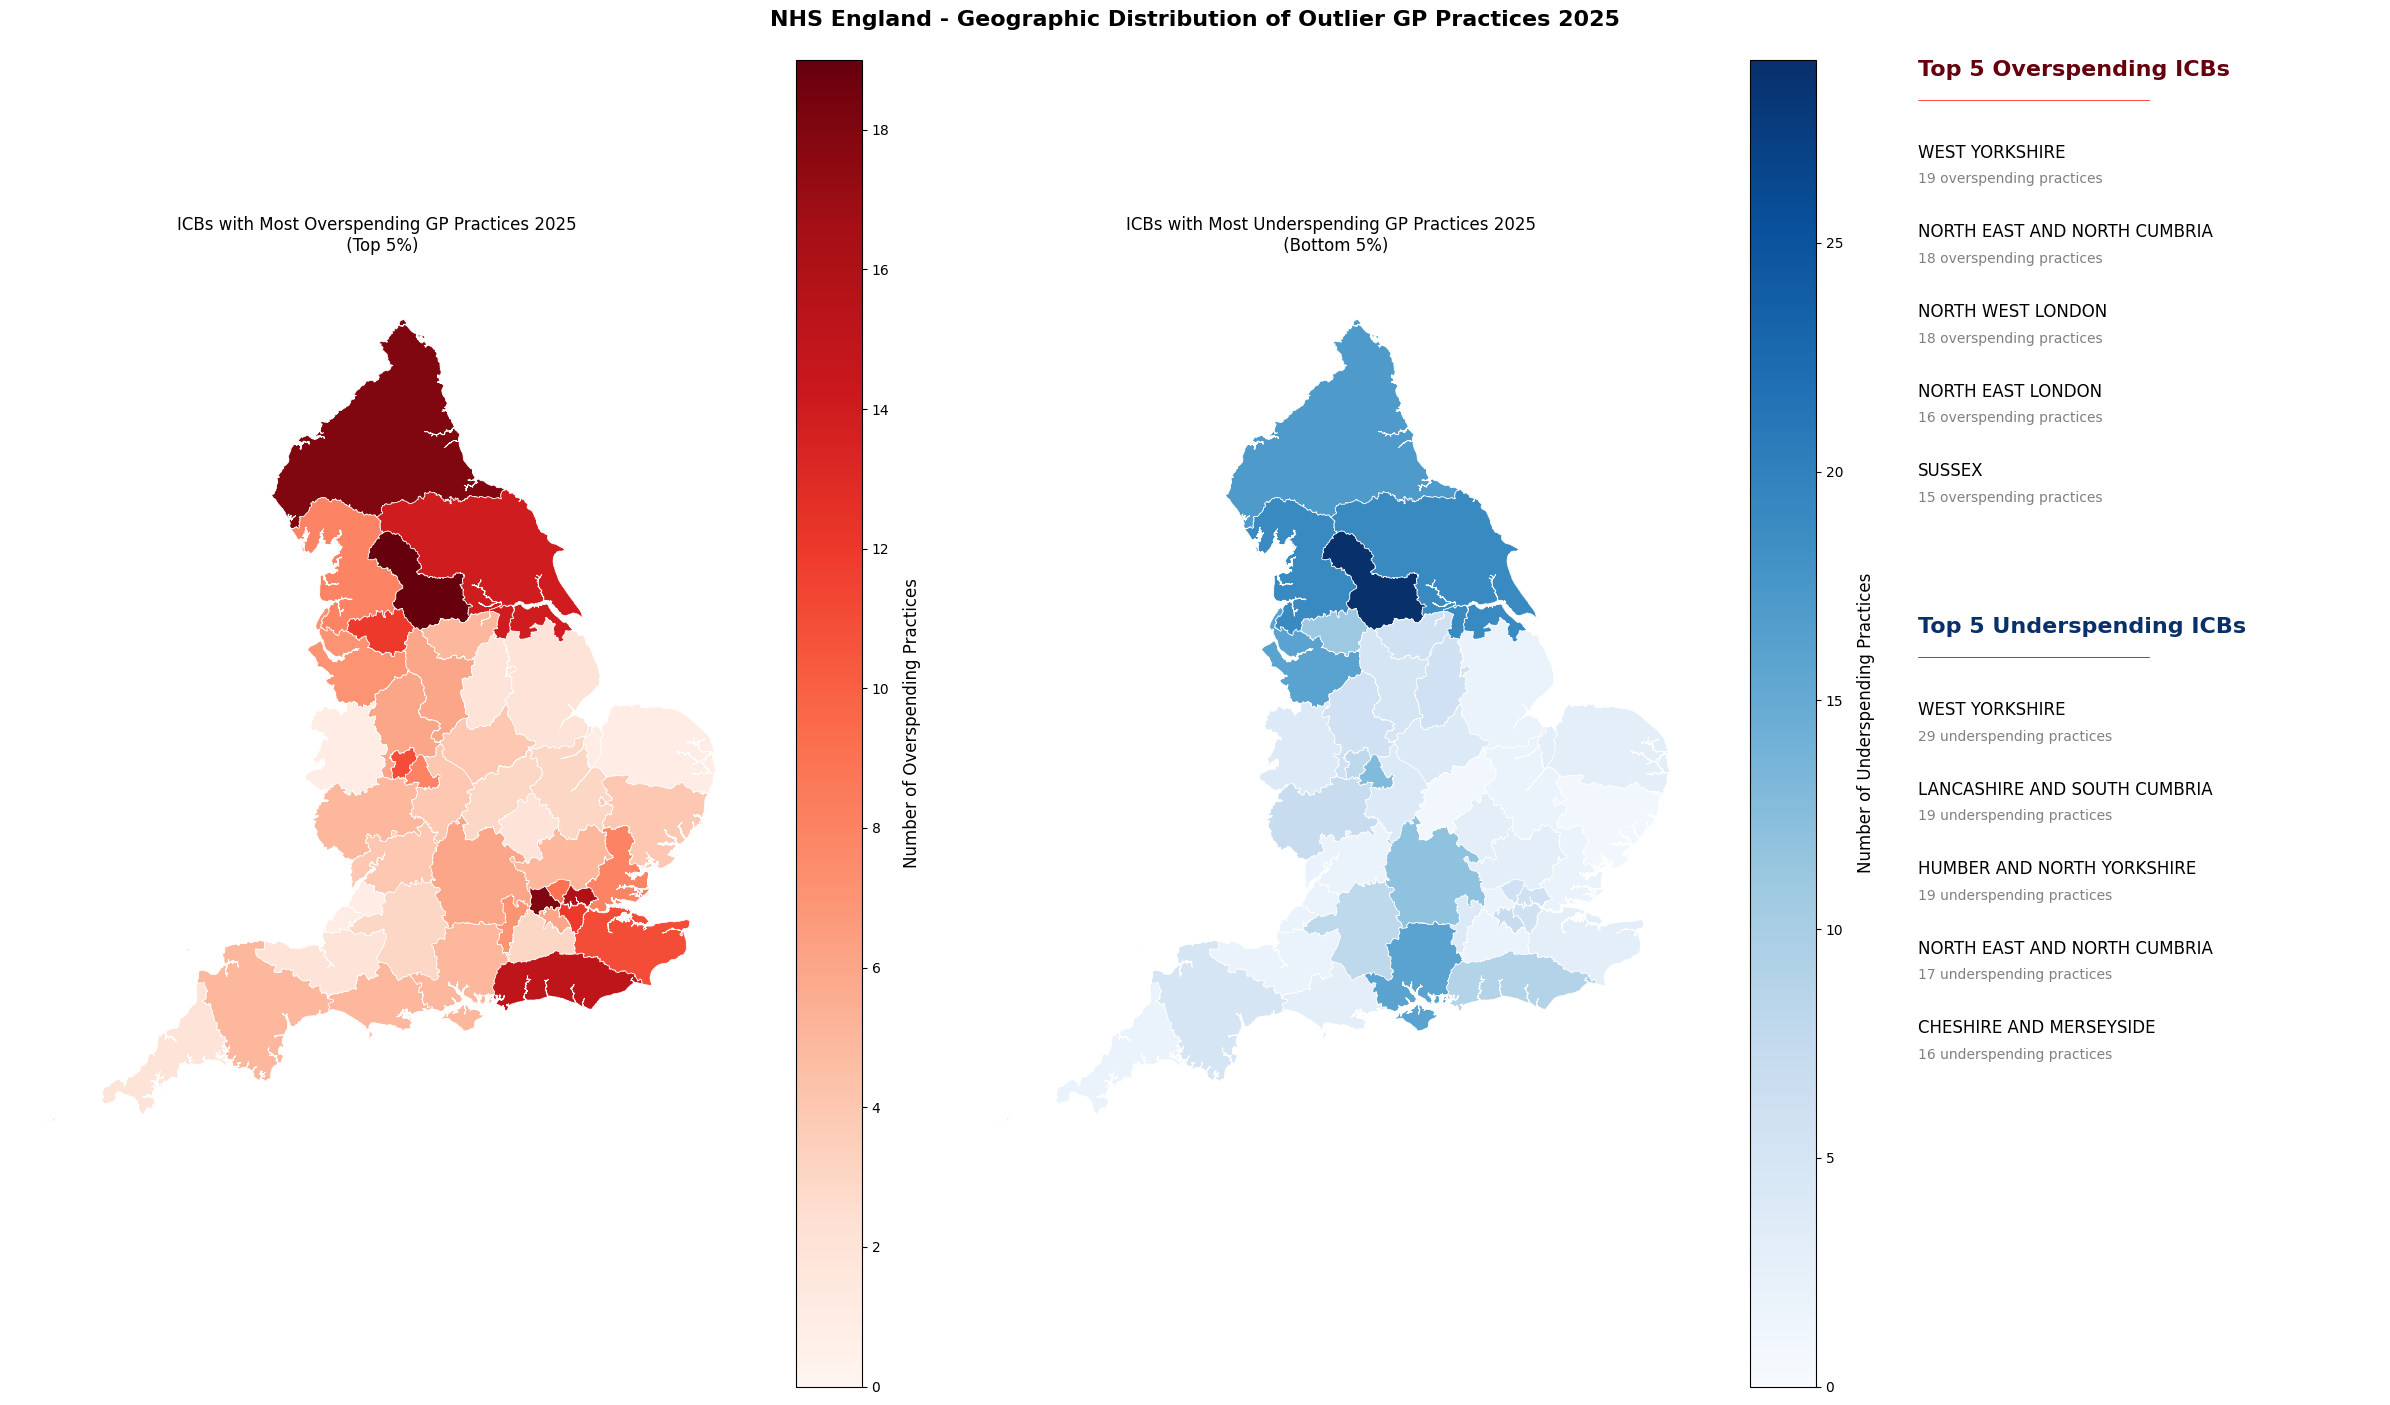

Map saved


In [128]:
fig = plt.figure(figsize=(24, 14))
gs = gridspec.GridSpec(1, 3, width_ratios=[2, 2, 1])

ax_over = fig.add_subplot(gs[0])
ax_under = fig.add_subplot(gs[1])
ax_legend = fig.add_subplot(gs[2])

# Overspenders map
icb_map_outliers.plot(
    column='overspend_count',
    cmap='Reds',
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Number of Overspending Practices', 'orientation': 'vertical'},
    ax=ax_over,
    vmin=0,
    vmax=icb_map_outliers['overspend_count'].max()
)

cbar_over = ax_over.get_figure().axes[1]
cbar_over.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax_over.get_figure().axes[-1].yaxis.label.set_size(12)
ax_over.get_figure().axes[-1].yaxis.labelpad = 10

ax_over.set_title('ICBs with Most Overspending GP Practices 2025 \n (Top 5%)', fontsize=12, pad=20)
ax_over.axis('off')

# Underspenders map
icb_map_outliers.plot(
    column='underspend_count',
    cmap='Blues',
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Number of Underspending Practices', 'orientation': 'vertical'},
    ax=ax_under,
    vmin=0,
    vmax=icb_map_outliers['underspend_count'].max()
)

cbar_under = ax_under.get_figure().axes[3]
cbar_under.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax_under.get_figure().axes[-1].yaxis.label.set_size(12)
ax_under.get_figure().axes[-1].yaxis.labelpad = 10

ax_under.set_title('ICBs with Most Underspending GP Practices 2025 \n (Bottom 5%)', fontsize=12, pad=20)
ax_under.axis('off')

# Legend table
ax_legend.axis('off')

# Top 5 overspending ICBs
ax_legend.text(0.0, 1.0, 'Top 5 Overspending ICBs', fontsize=16, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='#67000D')
ax_legend.plot([0, 0.5], [0.97, 0.97], color='red', linewidth=0.5, transform=ax_legend.transAxes)

top5_over = icb_overspend_count.sort_values('overspend_count', ascending=False).head(5)
for idx, (_, row) in enumerate(top5_over.iterrows()):
    y_pos = 0.92 - idx * 0.06
    short_name = row['ICB_NAME'].replace('INTEGRATED CARE BOARD', '').replace('NHS ', '').strip()[:35]
    ax_legend.text(0.0, y_pos + 0.01, short_name, fontsize=12,
                   transform=ax_legend.transAxes, va='center')
    ax_legend.text(0.0, y_pos - 0.01, f"{int(row['overspend_count'])} overspending practices",
                   fontsize=10, transform=ax_legend.transAxes, va='center', color='grey')

# Top 5 underspending ICBs
ax_legend.text(0.0, 0.58, 'Top 5 Underspending ICBs', fontsize=16, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='#08306B')
ax_legend.plot([0, 0.5], [0.55, 0.55], color='blue', linewidth=0.5, transform=ax_legend.transAxes)

top5_under = icb_underspend_count.sort_values('underspend_count', ascending=False).head(5)
for idx, (_, row) in enumerate(top5_under.iterrows()):
    y_pos = 0.50 - idx * 0.06
    short_name = row['ICB_NAME'].replace('INTEGRATED CARE BOARD', '').replace('NHS ', '').strip()[:35]
    ax_legend.text(0.0, y_pos + 0.01, short_name, fontsize=12,
                   transform=ax_legend.transAxes, va='center')
    ax_legend.text(0.0, y_pos - 0.01, f"{int(row['underspend_count'])} underspending practices",
                   fontsize=10, transform=ax_legend.transAxes, va='center', color='grey')

fig.suptitle('NHS England - Geographic Distribution of Outlier GP Practices 2025',
             fontsize=16, fontweight='bold', y=1.0)

plt.tight_layout()
plt.savefig('chapter3_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Map saved")

In [129]:
# Table — top 20 persistent overspending practices
top20_table = top_overspenders.head(20)[['PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE', 'avg_practice_cost', 'avg_expected_cost', 'avg_residual']].copy()

# Shorten ICB names
top20_table['ICB_NAME'] = top20_table['ICB_NAME'].str.replace('INTEGRATED CARE BOARD', '').str.replace('NHS ', '').str.strip()

# Rename columns for display
top20_table.columns = ['Practice', 'ICB', 'Region', 'Actual Cost £', 'Expected Cost £', 'Residual £']

print(top20_table.to_string(index=False))

                       Practice                                   ICB                   Region  Actual Cost £  Expected Cost £  Residual £
     MODALITY PARTNERSHIP (AWC)                        WEST YORKSHIRE NORTH EAST AND YORKSHIRE          35.79            21.23       14.56
        MEDICUS HEALTH PARTNERS                  NORTH CENTRAL LONDON                   LONDON          32.28            19.84       12.44
     VALENS MEDICAL PARTNERSHIP          NORTH EAST AND NORTH CUMBRIA NORTH EAST AND YORKSHIRE          30.40            19.78       10.63
  GREAT BRIDGE PSHIP FOR HEALTH                         BLACK COUNTRY                 MIDLANDS          30.99            20.44       10.55
       CUCKFIELD MEDICAL CENTRE                                SUSSEX               SOUTH EAST          32.32            21.92       10.40
       THE FOREST EDGE PRACTICE                     NORTH EAST LONDON                   LONDON          29.58            19.43       10.15
  FARNHAM DENE MEDICAL PRAC

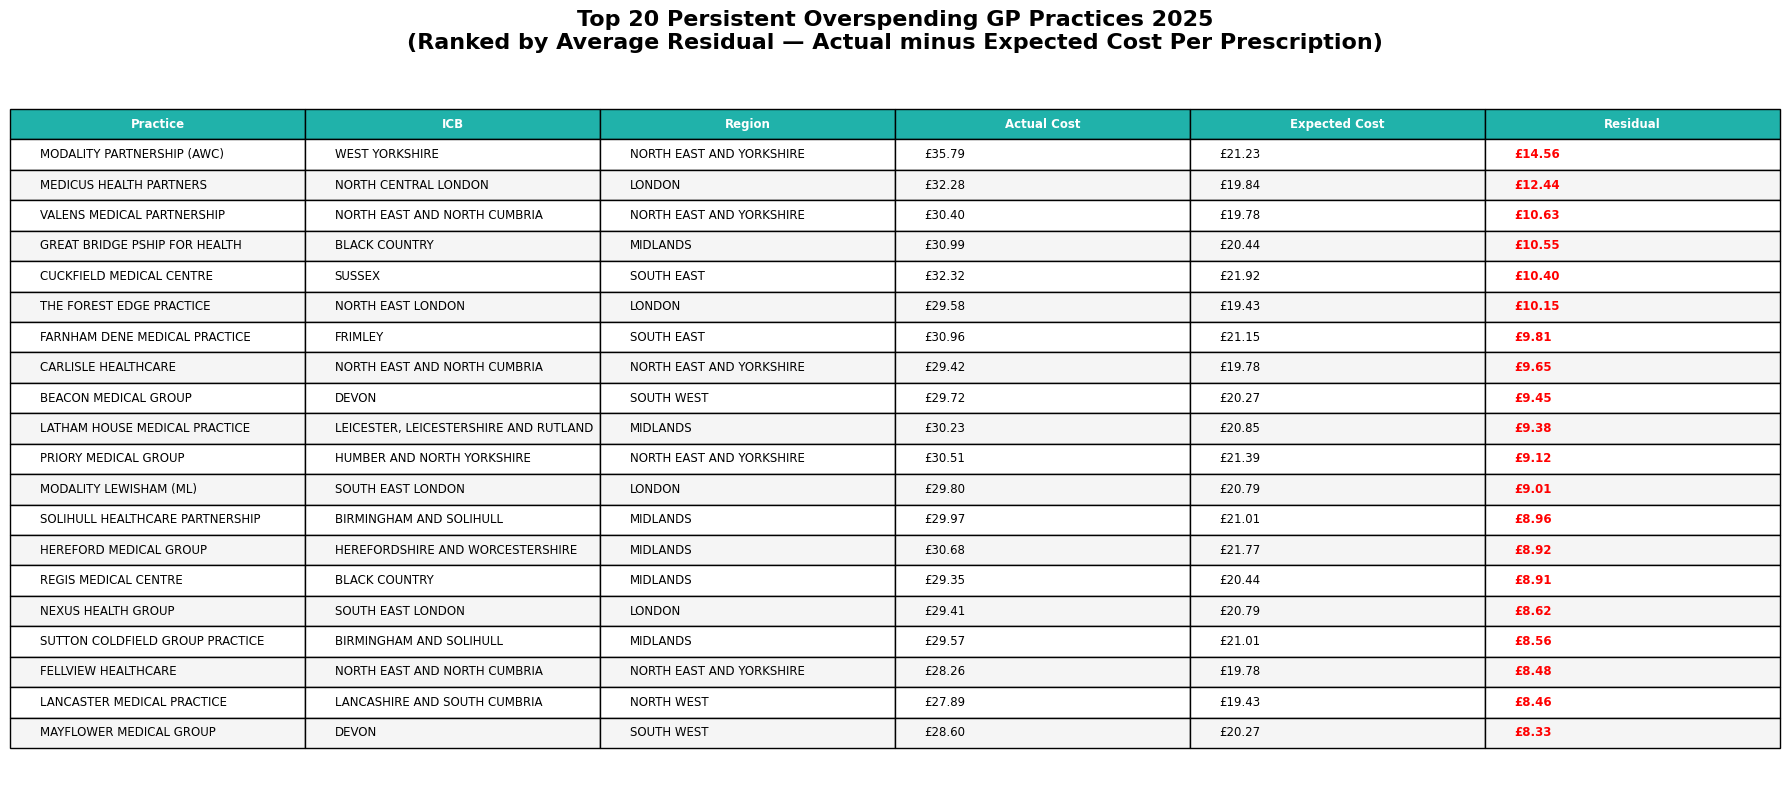

Table saved


In [130]:
fig, ax = plt.subplots(figsize=(18, 8))
ax.axis('off')

# Table data
table_data = []
for _, row in top20_table.iterrows():
    table_data.append([
        row['Practice'],
        row['ICB'],
        row['Region'],
        f"£{row['Actual Cost £']:.2f}",
        f"£{row['Expected Cost £']:.2f}",
        f"£{row['Residual £']:.2f}"
    ])

columns = ['Practice', 'ICB', 'Region', 'Actual Cost', 'Expected Cost', 'Residual']

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='left',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.6)
# Makes rows taller for readability

# Style header row
for col in range(len(columns)):
    table[0, col].set_facecolor('#20B2AA')
    table[0, col].set_text_props(color='white', fontweight='bold')

# Alternate row colors for readability
for row in range(1, len(table_data) + 1):
    for col in range(len(columns)):
        if row % 2 == 0:
            table[row, col].set_facecolor('#f5f5f5')
        else:
            table[row, col].set_facecolor('white')

# Color the residual column red to highlight overspending
for row in range(1, len(table_data) + 1):
    table[row, 5].set_text_props(color='red', fontweight='bold')

ax.set_title('Top 20 Persistent Overspending GP Practices 2025\n(Ranked by Average Residual — Actual minus Expected Cost Per Prescription)',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chapter3_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Table saved")

In [131]:
# Top 20 underspending practices table
top20_under_table = bottom_underspenders.tail(20)[['PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE', 'avg_practice_cost', 'avg_expected_cost', 'avg_residual']].copy()

# Shorten ICB names
top20_under_table['ICB_NAME'] = top20_under_table['ICB_NAME'].str.replace('INTEGRATED CARE BOARD', '').str.replace('NHS ', '').str.strip()

# Rename columns
top20_under_table.columns = ['Practice', 'ICB', 'Region', 'Actual Cost £', 'Expected Cost £', 'Residual £']

# Sort by residual ascending — most extreme underspender first
top20_under_table = top20_under_table.sort_values('Residual £', ascending=True)

print(top20_under_table.to_string(index=False))

                       Practice                                   ICB                   Region  Actual Cost £  Expected Cost £  Residual £
                ARCH HEALTHCARE                                SUSSEX               SOUTH EAST           8.37            21.92      -13.54
        BARNETBY MEDICAL CENTRE            HUMBER AND NORTH YORKSHIRE NORTH EAST AND YORKSHIRE          11.13            21.39      -10.26
    YORK STREET HEALTH PRACTICE                        WEST YORKSHIRE NORTH EAST AND YORKSHIRE          11.13            21.23      -10.10
BEVAN COMMUNITY BENEFIT SOCIETY                        WEST YORKSHIRE NORTH EAST AND YORKSHIRE          11.49            21.23       -9.74
      HANDSWORTH MEDICAL PRACT.               BIRMINGHAM AND SOLIHULL                 MIDLANDS          11.95            21.01       -9.06
       PLASHET HARMONY PRACTICE                     NORTH EAST LONDON                   LONDON          10.52            19.43       -8.91
   SOUTH WIGHT MEDICAL PRAC

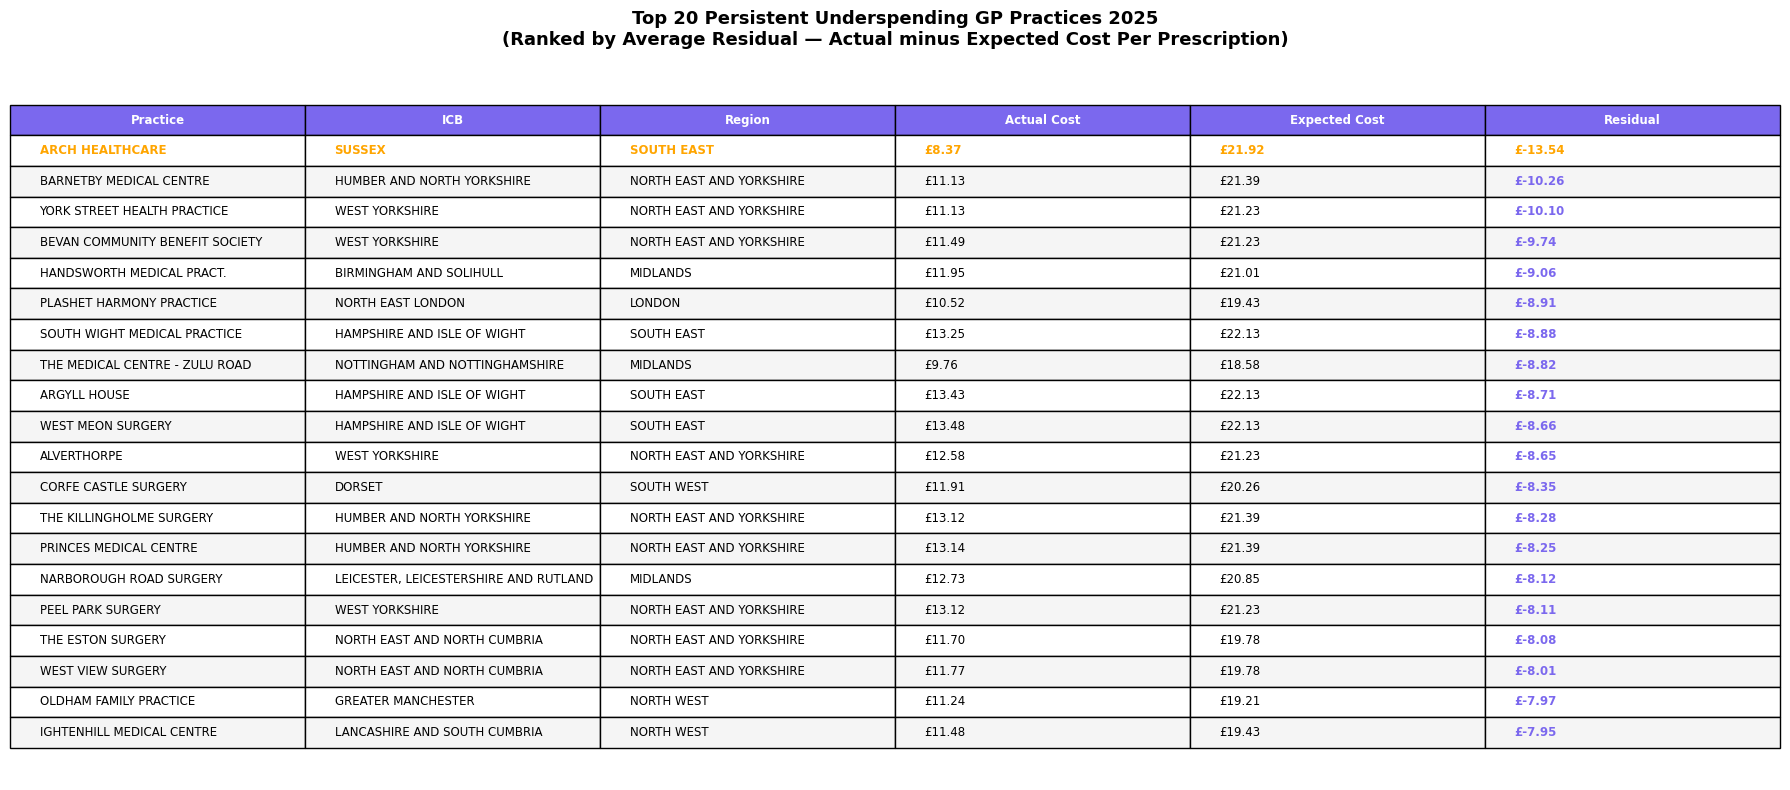

Table saved


In [132]:
fig, ax = plt.subplots(figsize=(18, 8))
ax.axis('off')

# Table data
table_data = []
for _, row in top20_under_table.iterrows():
    table_data.append([
        row['Practice'],
        row['ICB'],
        row['Region'],
        f"£{row['Actual Cost £']:.2f}",
        f"£{row['Expected Cost £']:.2f}",
        f"£{row['Residual £']:.2f}"
    ])

columns = ['Practice', 'ICB', 'Region', 'Actual Cost', 'Expected Cost', 'Residual']

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='left',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.6)

# Style header row
for col in range(len(columns)):
    table[0, col].set_facecolor('#7B68EE')
    table[0, col].set_text_props(color='white', fontweight='bold')

# Alternate row colors
for row in range(1, len(table_data) + 1):
    for col in range(len(columns)):
        if row % 2 == 0:
            table[row, col].set_facecolor('#f5f5f5')
        else:
            table[row, col].set_facecolor('white')

# Color residual column blue
for row in range(1, len(table_data) + 1):
    table[row, 5].set_text_props(color='#7B68EE', fontweight='bold')

# Highlight ARCH HEALTHCARE row in orange
for col in range(len(columns)):
    table[1, col].set_text_props(color='orange', fontweight='bold')

ax.set_title('Top 20 Persistent Underspending GP Practices 2025\n(Ranked by Average Residual — Actual minus Expected Cost Per Prescription)',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chapter3_table_under.png', dpi=150, bbox_inches='tight')
plt.show()
print("Table saved")

In [133]:
# # Save final_gp_outliers_clean to parquet for reference
# final_gp_outliers_clean.to_parquet(
#     'D:/UEA/Business Analytics/P1/Code_Dataset/Merged/final_gp_outliers_clean.parquet',
#     index=False
# )

# print(f"Saved: {len(final_gp_outliers_clean)} practices")
# print(f"Columns: {final_gp_outliers_clean.columns.tolist()}")

In [134]:
# df = pd.read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/final_gp_outliers_clean.parquet')
# df.head()

=========================================================================================================================================================

11. Chapter 4

In [135]:
# Verify the main dataset is intact
check = con.execute("""
    SELECT 
        COUNT(*) AS total_rows,
        COUNT(DISTINCT PRACTICE_CODE) AS total_practices,
        COUNT(DISTINCT ICB_NAME) AS total_icbs,
        COUNT(DISTINCT BNF_CHAPTER_CODE) AS total_categories,
        COUNT(DISTINCT MONTH) AS total_months,
        ROUND(SUM(ACTUAL_COST) / 1000000000, 2) AS total_spend_billions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
""").df()

print(check)

   total_rows  total_practices  total_icbs  total_categories  total_months  \
0   217707834            10013          42                21            12   

   total_spend_billions  
0                 10.54  


In [136]:
# Check distinct practice codes carefully
practice_count_check = con.execute("""
    SELECT 
        COUNT(DISTINCT PRACTICE_CODE) AS distinct_codes,
        COUNT(DISTINCT (PRACTICE_CODE || PRACTICE_NAME)) AS distinct_code_name_combos
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
""").df()

print(practice_count_check)

   distinct_codes  distinct_code_name_combos
0           10013                      10122


In [137]:
# Find practices with multiple names
multiple_names = con.execute("""
    SELECT 
        PRACTICE_CODE,
        COUNT(DISTINCT PRACTICE_NAME) AS name_count,
        LIST(DISTINCT PRACTICE_NAME) AS names
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    GROUP BY PRACTICE_CODE
    HAVING COUNT(DISTINCT PRACTICE_NAME) > 1
    LIMIT 10
""").df()

print(f"Practices with multiple names: {len(multiple_names)}")
print(multiple_names)

Practices with multiple names: 10
  PRACTICE_CODE  name_count                                              names
0        J82051           3  [HAMBLE VALLEY HEALTH PCN, HAMBLE VALLEY HEALT...
1        Y06131           2                     [WHC, WILTSHIRE HCRG SERVICES]
2        L81118           2  [STOKE GIFFORD MEDICAL CENTRE, STOKES MEDICAL ...
3        Y07020           2    [ONE CARE LAMBETH, LAMBETH HEALTHCARE PRACTICE]
4        J82138           2                  [HOOK SURGERY, WHITEWATER HEALTH]
5        K81636           2       [COLEY PARK SURGERY, RUSSELL STREET SURGERY]
6        Y01220           2   [CGL LIVERPOOL, WE ARE WITH YOU LIVERPOOL NORTH]
7        Y00081           2       [LOCALA KIRKLEES SAS, SAFE HAVEN UNIT - LCD]
8        H82028           2  [THE COURTYARD SURGERY, THE COURTYARD SURGERY ...
9        Y03746           2  [WARRINGTON COMMUNITY NURSES, B'WATER CH CN WA...


In [138]:
# Load data for only clean GP practices for the predictive model
practice_codes = final_gp_outliers_clean['PRACTICE_CODE'].tolist()

model_data = con.execute("""
    SELECT 
        PRACTICE_CODE,
        ICB_CODE,
        BNF_CHAPTER_CODE,
        MONTH,
        QUARTER,
        SUM(ITEMS) AS total_items,
        SUM(TOTAL_QUANTITY) AS total_quantity,
        SUM(ADQ_USAGE) AS total_adq,
        ROUND(AVG(NIC_RATIO), 4) AS avg_nic_ratio,
        ROUND(SUM(ACTUAL_COST), 2) AS total_actual_cost
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE PRACTICE_CODE IN ({})
    GROUP BY PRACTICE_CODE, ICB_CODE, BNF_CHAPTER_CODE, MONTH, QUARTER
""".format(','.join([f"'{p}'" for p in practice_codes]))).df()

print(f"Total rows: {len(model_data)}")
print(model_data.head())

Total rows: 1346457
  PRACTICE_CODE ICB_CODE             BNF_CHAPTER_CODE  MONTH  QUARTER  \
0        F86044      QMF               21: Appliances      1        1   
1        F82007      QMF    02: Cardiovascular System      1        1   
2        L84060      QR1  22: Incontinence Appliances      1        1   
3        G82162      QKS         23: Stoma Appliances      1        1   
4        L81071      QOX               21: Appliances      1        1   

   total_items  total_quantity  total_adq  avg_nic_ratio  total_actual_cost  
0        285.0         50704.0       0.00         0.9241            5522.18  
1       5349.0        205009.0  188937.08         0.9194           17157.85  
2         66.0           665.0       0.00         0.9921            1274.10  
3         51.0          5326.0       0.00         0.9900            3374.76  
4        471.0        101224.0       0.00         0.9129            7679.22  


In [139]:
# Verify the row count
verify = con.execute("""
    SELECT 
        COUNT(*) AS total_rows,
        COUNT(DISTINCT PRACTICE_CODE) AS practices,
        COUNT(DISTINCT BNF_CHAPTER_CODE) AS categories,
        COUNT(DISTINCT MONTH) AS months,
        COUNT(DISTINCT PRACTICE_CODE || BNF_CHAPTER_CODE || CAST(MONTH AS VARCHAR)) AS unique_combinations
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE PRACTICE_CODE IN ({})
    GROUP BY PRACTICE_CODE, BNF_CHAPTER_CODE, MONTH
""".format(','.join([f"'{p}'" for p in practice_codes]))).df()

print(f"Expected maximum: {5764 * 21 * 12} rows")
print(f"Actual rows in model_data: {len(model_data)}")
print(f"Difference: {5764 * 21 * 12 - len(model_data)} missing combinations")

Expected maximum: 1452528 rows
Actual rows in model_data: 1346457
Difference: 106071 missing combinations


In [140]:
# Check which categories have the most missing combinations
missing_check = con.execute("""
    SELECT 
        BNF_CHAPTER_CODE,
        COUNT(DISTINCT PRACTICE_CODE || CAST(MONTH AS VARCHAR)) AS actual_combinations,
        {} * 12 AS max_possible,
        ({} * 12) - COUNT(DISTINCT PRACTICE_CODE || CAST(MONTH AS VARCHAR)) AS missing
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE PRACTICE_CODE IN ({})
    GROUP BY BNF_CHAPTER_CODE
    ORDER BY missing DESC
""".format(
    len(practice_codes),
    len(practice_codes),
    ','.join([f"'{p}'" for p in practice_codes])
)).df()

print(missing_check)

                                     BNF_CHAPTER_CODE  actual_combinations  \
0                  18: Preparations used in Diagnosis                   44   
1             14: Immunological Products and Vaccines                57613   
2                    19: Other Drugs and Preparations                63373   
3                         22: Incontinence Appliances                63918   
4                                     15: Anaesthesia                67322   
5                                       20: Dressings                68077   
6                                23: Stoma Appliances                68369   
7         08: Malignant Disease and Immunosuppression                68388   
8                                             11: Eye                68399   
9                        12: Ear, Nose and Oropharynx                68403   
10             10: Musculoskeletal and Joint Diseases                68404   
11                                           13: Skin           

In [141]:
# Step 1: Encode categorical columns into numbers first
le_icb = LabelEncoder()
le_bnf = LabelEncoder()

model_data['ICB_CODE_ENC'] = le_icb.fit_transform(model_data['ICB_CODE'])
model_data['BNF_CHAPTER_ENC'] = le_bnf.fit_transform(model_data['BNF_CHAPTER_CODE'])
# Converts text categories into numbers so the model can understand them

# Step 2: Train/test split — time respecting
train_data = model_data[model_data['MONTH'] <= 10]
test_data = model_data[model_data['MONTH'] > 10]
# Jan-Oct 2025 = training, Nov-Dec 2025 = testing

# Step 3: Define input and target variables
features = ['total_items', 'total_quantity', 'total_adq', 'avg_nic_ratio',
            'ICB_CODE_ENC', 'BNF_CHAPTER_ENC', 'MONTH', 'QUARTER']
target = 'total_actual_cost'

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
print(f"\nFeatures: {features}")
print(f"Target: {target}")

Training rows: 1122252
Test rows: 224205

Features: ['total_items', 'total_quantity', 'total_adq', 'avg_nic_ratio', 'ICB_CODE_ENC', 'BNF_CHAPTER_ENC', 'MONTH', 'QUARTER']
Target: total_actual_cost


In [142]:
# Train baseline Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
# Model learns the relationship between inputs and actual cost

# Evaluate on test data
y_pred_lr = lr_model.predict(X_test)

# Calculate metrics
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("--- Linear Regression (Baseline) ---")
print(f"R²:   {r2_lr:.4f}")
print(f"RMSE: £{rmse_lr:,.2f}")
print(f"MAE:  £{mae_lr:,.2f}")

--- Linear Regression (Baseline) ---
R²:   0.5512
RMSE: £7,840.48
MAE:  £4,384.41


In [143]:
# Train Random Forest model
print("Training Random Forest — this may take a few minutes...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    # 100 decision trees in the forest
    max_depth=15,
    # Each tree can go 15 levels deep
    min_samples_split=10,
    # Need at least 10 samples to split a node
    random_state=42,
    # For reproducibility
    n_jobs=-1
    # Use all CPU cores for faster training
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("--- Random Forest ---")
print(f"R²:   {r2_rf:.4f}")
print(f"RMSE: £{rmse_rf:,.2f}")
print(f"MAE:  £{mae_rf:,.2f}")

Training Random Forest — this may take a few minutes...
--- Random Forest ---
R²:   0.9540
RMSE: £2,511.08
MAE:  £1,133.70


In [178]:
# Save the model
joblib.dump(rf_model, "rf_model.pkl")

# Save the label encoders
joblib.dump(le_icb, "le_icb.pkl")
joblib.dump(le_bnf, "le_bnf.pkl")

['le_bnf.pkl']

In [179]:
# In your notebook — compress the model when saving:
import joblib
joblib.dump(rf_model, "rf_model.pkl", compress=3)

['rf_model.pkl']

In [144]:
# Train Gradient Boosting model
print("Training Gradient Boosting — this may take longer than Random Forest...")
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    # 100 boosting stages
    learning_rate=0.1,
    # How much each tree contributes to the final prediction
    max_depth=5,
    # Shallower trees than Random Forest
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)

print("--- Gradient Boosting ---")
print(f"R²:   {r2_gb:.4f}")
print(f"RMSE: £{rmse_gb:,.2f}")
print(f"MAE:  £{mae_gb:,.2f}")

Training Gradient Boosting — this may take longer than Random Forest...
--- Gradient Boosting ---
R²:   0.9412
RMSE: £2,838.72
MAE:  £1,344.17


In [145]:
# Cross validation on Random Forest
# We use 5 folds — splits data into 5 parts, trains on 4, tests on 1, repeats 5 times
print("Running 5-fold cross validation — this may take a few minutes...")

cv_scores = cross_val_score(
    rf_model,
    # Use our already trained Random Forest
    X_train,
    # Only use training data for cross validation
    y_train,
    cv=5,
    # 5 folds
    scoring='r2',
    # Evaluate using R²
    n_jobs=-1
    # Use all CPU cores
)

print(f"Cross Validation R² scores: {cv_scores.round(4)}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
# Low standard deviation means model is consistent across different data splits

Running 5-fold cross validation — this may take a few minutes...
Cross Validation R² scores: [0.9668 0.9665 0.965  0.9662 0.9651]
Mean R²: 0.9659
Standard Deviation: 0.0007


In [146]:
# Check for overfitting
# Compare training score vs test score
r2_train = r2_score(y_train, rf_model.predict(X_train))
r2_test = r2_score(y_test, y_pred_rf)

print(f"Training R²: {r2_train:.4f}")
print(f"Test R²:     {r2_test:.4f}")
print(f"Difference:  {r2_train - r2_test:.4f}")
# If difference is very large (>0.05) the model is overfitting
# If difference is small the model generalises well

Training R²: 0.9755
Test R²:     0.9540
Difference:  0.0215


In [147]:
print(f"Min predicted cost: £{y_pred_rf.min():,.2f}")
print(f"Max predicted cost: £{y_pred_rf.max():,.2f}")
print(f"Min actual cost:    £{y_test.min():,.2f}")
print(f"Max actual cost:    £{y_test.max():,.2f}")
print(f"Mean predicted:     £{y_pred_rf.mean():,.2f}")
print(f"Mean actual:        £{y_test.mean():,.2f}")

Min predicted cost: £1.61
Max predicted cost: £271,337.29
Min actual cost:    £0.18
Max actual cost:    £262,995.75
Mean predicted:     £7,583.51
Mean actual:        £7,551.25


In [148]:
residuals = y_test - y_pred_rf
print(f"Mean error: £{residuals.mean():,.2f}")
print(f"Median error: £{residuals.median():,.2f}")
print(f"Skewness: {residuals.skew():.4f}")

Mean error: £-32.26
Median error: £-35.13
Skewness: 1.8973


In [149]:
test_data['predicted'] = y_pred_rf
test_data['error'] = abs(test_data['total_actual_cost'] - test_data['predicted'])

category_error = test_data.groupby('BNF_CHAPTER_CODE')['error'].mean().sort_values(ascending=False)
print(category_error)

BNF_CHAPTER_CODE
06: Endocrine System                                       6031.356608
04: Central Nervous System                                 2576.766856
03: Respiratory System                                     1817.342593
02: Cardiovascular System                                  1738.059140
21: Appliances                                             1700.045215
01: Gastro-Intestinal System                               1507.999856
09: Nutrition and Blood                                    1403.472633
23: Stoma Appliances                                        914.587686
05: Infections                                              713.441008
08: Malignant Disease and Immunosuppression                 704.443812
20: Dressings                                               642.007813
07: Obstetrics, Gynaecology and Urinary-Tract Disorders     576.355672
10: Musculoskeletal and Joint Diseases                      420.979658
14: Immunological Products and Vaccines                     

In [150]:
icb_error = test_data.groupby('ICB_CODE')['error'].mean().sort_values(ascending=False)
print(icb_error.head(10))

ICB_CODE
QRL    1647.447348
QUY    1469.553088
QJK    1387.442783
QVV    1365.157653
QPM    1362.498572
QOX    1313.580145
QJM    1309.346544
QNX    1304.987706
QNQ    1299.150963
QMM    1293.907009
Name: error, dtype: float64


In [151]:
# Map ICB codes to names for readability
icb_code_name = con.execute("""
    SELECT DISTINCT ICB_CODE, ICB_NAME
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
""").df()

# Merge error with ICB names
icb_error_named = icb_error.reset_index()
icb_error_named = icb_error_named.merge(icb_code_name, on='ICB_CODE', how='left')
icb_error_named['ICB_NAME'] = icb_error_named['ICB_NAME'].str.replace('INTEGRATED CARE BOARD', '').str.replace('NHS ', '').str.strip()
icb_error_named = icb_error_named.sort_values('error', ascending=False)

print("--- Top 10 ICBs with Highest Prediction Error ---")
print(icb_error_named.head(10)[['ICB_NAME', 'error']].to_string(index=False))

--- Top 10 ICBs with Highest Prediction Error ---
                                           ICB_NAME       error
                        HAMPSHIRE AND ISLE OF WIGHT 1647.447348
  BRISTOL, NORTH SOMERSET AND SOUTH GLOUCESTERSHIRE 1469.553088
                                              DEVON 1387.442783
                                             DORSET 1365.157653
                                   NORTHAMPTONSHIRE 1362.498572
BATH AND NORTH EAST SOMERSET, SWINDON AND WILTSHIRE 1313.580145
                                       LINCOLNSHIRE 1309.346544
                                             SUSSEX 1304.987706
                                            FRIMLEY 1299.150963
                                NORFOLK AND WAVENEY 1293.907009


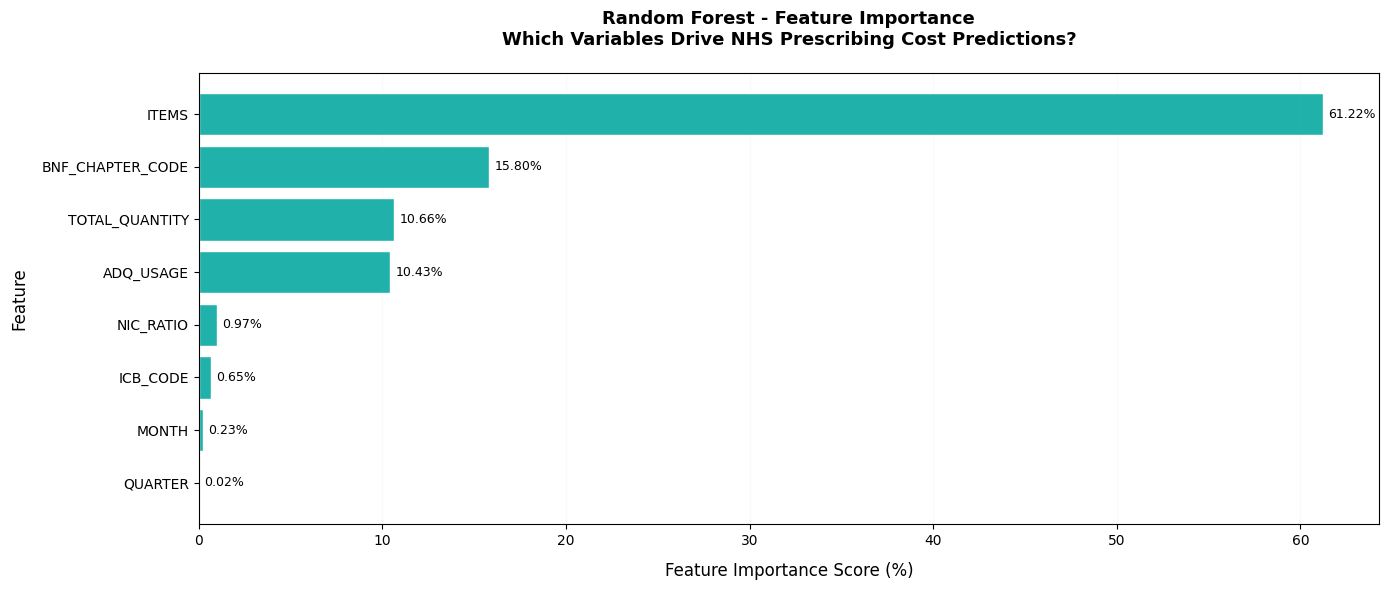

Chart saved


In [152]:
# Dictionary mapping model feature names to original dataset names
feature_name_map = {
    'total_items': 'ITEMS',
    'total_quantity': 'TOTAL_QUANTITY',
    'total_adq': 'ADQ_USAGE',
    'avg_nic_ratio': 'NIC_RATIO',
    'ICB_CODE_ENC': 'ICB_CODE',
    'BNF_CHAPTER_ENC': 'BNF_CHAPTER_CODE',
    'MONTH': 'MONTH',
    'QUARTER': 'QUARTER'
}
# This way each name maps to its original regardless of order

feature_importance = pd.DataFrame({
    'Feature': [feature_name_map[f] for f in features],
    # Maps each feature in the original features list to its display name
    'Importance': rf_model.feature_importances_ * 100
})

feature_importance = feature_importance.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color='#20B2AA',
    edgecolor='white'
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}%",
        va='center', fontsize=9
    )

ax.set_xlabel('Feature Importance Score (%)', fontsize=12, labelpad=10)
ax.set_ylabel('Feature', fontsize=12, labelpad=10)
ax.set_title('Random Forest - Feature Importance\nWhich Variables Drive NHS Prescribing Cost Predictions?',
             fontsize=13, fontweight='bold', pad=20)
ax.grid(True, axis='x', alpha=0.05)

plt.tight_layout()
plt.savefig('chapter4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [153]:
# Step 12: Flag at-risk practices in the test set
# At-risk = practices where actual cost is significantly higher than predicted

test_data_results = test_data.copy()
test_data_results['predicted_cost'] = y_pred_rf
test_data_results['error'] = test_data_results['total_actual_cost'] - test_data_results['predicted_cost']
# Positive error = actual higher than predicted = potential overspending

# Calculate error threshold — flag practices where actual exceeds predicted by more than 20%
test_data_results['pct_error'] = (test_data_results['error'] / test_data_results['predicted_cost']) * 100
# Percentage difference between actual and predicted

# Flag at-risk rows
test_data_results['at_risk'] = test_data_results['pct_error'] > 20
# Practices spending more than 20% above what model predicted

print(f"Total test rows: {len(test_data_results)}")
print(f"At-risk rows: {test_data_results['at_risk'].sum()}")
print(f"At-risk percentage: {(test_data_results['at_risk'].sum() / len(test_data_results) * 100):.2f}%")

Total test rows: 224205
At-risk rows: 36910
At-risk percentage: 16.46%


In [154]:
# Aggregate to practice level — find persistently at-risk practices
at_risk_practices = test_data_results.groupby('PRACTICE_CODE').agg(
    total_actual_cost=('total_actual_cost', 'sum'),
    total_predicted_cost=('predicted_cost', 'sum'),
    at_risk_months=('at_risk', 'sum'),
    total_rows=('at_risk', 'count')
).reset_index()

# Calculate overall percentage overspend at practice level
at_risk_practices['pct_overspend'] = (
    (at_risk_practices['total_actual_cost'] - at_risk_practices['total_predicted_cost']) 
    / at_risk_practices['total_predicted_cost'] * 100
).round(2)

# Filter to practices that are consistently at risk
at_risk_practices = at_risk_practices[at_risk_practices['pct_overspend'] > 0]
at_risk_practices = at_risk_practices.sort_values('pct_overspend', ascending=False)

# Merge with practice names and ICB
at_risk_practices = at_risk_practices.merge(
    final_gp_outliers_clean[['PRACTICE_CODE', 'PRACTICE_NAME', 'ICB_NAME', 'REGIONAL_OFFICE']],
    on='PRACTICE_CODE',
    how='left'
)

print(f"Practices with actual > predicted: {len(at_risk_practices)}")
print("\n--- Top 10 At-Risk Practices ---")
print(at_risk_practices.head(10)[['PRACTICE_NAME', 'ICB_NAME', 'total_actual_cost', 'total_predicted_cost', 'pct_overspend']])

Practices with actual > predicted: 2409

--- Top 10 At-Risk Practices ---
                    PRACTICE_NAME  \
0              GROVEHURST SURGERY   
1       THE ECCLESBOURNE PRACTICE   
2          OAKLANDS HEALTH CENTRE   
3             BADGERSWOOD SURGERY   
4      ALDERSBROOK MEDICAL CENTRE   
5                 GHAURI PRACTICE   
6  LEEDS STUDENT MEDICAL PRACTICE   
7   FARNHAM DENE MEDICAL PRACTICE   
8               FAIRFIELD SURGERY   
9            KEATS GROUP PRACTICE   

                                            ICB_NAME  total_actual_cost  \
0          NHS KENT AND MEDWAY INTEGRATED CARE BOARD          412591.92   
1        NHS NORTH EAST LONDON INTEGRATED CARE BOARD          372244.91   
2           NHS WEST YORKSHIRE INTEGRATED CARE BOARD          529689.73   
3  NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CAR...          677141.56   
4        NHS NORTH EAST LONDON INTEGRATED CARE BOARD          180589.34   
5      NHS MID AND SOUTH ESSEX INTEGRATED CARE BOARD          287733

In [155]:
# Check WELLBN HEALTHCARE
wellbn_check = con.execute("""
    SELECT DISTINCT PRACTICE_CODE, PRACTICE_NAME, ICB_NAME
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE PRACTICE_NAME LIKE '%WELLBN%'
""").df()

print(wellbn_check)

  PRACTICE_CODE      PRACTICE_NAME                          ICB_NAME
0        G81638  WELLBN HEALTHCARE  NHS SUSSEX INTEGRATED CARE BOARD


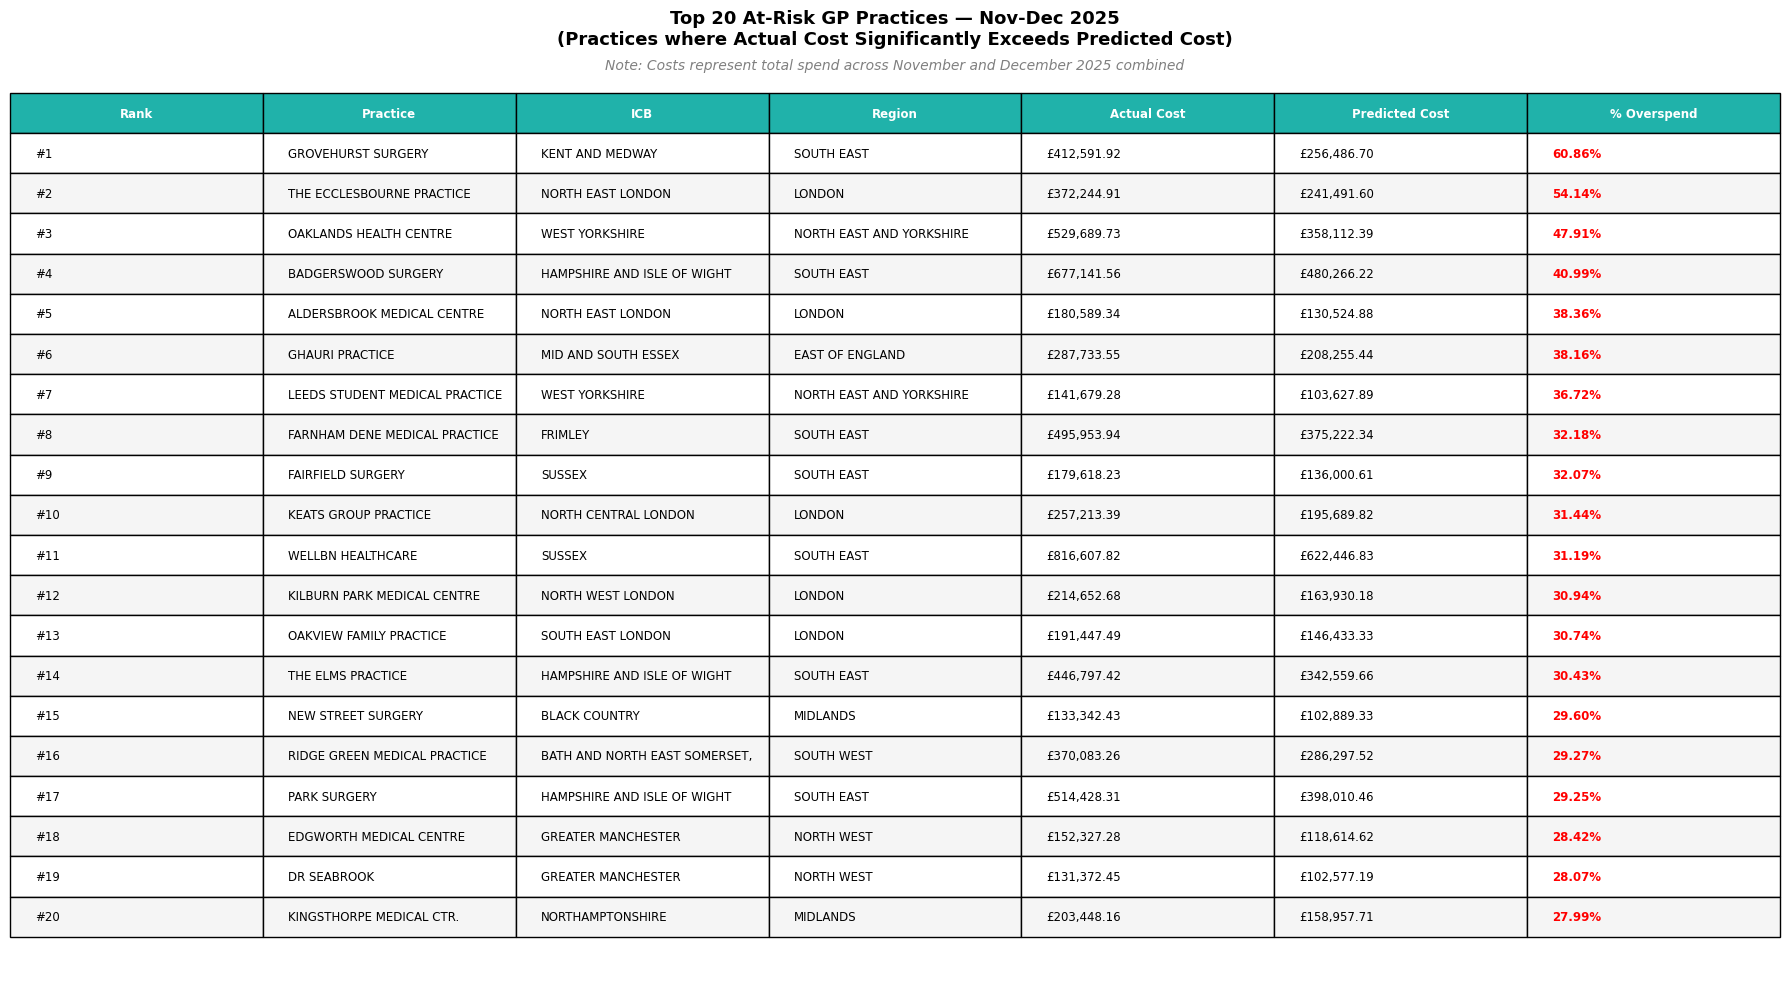

Table saved


In [156]:
# Step 13: Create dashboard output — top 20 at-risk practices
top20_at_risk = at_risk_practices.head(20).copy()

# Clean ICB names
top20_at_risk['ICB_NAME'] = top20_at_risk['ICB_NAME'].str.replace('INTEGRATED CARE BOARD', '').str.replace('NHS ', '').str.strip()

# Round costs
top20_at_risk['total_actual_cost'] = top20_at_risk['total_actual_cost'].round(2)
top20_at_risk['total_predicted_cost'] = top20_at_risk['total_predicted_cost'].round(2)
fig, ax = plt.subplots(figsize=(18, 10))
ax.axis('off')

table_data = []
for rank, (_, row) in enumerate(top20_at_risk.iterrows(), 1):
    table_data.append([
        f"#{rank}",
        row['PRACTICE_NAME'],
        row['ICB_NAME'][:30],
        # Truncate ICB name to 30 characters
        row['REGIONAL_OFFICE'],
        f"£{row['total_actual_cost']:,.2f}",
        f"£{row['total_predicted_cost']:,.2f}",
        f"{row['pct_overspend']:.2f}%"
    ])

columns = ['Rank', 'Practice', 'ICB', 'Region', 'Actual Cost', 'Predicted Cost', '% Overspend']

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='left',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 2)

# Style header
for col in range(len(columns)):
    table[0, col].set_facecolor('#20B2AA')
    table[0, col].set_text_props(color='white', fontweight='bold')

# Alternate row colors
for row in range(1, len(table_data) + 1):
    for col in range(len(columns)):
        if row % 2 == 0:
            table[row, col].set_facecolor('#f5f5f5')
        else:
            table[row, col].set_facecolor('white')

# Color % overspend column red
for row in range(1, len(table_data) + 1):
    table[row, 6].set_text_props(color='red', fontweight='bold')

ax.set_title('Top 20 At-Risk GP Practices — Nov-Dec 2025\n(Practices where Actual Cost Significantly Exceeds Predicted Cost)',
             fontsize=13, fontweight='bold', pad=5)
# Reduced pad from 20 to 5 to reduce spacing
ax.text(0.5, 0.98, 'Note: Costs represent total spend across November and December 2025 combined',
        transform=ax.transAxes, fontsize=10, ha='center', color='grey', style='italic')

plt.tight_layout()
plt.savefig('chapter4_at_risk_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Table saved")

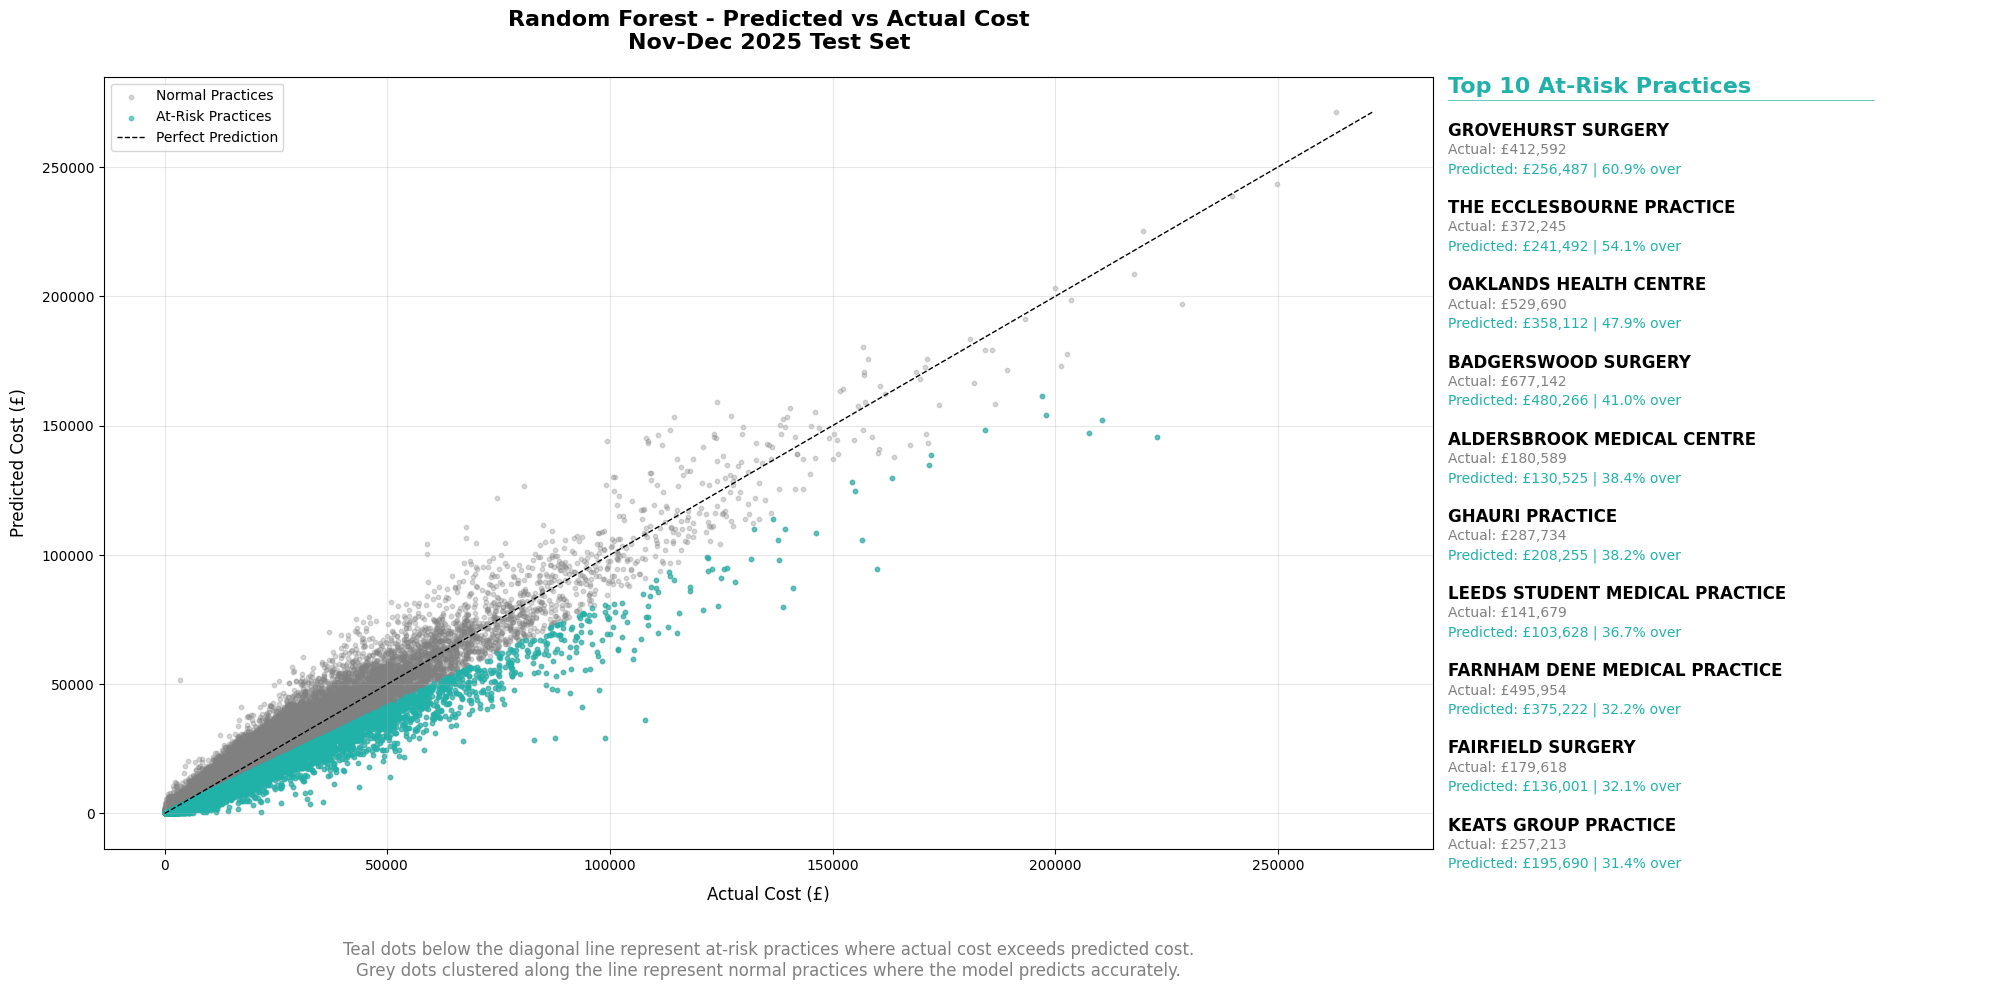

Chart saved


In [157]:
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 0.8])

ax_scatter = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

# Plot normal practices in grey
ax_scatter.scatter(
    y_test,
    y_pred_rf,
    color='grey', alpha=0.3, s=10, label='Normal Practices'
)

# Plot at-risk practices in teal
at_risk_mask = test_data_results['at_risk'] == True
ax_scatter.scatter(
    test_data_results[at_risk_mask]['total_actual_cost'],
    test_data_results[at_risk_mask]['predicted_cost'],
    color='#20B2AA', alpha=0.6, s=10, label='At-Risk Practices'
)

# Perfect prediction line
max_val = max(y_test.max(), y_pred_rf.max())
ax_scatter.plot([0, max_val], [0, max_val],
        color='black', linewidth=1, linestyle='--', label='Perfect Prediction')

ax_scatter.set_xlabel('Actual Cost (£)', fontsize=12, labelpad=10)
ax_scatter.set_ylabel('Predicted Cost (£)', fontsize=12, labelpad=10)
ax_scatter.set_title('Random Forest - Predicted vs Actual Cost\nNov-Dec 2025 Test Set',
             fontsize=16, fontweight='bold', pad=20)
ax_scatter.legend(fontsize=10, loc='upper left')
ax_scatter.grid(True, alpha=0.3)

# Explanation below chart
ax_scatter.text(0.5, -0.12,
    'Teal dots below the diagonal line represent at-risk practices where actual cost exceeds predicted cost.\n'
    'Grey dots clustered along the line represent normal practices where the model predicts accurately.',
    transform=ax_scatter.transAxes,
    fontsize=12, color='grey', ha='center', va='top')

# Right panel — top 10 at-risk practices
ax_legend.axis('off')
ax_legend.text(0.0, 1.0, 'Top 10 At-Risk Practices', fontsize=16, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='#20B2AA')
ax_legend.plot([0, 0.8], [0.97, 0.97], color='#20B2AA', linewidth=0.5, transform=ax_legend.transAxes)

top10_at_risk = at_risk_practices.head(10)
for idx, (_, row) in enumerate(top10_at_risk.iterrows()):
    y_pos = 0.92 - idx * 0.10
    short_name = row['PRACTICE_NAME'][:35]
    ax_legend.text(0.0, y_pos + 0.01, short_name, fontsize=12,
                   fontweight='bold', transform=ax_legend.transAxes, va='center')
    ax_legend.text(0.0, y_pos - 0.015, f"Actual: £{row['total_actual_cost']:,.0f}",
                   fontsize=10, transform=ax_legend.transAxes, va='center', color='grey')
    ax_legend.text(0.0, y_pos - 0.04, f"Predicted: £{row['total_predicted_cost']:,.0f} | {row['pct_overspend']:.1f}% over",
                   fontsize=10, transform=ax_legend.transAxes, va='center', color='#20B2AA')

plt.tight_layout()
plt.savefig('chapter4_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [158]:
# Save at-risk practices
at_risk_practices.to_parquet(
    "D:/UEA/Business Analytics/P1/Dashboard/data/ch4_at_risk.parquet", 
    index=False
)

# Save feature importance
feature_importance_df = pd.DataFrame({
    'feature': ['ITEMS', 'BNF_CHAPTER_CODE', 'TOTAL_QUANTITY', 
                'ADQ_USAGE', 'NIC_RATIO', 'ICB_CODE', 'MONTH', 'QUARTER'],
    'importance': [61.25, 15.83, 10.73, 10.32, 0.97, 0.66, 0.23, 0.02]
})
feature_importance_df.to_parquet(
    "D:/UEA/Business Analytics/P1/Dashboard/data/ch4_feature_importance.parquet",
    index=False
)

# Save model comparison
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R2': [0.5512, 0.9541, 0.9412],
    'RMSE': [7840, 2509, 2839],
    'MAE': [4384, 1133, 1344]
})
model_comparison.to_parquet(
    "D:/UEA/Business Analytics/P1/Dashboard/data/ch4_model_comparison.parquet",
    index=False
)

print("Ch4 files saved")

Ch4 files saved


In [159]:
# # Save full test set results for dashboard scatter plot
# test_data_results[['total_actual_cost', 'predicted_cost', 'at_risk']].to_parquet(
#     "D:/UEA/Business Analytics/P1/Dashboard/data/ch4_test_results.parquet",
#     index=False
# )
# print("Test results saved")
# print(f"Total rows: {len(test_data_results)}")
# print(f"At-risk rows: {test_data_results['at_risk'].sum()}")

=========================================================================================================================================================

12. Chapter 5

In [160]:
# Step 1: Get monthly total cost for high-risk drug categories at national level
high_risk_categories = [
    '06: Endocrine System',
    '02: Cardiovascular System',
    '09: Nutrition and Blood',
    '20: Dressings',
    '04: Central Nervous System'
]
# These are the high-risk categories identified in Chapters 2, 3, and 4

monthly_national = con.execute("""
    SELECT 
        MONTH,
        BNF_CHAPTER_CODE,
        ROUND(SUM(ACTUAL_COST) / 1000000, 4) AS total_cost_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE BNF_CHAPTER_CODE IN (
        '06: Endocrine System',
        '02: Cardiovascular System',
        '09: Nutrition and Blood',
        '20: Dressings',
        '04: Central Nervous System'
    )
    GROUP BY MONTH, BNF_CHAPTER_CODE
    ORDER BY BNF_CHAPTER_CODE, MONTH
""").df()

print(f"Total rows: {len(monthly_national)}")
print(monthly_national.head(10))

Total rows: 60
   MONTH           BNF_CHAPTER_CODE  total_cost_millions
0      1  02: Cardiovascular System              94.0308
1      2  02: Cardiovascular System              84.5664
2      3  02: Cardiovascular System              90.6616
3      4  02: Cardiovascular System              89.4111
4      5  02: Cardiovascular System              93.1084
5      6  02: Cardiovascular System              88.8498
6      7  02: Cardiovascular System              92.7488
7      8  02: Cardiovascular System              88.0739
8      9  02: Cardiovascular System              92.5867
9     10  02: Cardiovascular System              92.4410


In [161]:
# Step 5: Create lag features for each category
all_categories_data = []

for category in high_risk_categories:
    # Get data for this category
    cat_data = monthly_national[monthly_national['BNF_CHAPTER_CODE'] == category].copy()
    cat_data = cat_data.sort_values('MONTH').reset_index(drop=True)
    
    # Create lag features
    cat_data['lag_1'] = cat_data['total_cost_millions'].shift(1)
    # Last month's cost
    cat_data['lag_2'] = cat_data['total_cost_millions'].shift(2)
    # Two months ago cost
    cat_data['lag_3'] = cat_data['total_cost_millions'].shift(3)
    # Three months ago cost
    cat_data['rolling_3'] = cat_data['total_cost_millions'].shift(1).rolling(3).mean()
    # Rolling 3 month average
    
    all_categories_data.append(cat_data)

# Combine all categories
model_df = pd.concat(all_categories_data, ignore_index=True)
model_df = model_df.dropna()
# Drop rows with NaN from lag features

print(f"Total rows after lag features: {len(model_df)}")
print(model_df.head())

Total rows after lag features: 45
   MONTH      BNF_CHAPTER_CODE  total_cost_millions     lag_1     lag_2  \
3      4  06: Endocrine System             172.1396  170.5961  158.2116   
4      5  06: Endocrine System             183.1868  172.1396  170.5961   
5      6  06: Endocrine System             180.9732  183.1868  172.1396   
6      7  06: Endocrine System             194.9119  180.9732  183.1868   
7      8  06: Endocrine System             175.3439  194.9119  180.9732   

      lag_3   rolling_3  
3  175.2806  168.029433  
4  158.2116  166.982433  
5  170.5961  175.307500  
6  172.1396  178.766533  
7  183.1868  186.357300  


In [162]:
# Step 3 & 4: Train/test split
train_df = model_df[model_df['MONTH'] <= 10]
test_df = model_df[model_df['MONTH'] > 10]
# Jan-Oct = training, Nov-Dec = testing

print(f"Training rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")

# Define features and target
features_forecast = ['MONTH', 'lag_1', 'lag_2', 'lag_3', 'rolling_3']
target_forecast = 'total_cost_millions'

X_train_f = train_df[features_forecast]
y_train_f = train_df[target_forecast]

X_test_f = test_df[features_forecast]
y_test_f = test_df[target_forecast]

print(f"\nTraining features shape: {X_train_f.shape}")
print(f"Test features shape: {X_test_f.shape}")

Training rows: 35
Test rows: 10

Training features shape: (35, 5)
Test features shape: (10, 5)


In [163]:
# Train Random Forest forecasting model
forecast_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    # Shallow trees to avoid overfitting on small dataset
    random_state=42,
    n_jobs=-1
)
forecast_model.fit(X_train_f, y_train_f)

# Predict November and December
y_pred_f = forecast_model.predict(X_test_f)

# Calculate metrics
rmse_f = np.sqrt(mean_squared_error(y_test_f, y_pred_f))
mae_f = mean_absolute_error(y_test_f, y_pred_f)

# Calculate MAPE — Mean Absolute Percentage Error
mape_f = (abs((y_test_f.values - y_pred_f) / y_test_f.values) * 100).mean()

print("--- Forecasting Model Results ---")
print(f"RMSE: £{rmse_f:.4f}M")
print(f"MAE:  £{mae_f:.4f}M")
print(f"MAPE: {mape_f:.2f}%")

--- Forecasting Model Results ---
RMSE: £5.3633M
MAE:  £4.5374M
MAPE: 5.29%


In [164]:
# Results per category
test_df_results = test_df.copy()
test_df_results['predicted'] = y_pred_f
test_df_results['error_millions'] = abs(test_df_results['total_cost_millions'] - test_df_results['predicted'])
test_df_results['pct_error'] = abs((test_df_results['total_cost_millions'] - test_df_results['predicted']) / test_df_results['total_cost_millions'] * 100)

category_results = test_df_results.groupby('BNF_CHAPTER_CODE').agg(
    actual=('total_cost_millions', 'mean'),
    predicted=('predicted', 'mean'),
    error_millions=('error_millions', 'mean'),
    pct_error=('pct_error', 'mean')
).round(2)

print(category_results)

                            actual  predicted  error_millions  pct_error
BNF_CHAPTER_CODE                                                        
02: Cardiovascular System    90.52      92.25            4.38       4.94
04: Central Nervous System  126.92     126.86            6.32       4.99
06: Endocrine System        198.05     201.45            6.96       3.59
09: Nutrition and Blood      72.59      74.55            4.10       5.80
20: Dressings                13.15      14.08            0.93       7.11


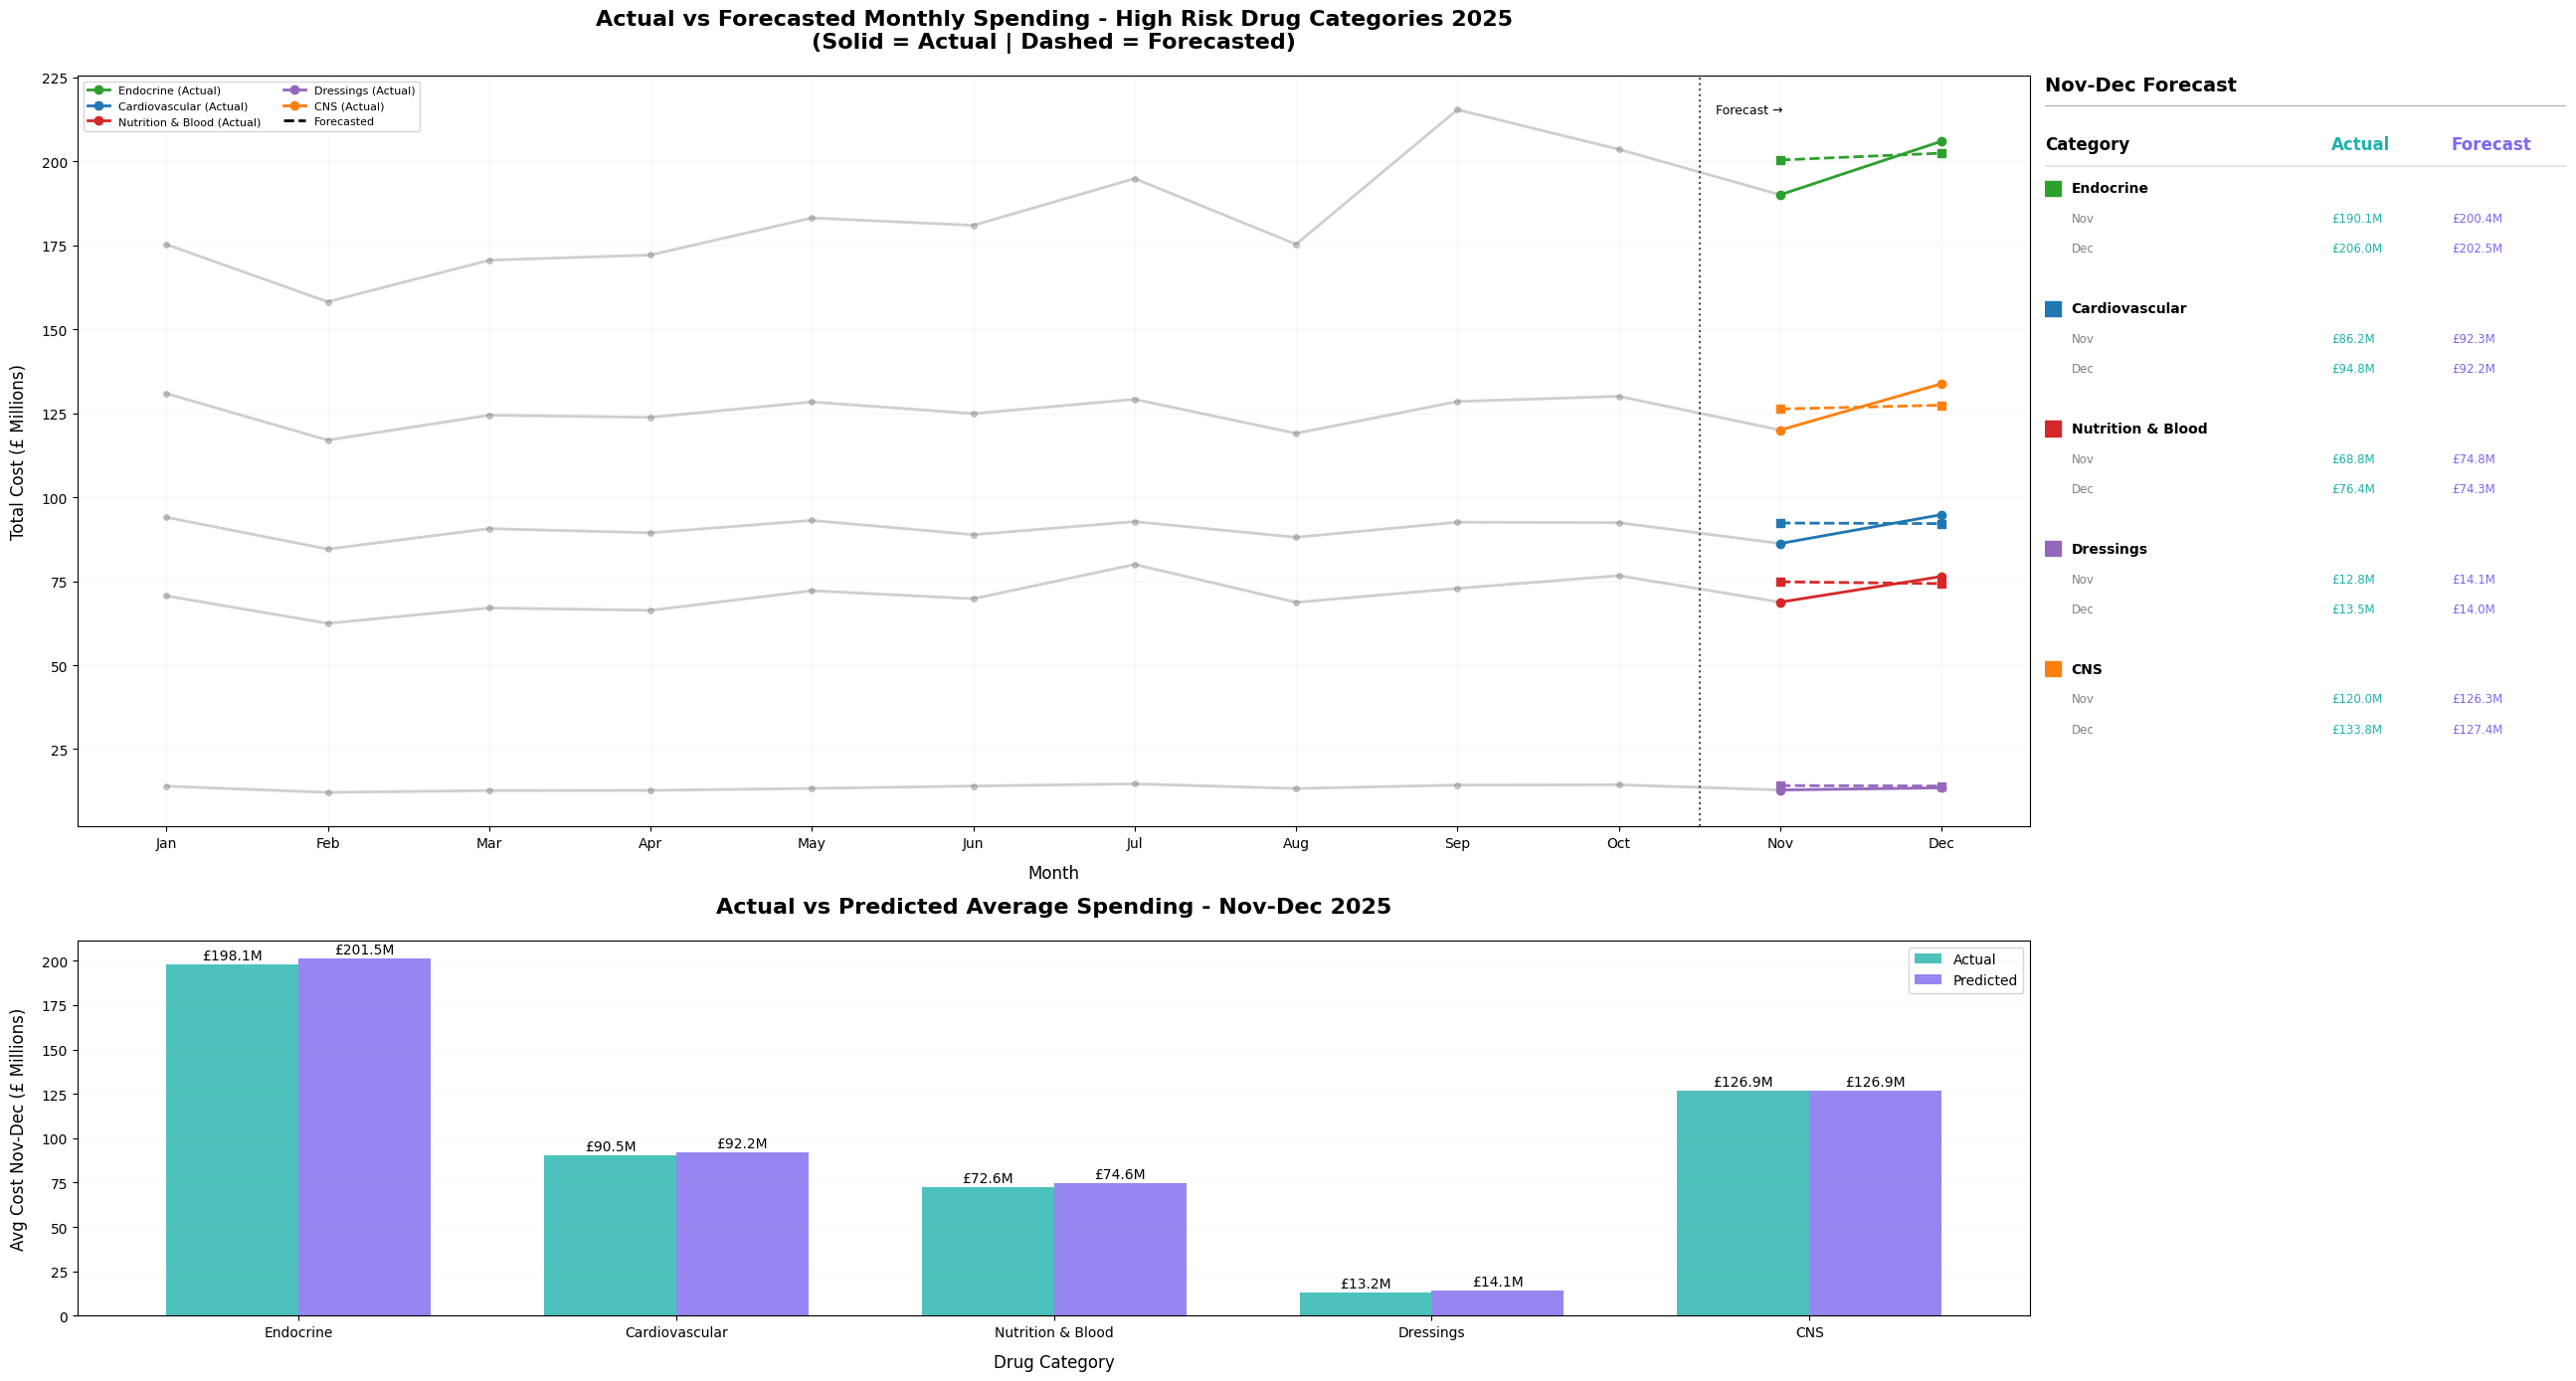

Chart saved


In [165]:
# Prepare full year data for line chart
full_year_data = monthly_national.copy()

# Add predictions for Nov-Dec
test_df_results['MONTH'] = test_df_results['MONTH'].astype(int)

fig = plt.figure(figsize=(26, 14))
gs = gridspec.GridSpec(2, 2, width_ratios=[3, 0.8], height_ratios=[2, 1])

ax_line = fig.add_subplot(gs[0, 0])
ax_legend = fig.add_subplot(gs[0, 1])
ax_bar = fig.add_subplot(gs[1, 0])
ax_bar_legend = fig.add_subplot(gs[1, 1])

# Colors for each category
colors = {
    '02: Cardiovascular System': '#1f77b4',
    '04: Central Nervous System': '#ff7f0e',
    '06: Endocrine System': '#2ca02c',
    '09: Nutrition and Blood': '#d62728',
    '20: Dressings': '#9467bd'
}

short_names = {
    '02: Cardiovascular System': 'Cardiovascular',
    '04: Central Nervous System': 'CNS',
    '06: Endocrine System': 'Endocrine',
    '09: Nutrition and Blood': 'Nutrition & Blood',
    '20: Dressings': 'Dressings'
}

# --- Line Chart ---
for category in high_risk_categories:
    cat_actual = full_year_data[full_year_data['BNF_CHAPTER_CODE'] == category]
    cat_pred = test_df_results[test_df_results['BNF_CHAPTER_CODE'] == category]
    color = colors[category]
    name = short_names[category]

    ax_line.plot(cat_actual['MONTH'], cat_actual['total_cost_millions'],
                color='grey', alpha=0.1, linewidth=2, marker='o', markersize=4)
    ax_line.plot(cat_pred['MONTH'], cat_pred['predicted'],
                color=color, linewidth=2, linestyle='--', marker='s', markersize=6)
    
    ax_line.plot(cat_actual[cat_actual['MONTH'] <= 11]['MONTH'],
            cat_actual[cat_actual['MONTH'] <= 11]['total_cost_millions'],
            color='grey', linewidth=2, marker='o', markersize=4, alpha=0.3, label=None)
    ax_line.plot(cat_actual[cat_actual['MONTH'] >= 11]['MONTH'],
            cat_actual[cat_actual['MONTH'] >= 11]['total_cost_millions'],
            color=color, linewidth=2, marker='o', markersize=6, label=f'{name} (Actual)')

    

# Add forecasted label for legend
ax_line.plot([], [], color='black', linewidth=2, linestyle='--', label='Forecasted')

ax_line.axvline(x=10.5, color='black', linewidth=1.5, linestyle=':', alpha=0.7)
ax_line.text(10.6, ax_line.get_ylim()[1] * 0.95, 'Forecast →', fontsize=9, color='black')

ax_line.set_xlabel('Month', fontsize=12, labelpad=10)
ax_line.set_ylabel('Total Cost (£ Millions)', fontsize=12, labelpad=10)
ax_line.set_title('Actual vs Forecasted Monthly Spending - High Risk Drug Categories 2025\n(Solid = Actual | Dashed = Forecasted)', fontsize=16, fontweight='bold', pad=20)
ax_line.set_xticks(range(1, 13))
ax_line.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax_line.legend(fontsize=8, loc='upper left', ncol=2)
ax_line.grid(True, alpha=0.09)

# --- Right Panel Legend for Line Chart ---
ax_legend.axis('off')
ax_legend.text(0.0, 1.0, 'Nov-Dec Forecast', fontsize=14, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='black')
ax_legend.plot([0, 1], [0.96, 0.96], color='grey', linewidth=0.5, transform=ax_legend.transAxes)

# Column headers
ax_legend.text(0.0, 0.92, 'Category', fontsize=12, fontweight='bold',
               transform=ax_legend.transAxes, va='top')
ax_legend.text(0.55, 0.92, 'Actual', fontsize=12, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='#20B2AA')
ax_legend.text(0.78, 0.92, 'Forecast', fontsize=12, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='#7B68EE')
ax_legend.plot([0, 1], [0.88, 0.88], color='grey', linewidth=0.3, transform=ax_legend.transAxes)

for idx, category in enumerate(high_risk_categories):
    cat_pred = test_df_results[test_df_results['BNF_CHAPTER_CODE'] == category]
    cat_actual = full_year_data[full_year_data['BNF_CHAPTER_CODE'].isin([category]) & 
                                full_year_data['MONTH'].isin([11, 12])]
    
    color = colors[category]
    name = short_names[category]
    
    actual_nov = cat_actual[cat_actual['MONTH'] == 11]['total_cost_millions'].values[0]
    actual_dec = cat_actual[cat_actual['MONTH'] == 12]['total_cost_millions'].values[0]
    pred_nov = cat_pred[cat_pred['MONTH'] == 11]['predicted'].values[0]
    pred_dec = cat_pred[cat_pred['MONTH'] == 12]['predicted'].values[0]
    
    # November row
    y_nov = 0.84 - idx * 0.16
    ax_legend.add_patch(plt.Rectangle((0.0, y_nov), 0.03, 0.02,
                        color=color, transform=ax_legend.transAxes))
    ax_legend.text(0.05, y_nov + 0.01, f'{name}', fontsize=10, fontweight='bold',
                   transform=ax_legend.transAxes, va='center')
    ax_legend.text(0.05, y_nov - 0.03, 'Nov', fontsize=8.5, color='grey',
                   transform=ax_legend.transAxes, va='center')
    ax_legend.text(0.55, y_nov - 0.03, f'£{actual_nov:.1f}M', fontsize=8.5,
                   transform=ax_legend.transAxes, va='center', color='#20B2AA')
    ax_legend.text(0.78, y_nov - 0.03, f'£{pred_nov:.1f}M', fontsize=8.5,
                   transform=ax_legend.transAxes, va='center', color='#7B68EE')
    
    # December row
    ax_legend.text(0.05, y_nov - 0.07, 'Dec', fontsize=8.5, color='grey',
                   transform=ax_legend.transAxes, va='center')
    ax_legend.text(0.55, y_nov - 0.07, f'£{actual_dec:.1f}M', fontsize=8.5,
                   transform=ax_legend.transAxes, va='center', color='#20B2AA')
    ax_legend.text(0.78, y_nov - 0.07, f'£{pred_dec:.1f}M', fontsize=8.5,
                   transform=ax_legend.transAxes, va='center', color='#7B68EE')

# --- Grouped Bar Chart ---
categories_short = [short_names[c] for c in high_risk_categories]
actual_vals = [test_df_results[test_df_results['BNF_CHAPTER_CODE'] == c]['total_cost_millions'].mean() for c in high_risk_categories]
predicted_vals = [test_df_results[test_df_results['BNF_CHAPTER_CODE'] == c]['predicted'].mean() for c in high_risk_categories]

x = np.arange(len(categories_short))
width = 0.35

bars1 = ax_bar.bar(x - width/2, actual_vals, width, label='Actual', color='#20B2AA', alpha=0.8)
bars2 = ax_bar.bar(x + width/2, predicted_vals, width, label='Predicted', color='#7B68EE', alpha=0.8)

for bar in bars1:
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'£{bar.get_height():.1f}M', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'£{bar.get_height():.1f}M', ha='center', va='bottom', fontsize=10)

ax_bar.set_xlabel('Drug Category', fontsize=12, labelpad=10)
ax_bar.set_ylabel('Avg Cost Nov-Dec (£ Millions)', fontsize=12, labelpad=10)
ax_bar.set_title('Actual vs Predicted Average Spending - Nov-Dec 2025', fontsize=16, fontweight='bold', pad=20)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(categories_short)
ax_bar.legend(fontsize=10)
ax_bar.grid(True, axis='y', alpha=0.05)

# Hide bottom right panel
ax_bar_legend.axis('off')

plt.tight_layout()
plt.savefig('chapter5_line_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [166]:
# Get monthly Endocrine spending for Hampshire ICB only
hampshire_endocrine = con.execute("""
    SELECT 
        MONTH,
        ROUND(SUM(ACTUAL_COST) / 1000000, 4) AS total_cost_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE ICB_NAME = 'NHS HAMPSHIRE AND ISLE OF WIGHT INTEGRATED CARE BOARD'
    AND BNF_CHAPTER_CODE = '06: Endocrine System'
    GROUP BY MONTH
    ORDER BY MONTH
""").df()

print(f"Total rows: {len(hampshire_endocrine)}")
print(hampshire_endocrine)

Total rows: 12
    MONTH  total_cost_millions
0       1               6.2271
1       2               5.6979
2       3               6.1525
3       4               6.1120
4       5               6.5224
5       6               6.4238
6       7               6.9401
7       8               6.3705
8       9               7.5083
9      10               7.2631
10     11               6.8124
11     12               7.3656


In [167]:
# Create lag features for Hampshire Endocrine
hamp_data = hampshire_endocrine.copy()
hamp_data['lag_1'] = hamp_data['total_cost_millions'].shift(1)
hamp_data['lag_2'] = hamp_data['total_cost_millions'].shift(2)
hamp_data['lag_3'] = hamp_data['total_cost_millions'].shift(3)
hamp_data['rolling_3'] = hamp_data['total_cost_millions'].shift(1).rolling(3).mean()
hamp_data = hamp_data.dropna()

# Train/test split
hamp_train = hamp_data[hamp_data['MONTH'] <= 10]
hamp_test = hamp_data[hamp_data['MONTH'] > 10]

features_h = ['MONTH', 'lag_1', 'lag_2', 'lag_3', 'rolling_3']
target_h = 'total_cost_millions'

X_train_h = hamp_train[features_h]
y_train_h = hamp_train[target_h]
X_test_h = hamp_test[features_h]
y_test_h = hamp_test[target_h]

# Train model
hamp_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
hamp_model.fit(X_train_h, y_train_h)
y_pred_h = hamp_model.predict(X_test_h)

# Metrics
rmse_h = np.sqrt(mean_squared_error(y_test_h, y_pred_h))
mape_h = (abs((y_test_h.values - y_pred_h) / y_test_h.values) * 100).mean()
error_pounds_h = abs(y_test_h.values - y_pred_h).mean()

print("--- Hampshire + Endocrine Forecast ---")
print(f"RMSE: £{rmse_h:.4f}M")
print(f"MAPE: {mape_h:.2f}%")
print(f"Error in £: £{error_pounds_h:.4f}M")
print(f"\nNov — Actual: £{y_test_h.values[0]:.4f}M | Predicted: £{y_pred_h[0]:.4f}M")
print(f"Dec — Actual: £{y_test_h.values[1]:.4f}M | Predicted: £{y_pred_h[1]:.4f}M")

--- Hampshire + Endocrine Forecast ---
RMSE: £0.3120M
MAPE: 3.93%
Error in £: £0.2722M

Nov — Actual: £6.8124M | Predicted: £7.2372M
Dec — Actual: £7.3656M | Predicted: £7.2460M


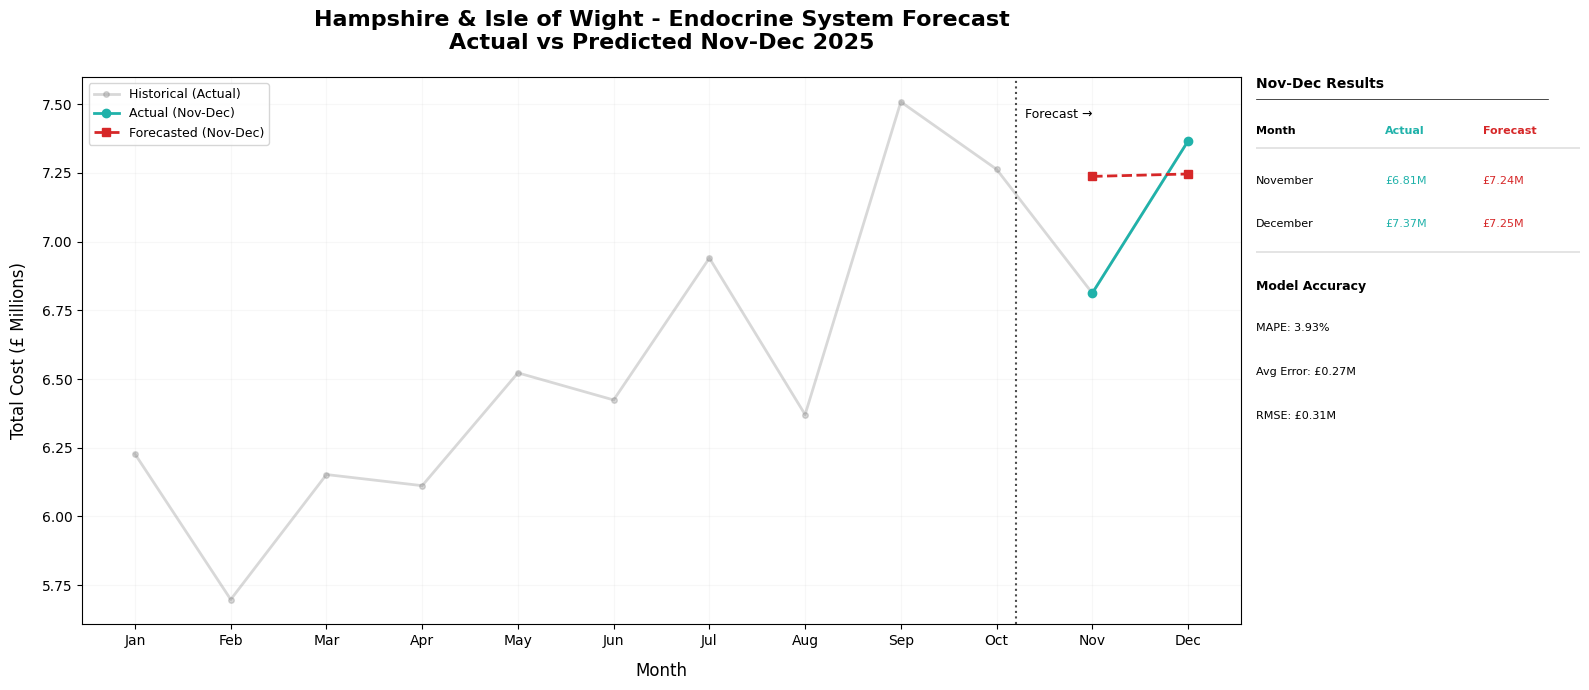

Chart saved


In [168]:
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 0.7])

ax = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

# Full year actual data in grey
ax.plot(hampshire_endocrine['MONTH'], hampshire_endocrine['total_cost_millions'],
        color='grey', alpha=0.3, linewidth=2, marker='o', markersize=4, label='Historical (Actual)')

# Nov-Dec actual in teal — starting from November only
nov_dec_actual = hampshire_endocrine[hampshire_endocrine['MONTH'] >= 11]
ax.plot(nov_dec_actual['MONTH'], nov_dec_actual['total_cost_millions'],
        color='#20B2AA', linewidth=2, marker='o', markersize=6, label='Actual (Nov-Dec)')

# Nov-Dec forecast as dashed red
ax.plot(hamp_test['MONTH'], y_pred_h,
        color='#d62728', linewidth=2, linestyle='--', marker='s', markersize=6, label='Forecasted (Nov-Dec)')

# Vertical line at November
ax.axvline(x=10.2, color='black', linewidth=1.5, linestyle=':', alpha=0.7)

# Forecast arrow at November start
ax.annotate('Forecast →', xy=(10.30, 7.45), fontsize=9, color='black')

ax.set_xlabel('Month', fontsize=12, labelpad=10)
ax.set_ylabel('Total Cost (£ Millions)', fontsize=12, labelpad=10)
ax.set_title('Hampshire & Isle of Wight - Endocrine System Forecast\nActual vs Predicted Nov-Dec 2025',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.09)

# Right panel legend
ax_legend.axis('off')

# Title
ax_legend.text(0.0, 1.0, 'Nov-Dec Results', fontsize=10, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='black')
ax_legend.plot([0, 0.9], [0.96, 0.96], color='black', linewidth=0.5, transform=ax_legend.transAxes)

# Column headers
ax_legend.text(0.0, 0.91, 'Month', fontsize=8, fontweight='bold',
               transform=ax_legend.transAxes, va='top')
ax_legend.text(0.40, 0.91, 'Actual', fontsize=8, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='#20B2AA')
ax_legend.text(0.70, 0.91, 'Forecast', fontsize=8, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='#d62728')
ax_legend.plot([0, 1], [0.87, 0.87], color='grey', linewidth=0.3, transform=ax_legend.transAxes)

# November values
ax_legend.text(0.0, 0.82, 'November', fontsize=8, transform=ax_legend.transAxes, va='top')
ax_legend.text(0.40, 0.82, f'£{y_test_h.values[0]:.2f}M', fontsize=8,
               transform=ax_legend.transAxes, va='top', color='#20B2AA')
ax_legend.text(0.70, 0.82, f'£{y_pred_h[0]:.2f}M', fontsize=8,
               transform=ax_legend.transAxes, va='top', color='#d62728')

# December values
ax_legend.text(0.0, 0.74, 'December', fontsize=8, transform=ax_legend.transAxes, va='top')
ax_legend.text(0.40, 0.74, f'£{y_test_h.values[1]:.2f}M', fontsize=8,
               transform=ax_legend.transAxes, va='top', color='#20B2AA')
ax_legend.text(0.70, 0.74, f'£{y_pred_h[1]:.2f}M', fontsize=8,
               transform=ax_legend.transAxes, va='top', color='#d62728')

ax_legend.plot([0, 1], [0.68, 0.68], color='grey', linewidth=0.3, transform=ax_legend.transAxes)

# Model metrics
ax_legend.text(0.0, 0.63, 'Model Accuracy', fontsize=9, fontweight='bold',
               transform=ax_legend.transAxes, va='top', color='black')
ax_legend.text(0.0, 0.55, f'MAPE: 3.93%', fontsize=8,
               transform=ax_legend.transAxes, va='top', color='black')
ax_legend.text(0.0, 0.47, f'Avg Error: £0.27M', fontsize=8,
               transform=ax_legend.transAxes, va='top', color='black')
ax_legend.text(0.0, 0.39, f'RMSE: £0.31M', fontsize=8,
               transform=ax_legend.transAxes, va='top', color='black')

plt.tight_layout()
plt.savefig('chapter5_hampshire_endocrine.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

=========================================================================================================================================================

13. Chapter 6

In [169]:
# Step 1: Aggregate monthly ACTUAL_COST per BNF category
monthly_all = con.execute("""
    SELECT 
        MONTH,
        BNF_CHAPTER_CODE,
        ROUND(SUM(ACTUAL_COST) / 1000000, 4) AS total_cost_millions,
        ROUND(SUM(ITEMS) / 1000000, 4) AS total_items_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    GROUP BY MONTH, BNF_CHAPTER_CODE
    ORDER BY BNF_CHAPTER_CODE, MONTH
""").df()

print(f"Total rows: {len(monthly_all)}")
print(monthly_all.head(10))

Total rows: 252
   MONTH              BNF_CHAPTER_CODE  total_cost_millions  \
0      1  01: Gastro-Intestinal System              59.2177   
1      2  01: Gastro-Intestinal System              53.3747   
2      3  01: Gastro-Intestinal System              56.7539   
3      4  01: Gastro-Intestinal System              57.0957   
4      5  01: Gastro-Intestinal System              60.3427   
5      6  01: Gastro-Intestinal System              59.2677   
6      7  01: Gastro-Intestinal System              60.1403   
7      8  01: Gastro-Intestinal System              55.2920   
8      9  01: Gastro-Intestinal System              58.8788   
9     10  01: Gastro-Intestinal System              56.7273   

   total_items_millions  
0               10.2317  
1                9.1478  
2                9.7138  
3                9.7571  
4               10.1094  
5                9.8023  
6               10.4638  
7                9.6263  
8               10.1807  
9               10.4394  


In [170]:
# Run decomposition for each category
seasonality_results = []

for category in monthly_all['BNF_CHAPTER_CODE'].unique():
    cat_data = monthly_all[monthly_all['BNF_CHAPTER_CODE'] == category].sort_values('MONTH')
    
    # Decompose time series
    # period=12 would need 2 full years — we only have 1 year so use period=6
    decomp = seasonal_decompose(
        cat_data['total_cost_millions'],
        model='additive',
        period=6,
        extrapolate_trend='freq'
    )
    
    # Seasonality strength = variance of seasonal component / variance of data
    seasonal_strength = decomp.seasonal.var() / cat_data['total_cost_millions'].var()
    
    seasonality_results.append({
        'category': category,
        'seasonal_strength': round(seasonal_strength, 4),
        'max_cost': cat_data['total_cost_millions'].max(),
        'min_cost': cat_data['total_cost_millions'].min(),
        'range': round(cat_data['total_cost_millions'].max() - cat_data['total_cost_millions'].min(), 2)
    })

seasonality_df = pd.DataFrame(seasonality_results)
seasonality_df = seasonality_df.sort_values('seasonal_strength', ascending=False)

print("--- Seasonality Strength by Category ---")
print(seasonality_df.to_string(index=False))

--- Seasonality Strength by Category ---
                                               category  seasonal_strength  max_cost  min_cost  range
                     18: Preparations used in Diagnosis             0.7996    0.0016    0.0003   0.00
                                        15: Anaesthesia             0.7240    2.0845    1.8101   0.27
                                          20: Dressings             0.7227   14.6488   12.1067   2.54
07: Obstetrics, Gynaecology and Urinary-Tract Disorders             0.6439   23.8098   20.5129   3.30
                            22: Incontinence Appliances             0.6425    5.7338    4.9146   0.82
                           12: Ear, Nose and Oropharynx             0.6253    8.1647    6.5001   1.66
                             04: Central Nervous System             0.5991  133.8113  117.0107  16.80
            08: Malignant Disease and Immunosuppression             0.5624   14.5679   12.5341   2.03
                                         

In [171]:
# Check what's in Category 18
cat18 = con.execute("""
    SELECT 
        DRUG_NAME,
        SUM(ITEMS) AS total_items,
        ROUND(SUM(ACTUAL_COST), 2) AS total_cost
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE BNF_CHAPTER_CODE = '18: Preparations used in Diagnosis'
    GROUP BY DRUG_NAME
    ORDER BY total_cost DESC
""").df()

print(f"Total drugs in Category 18: {len(cat18)}")
print(cat18)

Total drugs in Category 18: 1
                                 DRUG_NAME  total_items  total_cost
0  Other x-ray contrast media preparations         49.0    10441.13


In [172]:
# Remove Category 18 and re-run
monthly_all = monthly_all[monthly_all['BNF_CHAPTER_CODE'] != '18: Preparations used in Diagnosis']

seasonality_results = []

for category in monthly_all['BNF_CHAPTER_CODE'].unique():
    cat_data = monthly_all[monthly_all['BNF_CHAPTER_CODE'] == category].sort_values('MONTH')
    
    decomp = seasonal_decompose(
        cat_data['total_cost_millions'],
        model='additive',
        period=6,
        extrapolate_trend='freq'
    )
    
    seasonal_strength = decomp.seasonal.var() / cat_data['total_cost_millions'].var()
    
    seasonality_results.append({
        'category': category,
        'seasonal_strength': round(seasonal_strength, 4),
        'max_cost': cat_data['total_cost_millions'].max(),
        'min_cost': cat_data['total_cost_millions'].min(),
        'range': round(cat_data['total_cost_millions'].max() - cat_data['total_cost_millions'].min(), 2)
    })

seasonality_df = pd.DataFrame(seasonality_results)
seasonality_df = seasonality_df.sort_values('seasonal_strength', ascending=False)

print("--- Seasonality Strength by Category (Category 18 Excluded) ---")
print(seasonality_df.to_string(index=False))

--- Seasonality Strength by Category (Category 18 Excluded) ---
                                               category  seasonal_strength  max_cost  min_cost  range
                                        15: Anaesthesia             0.7240    2.0845    1.8101   0.27
                                          20: Dressings             0.7227   14.6488   12.1067   2.54
07: Obstetrics, Gynaecology and Urinary-Tract Disorders             0.6439   23.8098   20.5129   3.30
                            22: Incontinence Appliances             0.6425    5.7338    4.9146   0.82
                           12: Ear, Nose and Oropharynx             0.6253    8.1647    6.5001   1.66
                             04: Central Nervous System             0.5991  133.8113  117.0107  16.80
            08: Malignant Disease and Immunosuppression             0.5624   14.5679   12.5341   2.03
                                               13: Skin             0.5162   27.0685   23.0858   3.98
                  

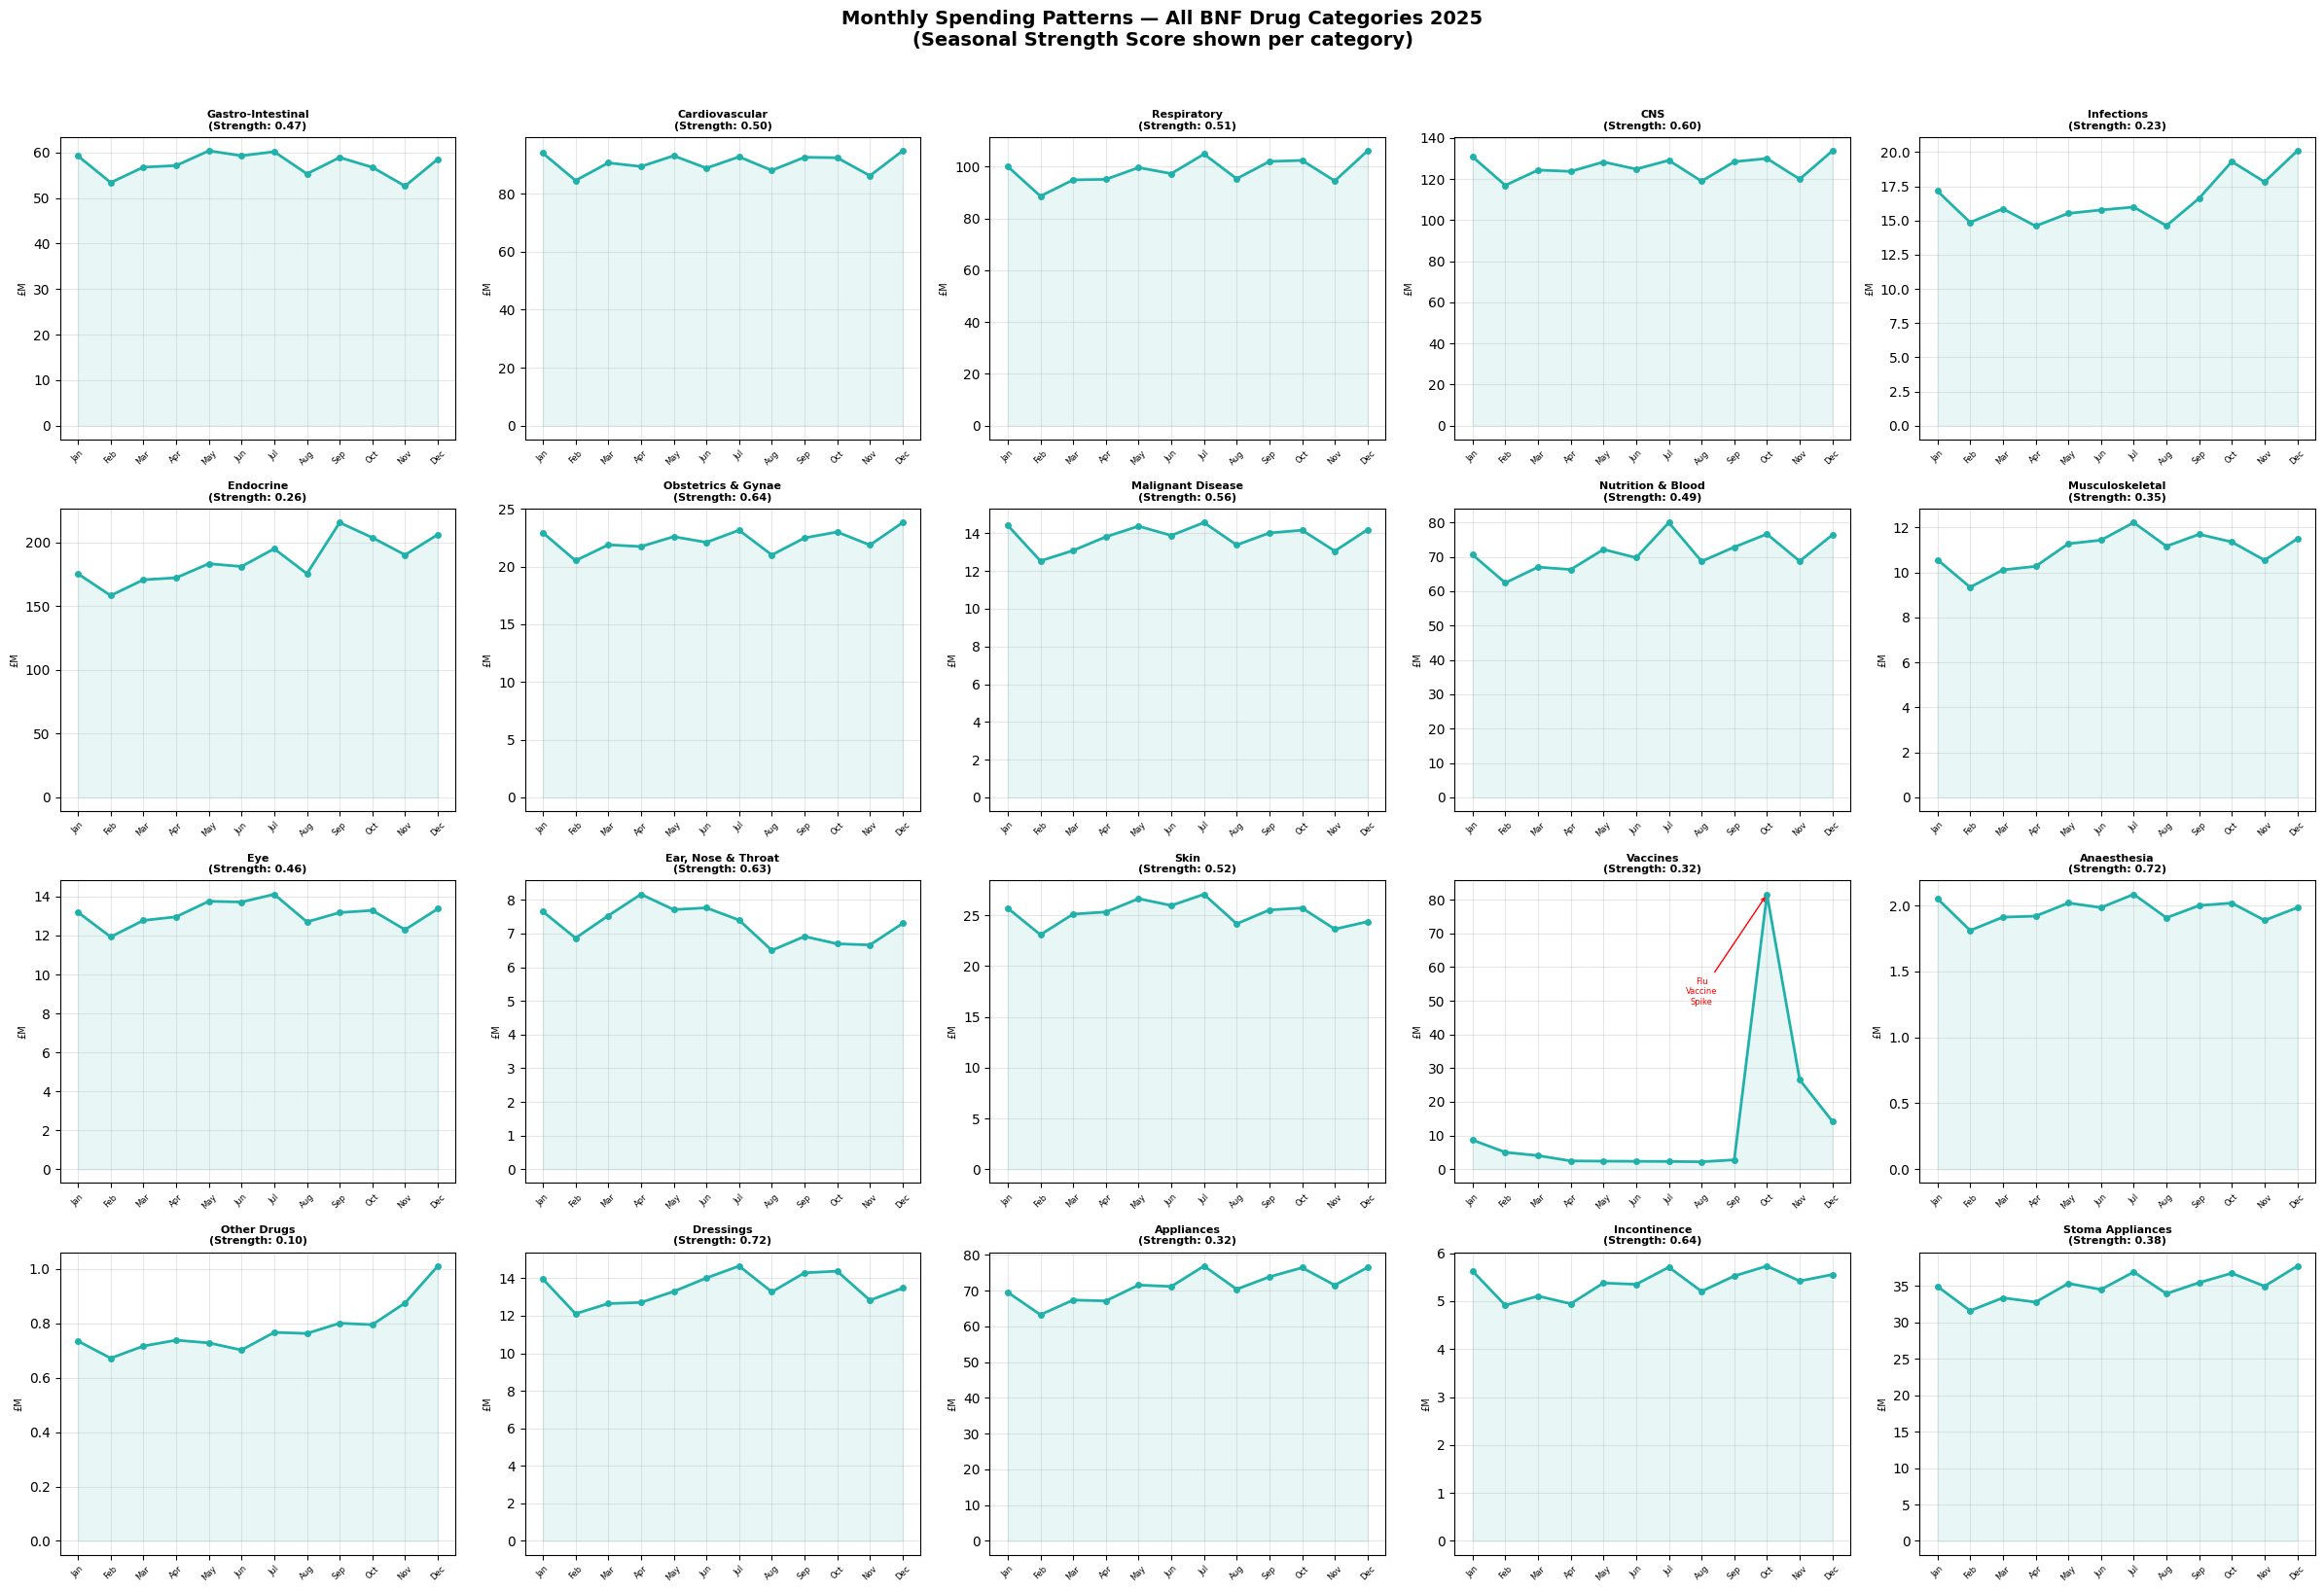

Chart saved


In [173]:
# Short names for all 20 categories
short_names_all = {
    '01: Gastro-Intestinal System': 'Gastro-Intestinal',
    '02: Cardiovascular System': 'Cardiovascular',
    '03: Respiratory System': 'Respiratory',
    '04: Central Nervous System': 'CNS',
    '05: Infections': 'Infections',
    '06: Endocrine System': 'Endocrine',
    '07: Obstetrics, Gynaecology and Urinary-Tract Disorders': 'Obstetrics & Gynae',
    '08: Malignant Disease and Immunosuppression': 'Malignant Disease',
    '09: Nutrition and Blood': 'Nutrition & Blood',
    '10: Musculoskeletal and Joint Diseases': 'Musculoskeletal',
    '11: Eye': 'Eye',
    '12: Ear, Nose and Oropharynx': 'Ear, Nose & Throat',
    '13: Skin': 'Skin',
    '14: Immunological Products and Vaccines': 'Vaccines',
    '15: Anaesthesia': 'Anaesthesia',
    '19: Other Drugs and Preparations': 'Other Drugs',
    '20: Dressings': 'Dressings',
    '21: Appliances': 'Appliances',
    '22: Incontinence Appliances': 'Incontinence',
    '23: Stoma Appliances': 'Stoma Appliances'
}

# Plot all 20 categories in a grid
fig, axes = plt.subplots(4, 5, figsize=(24, 16))
axes = axes.flatten()

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for idx, category in enumerate(monthly_all['BNF_CHAPTER_CODE'].unique()):
    cat_data = monthly_all[monthly_all['BNF_CHAPTER_CODE'] == category].sort_values('MONTH')
    strength = seasonality_df[seasonality_df['category'] == category]['seasonal_strength'].values[0]
    
    ax = axes[idx]
    ax.plot(cat_data['MONTH'], cat_data['total_cost_millions'],
            color='#20B2AA', linewidth=2, marker='o', markersize=4)
    ax.fill_between(cat_data['MONTH'], cat_data['total_cost_millions'],
                    alpha=0.1, color='#20B2AA')
    
    ax.set_title(f"{short_names_all.get(category, category)}\n(Strength: {strength:.2f})",
                 fontsize=8, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=6, rotation=45)
    ax.set_ylabel('£M', fontsize=7)
    ax.grid(True, alpha=0.3)

    # Highlight Category 14 spike
    if category == '14: Immunological Products and Vaccines':
        ax.annotate('Flu\nVaccine\nSpike', xy=(10, cat_data[cat_data['MONTH']==10]['total_cost_millions'].values[0]),
                    fontsize=6, color='red', ha='center',
                    xytext=(8, cat_data['total_cost_millions'].max() * 0.6),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1))

fig.suptitle('Monthly Spending Patterns — All BNF Drug Categories 2025\n(Seasonal Strength Score shown per category)',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chapter6_all_categories_line.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [174]:
# Step 6: Get monthly spending by region for key seasonal categories
regional_seasonal = con.execute("""
    SELECT 
        MONTH,
        REGIONAL_OFFICE,
        BNF_CHAPTER_CODE,
        ROUND(SUM(ACTUAL_COST) / 1000000, 4) AS total_cost_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    WHERE BNF_CHAPTER_CODE IN (
        '20: Dressings',
        '04: Central Nervous System',
        '03: Respiratory System',
        '14: Immunological Products and Vaccines'
    )
    GROUP BY MONTH, REGIONAL_OFFICE, BNF_CHAPTER_CODE
    ORDER BY BNF_CHAPTER_CODE, REGIONAL_OFFICE, MONTH
""").df()

print(f"Total rows: {len(regional_seasonal)}")
print(regional_seasonal['REGIONAL_OFFICE'].unique())

Total rows: 336
<ArrowStringArray>
[         'EAST OF ENGLAND',                   'LONDON',
                 'MIDLANDS', 'NORTH EAST AND YORKSHIRE',
               'NORTH WEST',               'SOUTH EAST',
               'SOUTH WEST']
Length: 7, dtype: str


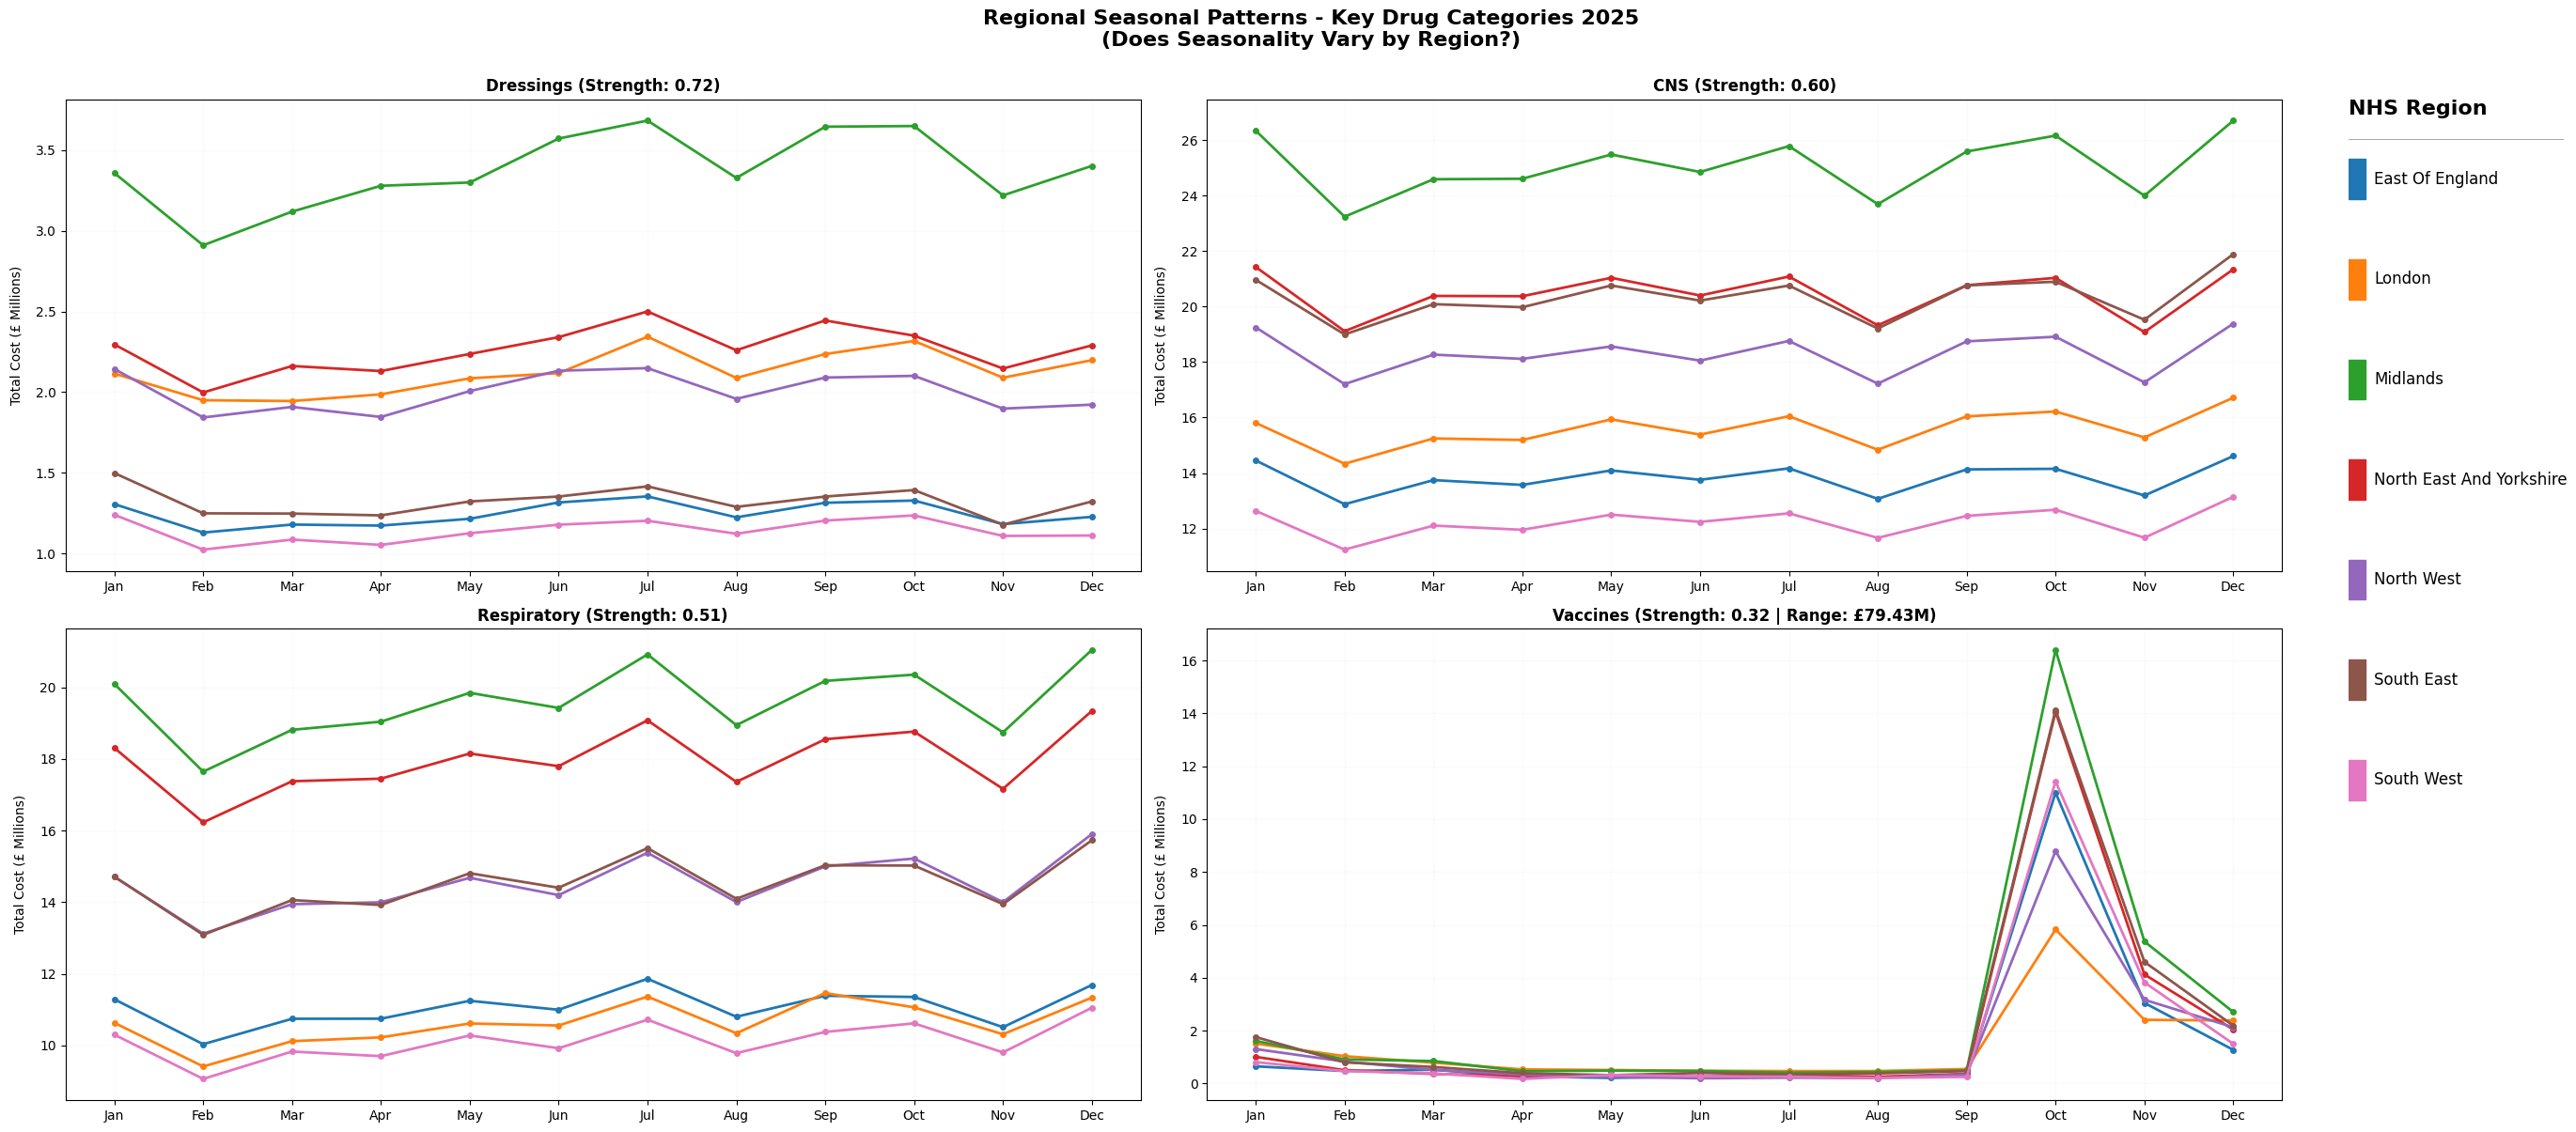

Chart saved


In [175]:
# Step 7: Compare regional seasonal patterns for key categories
fig = plt.figure(figsize=(28, 12))
gs = gridspec.GridSpec(2, 3, width_ratios=[5, 5, 1])
# Two columns for charts, one narrow column for legend

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax_legend = fig.add_subplot(gs[:, 2])
# Legend panel spans both rows

axes = [ax1, ax2, ax3, ax4]

key_categories = [
    '20: Dressings',
    '04: Central Nervous System',
    '03: Respiratory System',
    '14: Immunological Products and Vaccines'
]

category_titles = {
    '20: Dressings': 'Dressings (Strength: 0.72)',
    '04: Central Nervous System': 'CNS (Strength: 0.60)',
    '03: Respiratory System': 'Respiratory (Strength: 0.51)',
    '14: Immunological Products and Vaccines': 'Vaccines (Strength: 0.32 | Range: £79.43M)'
}

# Color per region
region_colors = {
    'EAST OF ENGLAND': '#1f77b4',
    'LONDON': '#ff7f0e',
    'MIDLANDS': '#2ca02c',
    'NORTH EAST AND YORKSHIRE': '#d62728',
    'NORTH WEST': '#9467bd',
    'SOUTH EAST': '#8c564b',
    'SOUTH WEST': '#e377c2'
}

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Remove individual legends and add single right panel
for idx, category in enumerate(key_categories):
    ax = axes[idx]
    cat_data = regional_seasonal[regional_seasonal['BNF_CHAPTER_CODE'] == category]
    
    for region in cat_data['REGIONAL_OFFICE'].unique():
        region_data = cat_data[cat_data['REGIONAL_OFFICE'] == region].sort_values('MONTH')
        ax.plot(region_data['MONTH'], region_data['total_cost_millions'],
                color=region_colors[region], linewidth=2, marker='o',
                markersize=4)
    
    ax.set_title(category_titles[category], fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=10)
    ax.set_ylabel('Total Cost (£ Millions)', fontsize=10, labelpad=10)
    ax.grid(True, alpha=0.05)

# Right panel legend
ax_legend.axis('off')
ax_legend.text(0.0, 1.0, 'NHS Region', fontsize=16, fontweight='bold',
               transform=ax_legend.transAxes, va='top')
ax_legend.plot([0, 1], [0.96, 0.96], color='grey', linewidth=0.5,
               transform=ax_legend.transAxes)

for idx, (region, color) in enumerate(region_colors.items()):
    y_pos = 0.90 - idx * 0.10
    ax_legend.add_patch(plt.Rectangle((0.0, y_pos), 0.08, 0.04,
                        color=color, transform=ax_legend.transAxes))
    ax_legend.text(0.12, y_pos + 0.02, region.title(), fontsize=12,
                   transform=ax_legend.transAxes, va='center')

fig.suptitle('Regional Seasonal Patterns - Key Drug Categories 2025\n(Does Seasonality Vary by Region?)',
             fontsize=16, fontweight='bold', y=1.0)

plt.tight_layout()
plt.savefig('chapter6_regional_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [176]:
# Create heatmap data — monthly spending by region (all categories combined)
heatmap_data = con.execute("""
    SELECT 
        MONTH,
        REGIONAL_OFFICE,
        ROUND(SUM(ACTUAL_COST) / 1000000, 2) AS total_cost_millions
    FROM read_parquet('D:/UEA/Business Analytics/P1/Code_Dataset/Merged/merged_dataset_final.parquet')
    GROUP BY MONTH, REGIONAL_OFFICE
    ORDER BY REGIONAL_OFFICE, MONTH
""").df()

# Pivot to matrix format — rows = regions, columns = months
heatmap_pivot = heatmap_data.pivot(
    index='REGIONAL_OFFICE',
    columns='MONTH',
    values='total_cost_millions'
)

# Rename columns to month names
heatmap_pivot.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(heatmap_pivot)

                             Jan     Feb     Mar     Apr     May     Jun  \
REGIONAL_OFFICE                                                            
EAST OF ENGLAND           100.13   89.37   95.67   94.70   99.95   97.83   
LONDON                    108.17   97.24  103.99  103.88  109.70  107.76   
MIDLANDS                  179.12  158.21  168.56  169.25  178.12  174.49   
NORTH EAST AND YORKSHIRE  144.96  129.44  138.36  139.02  146.00  143.36   
NORTH WEST                124.67  112.05  118.70  118.98  124.93  122.20   
SOUTH EAST                134.00  120.06  128.30  126.56  134.64  131.87   
SOUTH WEST                 86.18   76.35   82.32   81.01   86.07   84.26   

                             Jul     Aug     Sep     Oct     Nov     Dec  
REGIONAL_OFFICE                                                           
EAST OF ENGLAND           103.84   94.90  103.54  113.74   98.52  105.61  
LONDON                    115.04  104.07  114.88  118.80  108.51  116.59  
MIDLANDS       

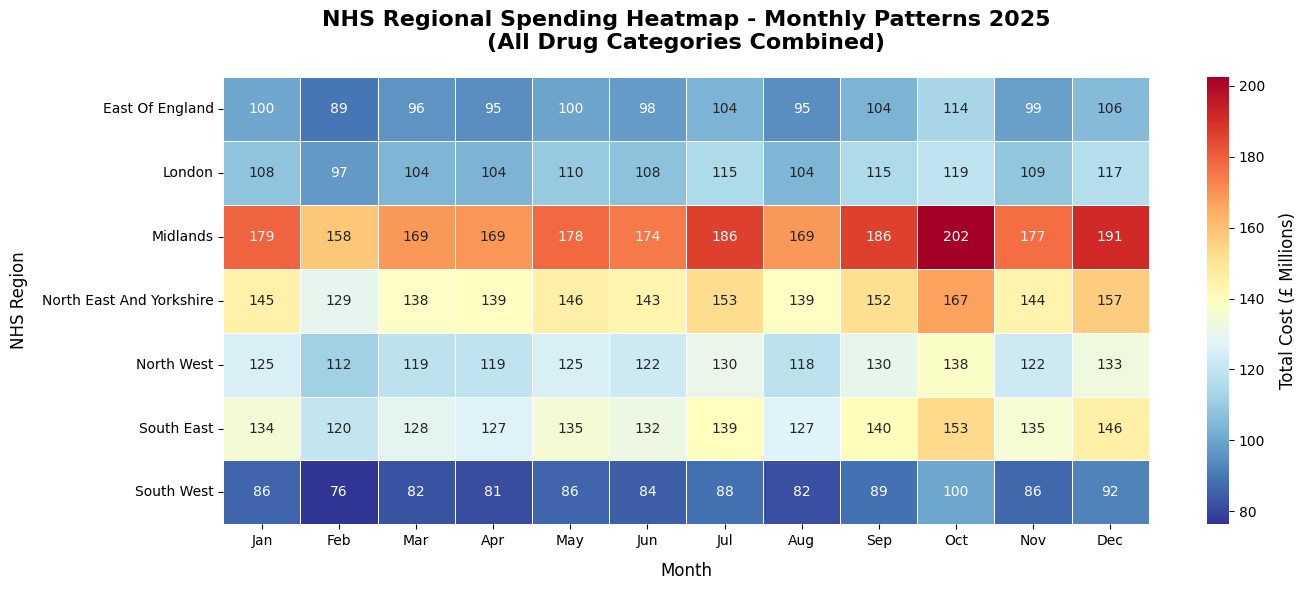

Chart saved


In [177]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    heatmap_pivot,
    ax=ax,
    cmap='RdYlBu_r',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Total Cost (£ Millions)'}
)

ax.collections[0].colorbar.ax.set_ylabel('Total Cost (£ Millions)', fontsize=12, labelpad=10)

ax.set_title('NHS Regional Spending Heatmap - Monthly Patterns 2025\n(All Drug Categories Combined)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12, labelpad=10)
ax.set_ylabel('NHS Region', fontsize=12, labelpad=10)

# Fix y axis labels
ax.set_yticklabels([r.title() for r in heatmap_pivot.index], rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('chapter6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")